In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cyrinemejrii/raw-document/2010 - mashboot.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2002 - sce api.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2008 - vub.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2004 - jse.doc
/kaggle/input/datasets/cyrinemejrii/raw-document/0000 - inventory - scanned.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2004 - watcom gui.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2007 - puget sound.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/0000 - cctns-scanned.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/1999 - multi-mahjong.html
/kaggle/input/datasets/cyrinemejrii/raw-document/2005 - nenios.html
/kaggle/input/datasets/cyrinemejrii/raw-document/2010 - gparted.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2005 - triangle.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2009 - library.pdf
/kaggle/input/datasets/cyrinemejrii/raw-document/2011 - opensg 0.1.doc
/kaggle/input/datas

In [2]:


import numpy as np
import pandas as pd
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch

In [3]:
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# 1) PROMISE
df_promise = pd.read_csv("/kaggle/input/datasets/cyrinemejrii/requirements-datasets/PROMISE.csv")

# 2) dataset_normalized
df_normalized = pd.read_csv("/kaggle/input/datasets/cyrinemejrii/requirements-datasets/dataset_normalized.csv")

# 3) FNFC
df_fnfc = pd.read_csv("/kaggle/input/datasets/cyrinemejrii/requirements-datasets/FNFC.csv", encoding="latin1")

# 4) FR_NFR_Dataset
df_frnfr = pd.read_csv("/kaggle/input/datasets/cyrinemejrii/requirements-datasets/FR_NFR_Dataset.csv", sep=";", encoding="latin1")

# 5) Pure_Annotate_Dataset
df_pure = pd.read_csv("/kaggle/input/datasets/cyrinemejrii/requirements-datasets/Pure_Annotate_Dataset.csv", encoding="latin1")

# 6) extracted req from SRS
df_srs = pd.read_csv("/kaggle/input/datasets/cyrinemejrii/requirements-datasets/extracted req from SRS.csv", sep=";", encoding="latin1")

In [5]:
print(df_promise.shape)
print(df_normalized.shape)
print(df_fnfc.shape)
print(df_frnfr.shape)
print(df_pure.shape)
print(df_srs.shape)

(969, 3)
(969, 2)
(7060, 2)
(6139, 16)
(11440, 5)
(66, 5)


In [6]:
datasets = {
    "PROMISE": df_promise,
    "NORMALIZED": df_normalized,
    "FNFC": df_fnfc,
    "FR_NFR": df_frnfr,
    "PURE": df_pure,
    "SRS": df_srs
}

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Missing values:\n", df.isnull().sum())
    display(df.head(5))

PROMISE
Shape: (969, 3)
Columns: ['ProjectID', 'RequirementText', '_class_']
Missing values:
 ProjectID          0
RequirementText    0
_class_            0
dtype: int64


,ProjectID,RequirementText,_class_
0,1,The system shall refresh the display every 60 ...,PE
1,1,The application shall match the color of the s...,LF
2,1,If projected the data must be readable. On a...,US
3,1,The product shall be available during normal b...,A
4,1,If projected the data must be understandable....,US


NORMALIZED
Shape: (969, 2)
Columns: ['RequirementText', '_class_']
Missing values:
 RequirementText    0
_class_            0
dtype: int64


,RequirementText,_class_
0,system shall refresh display every second,PE
1,application shall match color schema set forth...,LF
2,project data must readable projection screen v...,US
3,product shall available normal business hour l...,A
4,project data must understandable projection sc...,US


FNFC
Shape: (7060, 2)
Columns: ['text', 'class']
Missing values:
 text     0
class    0
dtype: int64


...

,Requirement Text,Type,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,The app shall run on a smart phone with Androi...,NFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,All layout shall be according to the TU/e corp...,NFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,The icons shall be according to the Android Ic...,NFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,The user interfaces shall be according to the ...,NFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"The Twitter ""tweet"" interface shall be accordi...",NFR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


PURE
Shape: (11440, 5)
Columns: ['id', 'sentence', 'security', 'reliability', 'NFR_boolean']
Missing values:
 id             0
sentence       0
security       0
reliability    0
NFR_boolean    0
dtype: int64


,id,sentence,security,reliability,NFR_boolean
0,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall create a single patient recor...,0,0,0
1,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall associate (store and link) ke...,0,0,0
2,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide the ability to store ...,0,0,0
3,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide a field which will id...,0,0,0
4,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide the ability to merge ...,0,0,0


SRS
Shape: (66, 5)
Columns: ['doc_id', "Texte de l'exigence", 'Label', 'Sub-label', 'Note Qualité']
Missing values:
 doc_id                 0
Texte de l'exigence    0
Label                  0
Sub-label              0
Note Qualité           0
dtype: int64


,doc_id,Texte de l'exigence,Label,Sub-label,Note Qualité
0,SRS001,Users must sign up with an email and password,FR,authentication,Atomic & Clear
1,SRS001,Users can reset their password via email,FR,authentication,Clear
2,SRS001,Users can modify their preferences at any time...,FR,user_settings,Clear
3,SRS001,The feed is strictly based on user preferences...,FR,content_feed,Ambiguous (vague)
4,SRS001,"The system should handle up to 100,000 concurr...",NFR,scalability,Measurable


In [7]:
final_columns = ["text", "label", "sub_label", "quality_note", "source"]

In [8]:
#Mapping
promise_map = {
    "F": ("FR", "functional"),
    "PE": ("NFR", "performance"),
    "SE": ("NFR", "security"),
    "US": ("NFR", "usability"),
    "LF": ("NFR", "look_and_feel"),
    "A": ("NFR", "availability"),
    "FT": ("NFR", "fault_tolerance"),
    "PO": ("NFR", "portability"),
    "SC": ("NFR", "scalability"),
    "MN": ("NFR", "maintainability"),
    "O": ("OTHER", "other")
}

In [9]:
#Standardisation

# PROMISE
df_promise_std = pd.DataFrame()
df_promise_std["text"] = df_promise["RequirementText"].astype(str)
df_promise_std["label"] = df_promise["_class_"].map(lambda x: promise_map.get(x, ("OTHER", "other"))[0])
df_promise_std["sub_label"] = df_promise["_class_"].map(lambda x: promise_map.get(x, ("OTHER", "other"))[1])
df_promise_std["quality_note"] = "unknown"
df_promise_std["source"] = "PROMISE"

# NORMALIZED
df_normalized_std = pd.DataFrame()
df_normalized_std["text"] = df_normalized["RequirementText"].astype(str)
df_normalized_std["label"] = df_normalized["_class_"].map(lambda x: promise_map.get(x, ("OTHER", "other"))[0])
df_normalized_std["sub_label"] = df_normalized["_class_"].map(lambda x: promise_map.get(x, ("OTHER", "other"))[1])
df_normalized_std["quality_note"] = "unknown"
df_normalized_std["source"] = "NORMALIZED"

# FNFC
df_fnfc_std = pd.DataFrame()
df_fnfc_std["text"] = df_fnfc["text"].astype(str)
df_fnfc_std["label"] = df_fnfc["class"].map(lambda x: promise_map.get(x, ("OTHER", "other"))[0])
df_fnfc_std["sub_label"] = df_fnfc["class"].map(lambda x: promise_map.get(x, ("OTHER", "other"))[1])
df_fnfc_std["quality_note"] = "unknown"
df_fnfc_std["source"] = "FNFC"

# FR_NFR
df_frnfr_clean = df_frnfr[["Requirement Text", "Type"]].copy()

df_frnfr_std = pd.DataFrame()
df_frnfr_std["text"] = df_frnfr_clean["Requirement Text"].astype(str)
df_frnfr_std["label"] = df_frnfr_clean["Type"].astype(str).str.strip().str.upper()
df_frnfr_std["sub_label"] = "general"
df_frnfr_std["quality_note"] = "unknown"
df_frnfr_std["source"] = "FR_NFR"

# PURE
df_pure_std = pd.DataFrame()
df_pure_std["text"] = df_pure["sentence"].astype(str)
df_pure_std["label"] = df_pure["NFR_boolean"].map(lambda x: "NFR" if x == 1 else "FR")

def get_pure_sub_label(row):
    if row["security"] == 1:
        return "security"
    elif row["reliability"] == 1:
        return "reliability"
    elif row["NFR_boolean"] == 1:
        return "nfr_general"
    else:
        return "functional"

df_pure_std["sub_label"] = df_pure.apply(get_pure_sub_label, axis=1)
df_pure_std["quality_note"] = "unknown"
df_pure_std["source"] = "PURE"

# SRS
df_srs_std = pd.DataFrame()
df_srs_std["text"] = df_srs["Texte de l'exigence"].astype(str)
df_srs_std["label"] = df_srs["Label"].astype(str).str.strip().str.upper()
df_srs_std["sub_label"] = df_srs["Sub-label"].astype(str)
df_srs_std["quality_note"] = df_srs["Note Qualité"].astype(str)
df_srs_std["source"] = "SRS"

In [10]:

std_datasets = {
    "PROMISE_STD": df_promise_std,
    "NORMALIZED_STD": df_normalized_std,
    "FNFC_STD": df_fnfc_std,
    "FR_NFR_STD": df_frnfr_std,
    "PURE_STD": df_pure_std,
    "SRS_STD": df_srs_std
}

for name, df in std_datasets.items():
    print("=" * 80)
    print(name)
    print("Shape:", df.shape)
    print(df.head(5))

PROMISE_STD
Shape: (969, 5)
                                                text label      sub_label  \
0  The system shall refresh the display every 60 ...   NFR    performance   
1  The application shall match the color of the s...   NFR  look_and_feel   
2  If projected  the data must be readable.  On a...   NFR      usability   
3  The product shall be available during normal b...   NFR   availability   
4  If projected  the data must be understandable....   NFR      usability   

  quality_note   source  
0      unknown  PROMISE  
1      unknown  PROMISE  
2      unknown  PROMISE  
3      unknown  PROMISE  
4      unknown  PROMISE  
NORMALIZED_STD
Shape: (969, 5)
                                                text label      sub_label  \
0          system shall refresh display every second   NFR    performance   
1  application shall match color schema set forth...   NFR  look_and_feel   
2  project data must readable projection screen v...   NFR      usability   
3  product sha

In [11]:
# Nettoyage fort du texte

def clean_text(text):
    text = str(text)

    # lower optionnel pour analyse; ici on garde la casse originale pour lecture
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")

    # supprimer espaces multiples
    text = re.sub(r"\s+", " ", text)

    # supprimer caractères invisibles
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)

    # trim final
    text = text.strip()

    return text

all_dfs = [
    df_promise_std,
    df_normalized_std,
    df_fnfc_std,
    df_frnfr_std,
    df_pure_std,
    df_srs_std
]

for df in all_dfs:
    df["text"] = df["text"].apply(clean_text)
    df["label"] = df["label"].astype(str).str.strip().str.upper()
    df["sub_label"] = df["sub_label"].astype(str).str.strip().str.lower()
    df["quality_note"] = df["quality_note"].astype(str).str.strip()
    df["source"] = df["source"].astype(str).str.strip()

In [12]:
# Colonne de déduplication robuste
def normalize_for_dedup(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in all_dfs:
    df["text_dedup"] = df["text"].apply(normalize_for_dedup)

In [13]:
#Fusion

df_requirements = pd.concat(all_dfs, ignore_index=True)
print("Merged shape:", df_requirements.shape)
display(df_requirements.head())

Merged shape: (26643, 6)


,text,label,sub_label,quality_note,source,text_dedup
0,The system shall refresh the display every 60 ...,NFR,performance,unknown,PROMISE,the system shall refresh the display every 60 ...
1,The application shall match the color of the s...,NFR,look_and_feel,unknown,PROMISE,the application shall match the color of the s...
2,If projected the data must be readable. On a 1...,NFR,usability,unknown,PROMISE,if projected the data must be readable on a 10...
3,The product shall be available during normal b...,NFR,availability,unknown,PROMISE,the product shall be available during normal b...
4,If projected the data must be understandable. ...,NFR,usability,unknown,PROMISE,if projected the data must be understandable o...


In [14]:
#NORMALISATION DES LABELS

def normalize_label(label):
    label = str(label).upper().strip()

    if label == "FR":
        return "FR"
    elif label in ["NFR", "TECH", "BUSINESS", "CONSTRAINT", "RISK"]:
        return "NFR"
    else:
        return "OTHER"

df_requirements["label"] = df_requirements["label"].apply(normalize_label)

In [15]:
# Data cleaning global fort

initial_rows = len(df_requirements)

# supprimer textes nuls
df_requirements = df_requirements.dropna(subset=["text", "label"])

# enlever valeurs textuelles vides / faux nan
bad_text_values = ["", "nan", "none", "null"]
df_requirements = df_requirements[~df_requirements["text"].str.lower().isin(bad_text_values)]

# enlever textes très courts
df_requirements = df_requirements[df_requirements["text"].str.len() > 10]

# garder labels utiles
valid_labels = ["FR", "NFR", "OTHER"]
df_requirements = df_requirements[df_requirements["label"].isin(valid_labels)]

# supprimer doublons robustes
before_dedup = len(df_requirements)
df_requirements = df_requirements.drop_duplicates(subset=["text_dedup"])
after_dedup = len(df_requirements)

print("Initial rows:", initial_rows)
print("After cleaning:", len(df_requirements))
print("Duplicates removed:", before_dedup - after_dedup)


Initial rows: 26643
After cleaning: 24443
Duplicates removed: 1954


In [16]:

# Contrôles qualité
print("Final shape:", df_requirements.shape)

print("\nLabels distribution:")
print(df_requirements["label"].value_counts())

print("\nSources distribution:")
print(df_requirements["source"].value_counts())

print("\nTop sub-labels:")
print(df_requirements["sub_label"].value_counts().head(20))

print("\nMissing values:")
print(df_requirements.isnull().sum())


Final shape: (24443, 6)

Labels distribution:
label
FR       18724
NFR       5115
OTHER      604
Name: count, dtype: int64

Sources distribution:
source
PURE          10019
FNFC           6697
FR_NFR         5729
PROMISE         966
NORMALIZED      966
SRS              66
Name: count, dtype: int64

Top sub-labels:
sub_label
functional         14918
general             5729
security            2179
other                604
usability            248
performance          234
availability         169
look_and_feel        121
scalability           55
maintainability       48
fault_tolerance       45
reliability           28
portability           24
compatibility          4
compliance             3
integration            3
logging                2
transaction            2
proctoring             2
admin                  2
Name: count, dtype: int64

Missing values:
text            0
label           0
sub_label       0
quality_note    0
source          0
text_dedup      0
dtype: int64


In [17]:

# Features d’analyse utiles
df_requirements["text_length_chars"] = df_requirements["text"].apply(len)
df_requirements["text_length_words"] = df_requirements["text"].apply(lambda x: len(str(x).split()))


In [18]:
#FEATURE ENGINEERING
df_requirements["has_shall"] = df_requirements["text"].str.contains("shall", case=False).astype(int)
df_requirements["has_must"] = df_requirements["text"].str.contains("must", case=False).astype(int)
df_requirements["has_should"] = df_requirements["text"].str.contains("should", case=False).astype(int)

quality_note
unknown              24377
Clear                   29
Measurable              17
Constraint               8
Ambiguous                4
Legal                    3
Atomic & Clear           2
Ambiguous (vague)        1
Testable                 1
Future Scope             1
Name: count, dtype: int64


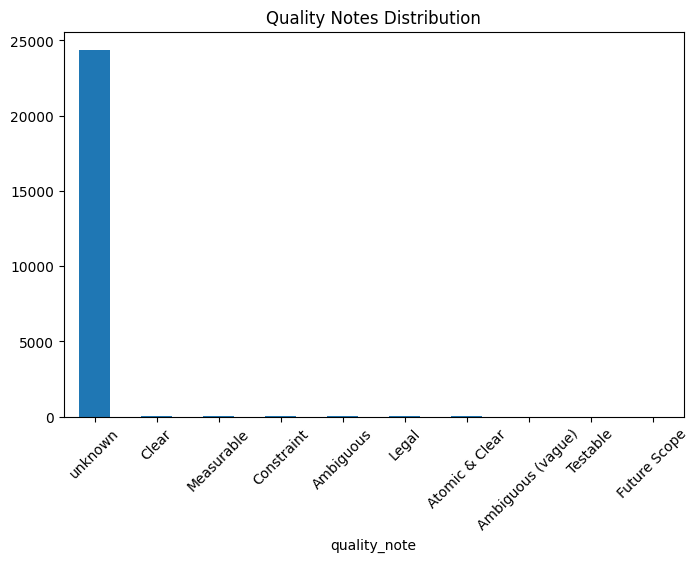

In [19]:
#ANALYSE QUALITÉ
print(df_requirements["quality_note"].value_counts())

plt.figure(figsize=(8,5))
df_requirements["quality_note"].value_counts().plot(kind="bar")
plt.title("Quality Notes Distribution")
plt.xticks(rotation=45)
plt.show()

In [20]:
print("\nPercentage:")
print(df_requirements["quality_note"].value_counts(normalize=True))


Percentage:
quality_note
unknown              0.997300
Clear                0.001186
Measurable           0.000695
Constraint           0.000327
Ambiguous            0.000164
Legal                0.000123
Atomic & Clear       0.000082
Ambiguous (vague)    0.000041
Testable             0.000041
Future Scope         0.000041
Name: proportion, dtype: float64


**ÉQUILIBRAGE**

In [21]:
print("\nFR vs NFR ratio:")
print(df_requirements["label"].value_counts(normalize=True))


FR vs NFR ratio:
label
FR       0.766027
NFR      0.209262
OTHER    0.024711
Name: proportion, dtype: float64


In [22]:
min_count = df_requirements["label"].value_counts().min()

df_balanced = df_requirements.groupby("label").sample(min_count, random_state=42)

print(df_balanced["label"].value_counts())

label
FR       604
NFR      604
OTHER    604
Name: count, dtype: int64


In [23]:
df_balanced["label"].value_counts()

label
FR       604
NFR      604
OTHER    604
Name: count, dtype: int64

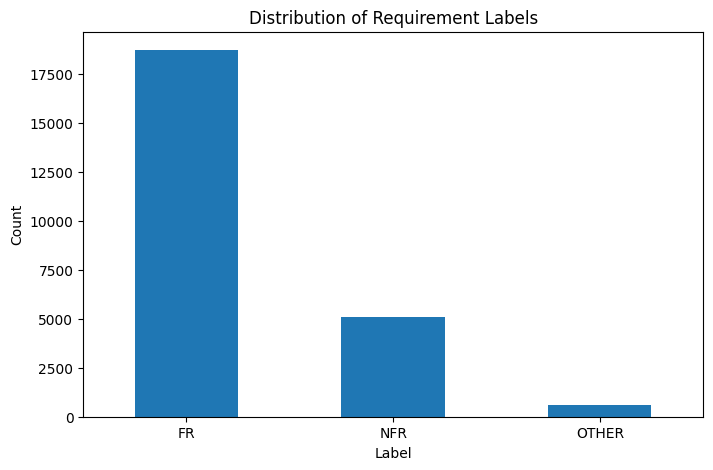

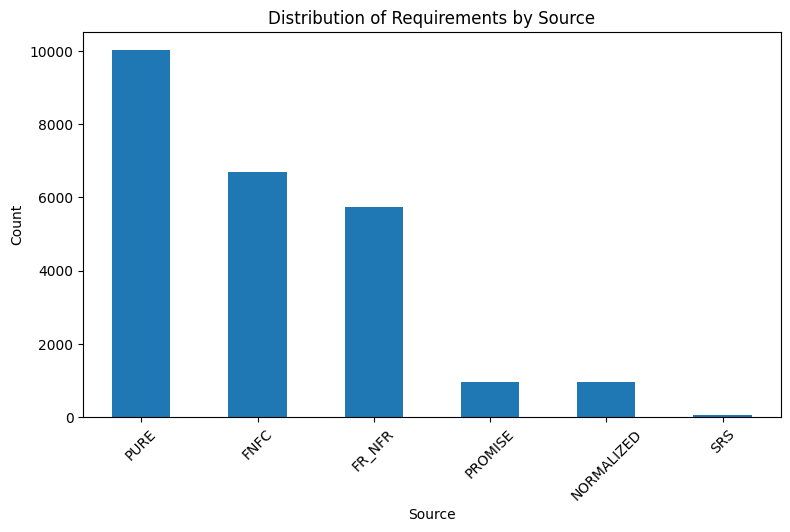

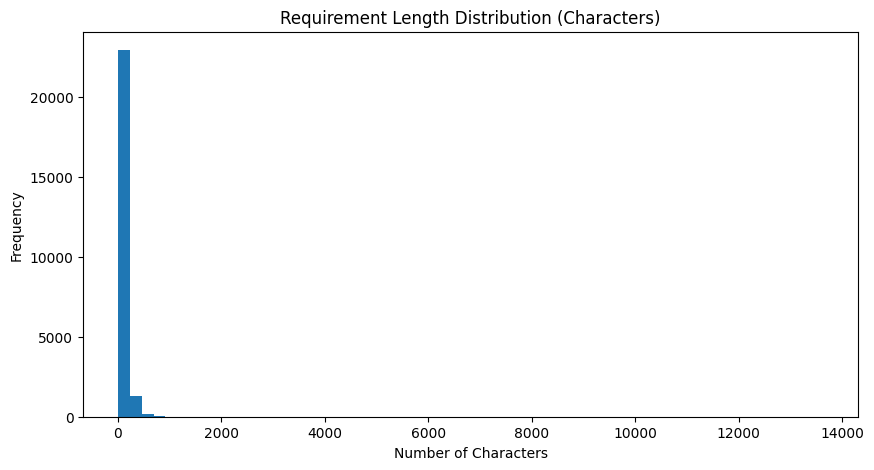

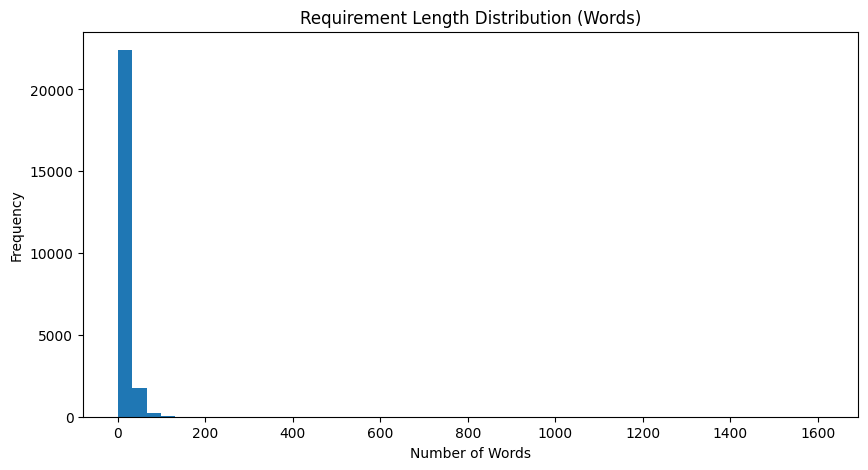

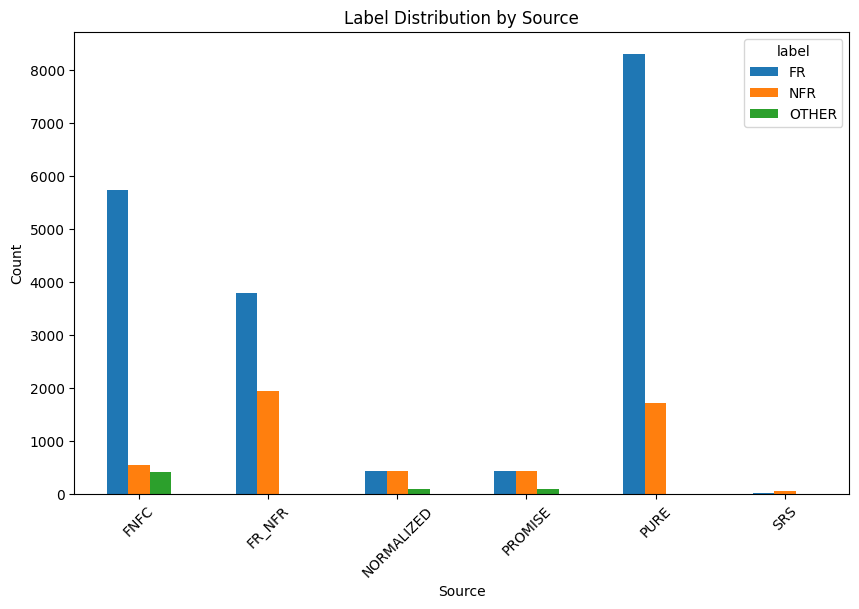

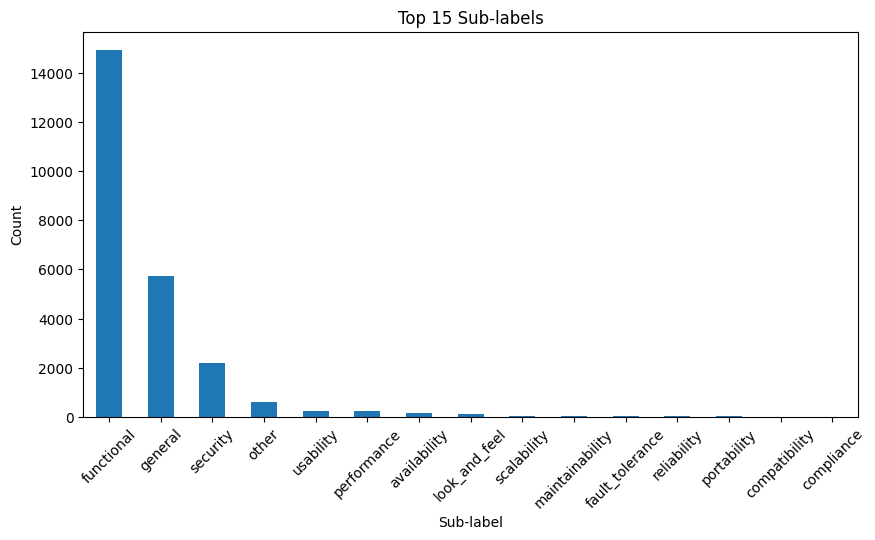

In [24]:
#Visualisations wow
#A. Distribution des labels
plt.figure(figsize=(8,5))
df_requirements["label"].value_counts().plot(kind="bar")
plt.title("Distribution of Requirement Labels")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

#B. Distribution des sources
plt.figure(figsize=(9,5))
df_requirements["source"].value_counts().plot(kind="bar")
plt.title("Distribution of Requirements by Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#C. Longueur des textes en caractères
plt.figure(figsize=(10,5))
plt.hist(df_requirements["text_length_chars"], bins=60)
plt.title("Requirement Length Distribution (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

#D. Longueur des textes en mots
plt.figure(figsize=(10,5))
plt.hist(df_requirements["text_length_words"], bins=50)
plt.title("Requirement Length Distribution (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

#E. Labels par source
cross_tab = pd.crosstab(df_requirements["source"], df_requirements["label"])

cross_tab.plot(kind="bar", figsize=(10,6))
plt.title("Label Distribution by Source")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#F. Top sub-labels
top_sub = df_requirements["sub_label"].value_counts().head(15)

plt.figure(figsize=(10,5))
top_sub.plot(kind="bar")
plt.title("Top 15 Sub-labels")
plt.xlabel("Sub-label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [25]:
from collections import Counter

In [26]:

# Analyse textuelle simple wow

all_words = " ".join(df_requirements["text"].astype(str)).lower().split()
word_counts = Counter(all_words)

common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(common_words)


,word,count
0,the,31184
1,to,16482
2,and,10966
3,of,10808
4,shall,10677
5,system,7124
6,for,6532
7,a,6289
8,be,5863
9,or,5664


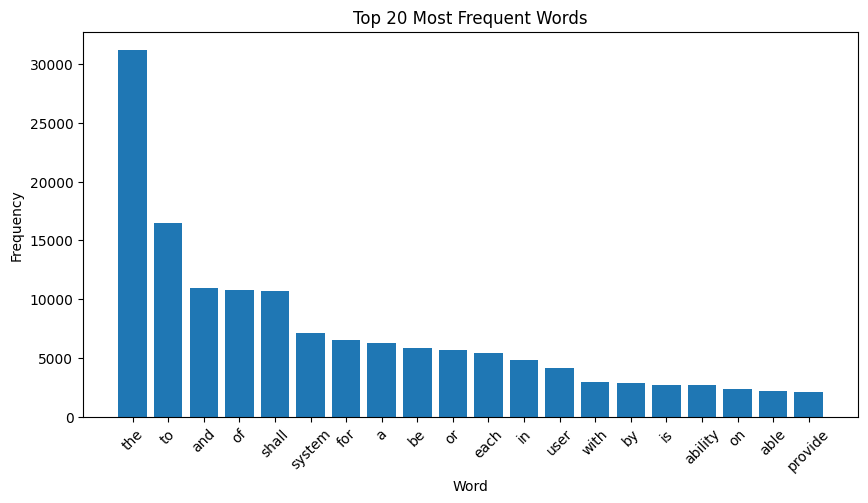

In [27]:


plt.figure(figsize=(10,5))
plt.bar(common_words["word"], common_words["count"])
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [28]:
#Nettoyer les mots inutiles (STOPWORDS)
# 🔹 Texte pour analyse seulement (on garde l’original intact)
text_for_analysis = df_requirements["text"].astype(str).str.lower()

# 🔹 Tokenisation simple
all_words = " ".join(text_for_analysis).split()

# 🔹 Stopwords
stopwords = [
    "the","to","and","of","a","an","is","are","in","on","for","with","by",
    "shall","must","should","be","each","or"
]

# 🔹 Filtrage
filtered_words = [w for w in all_words if w not in stopwords]

# 🔹 Comptage
from collections import Counter
word_counts = Counter(filtered_words)

# 🔹 Top mots
common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])
display(common_words)

,word,count
0,system,7124
1,user,4170
2,ability,2686
3,able,2235
4,provide,2088
5,information,2047
6,data,2028
7,as,1949
8,that,1932
9,only,1922


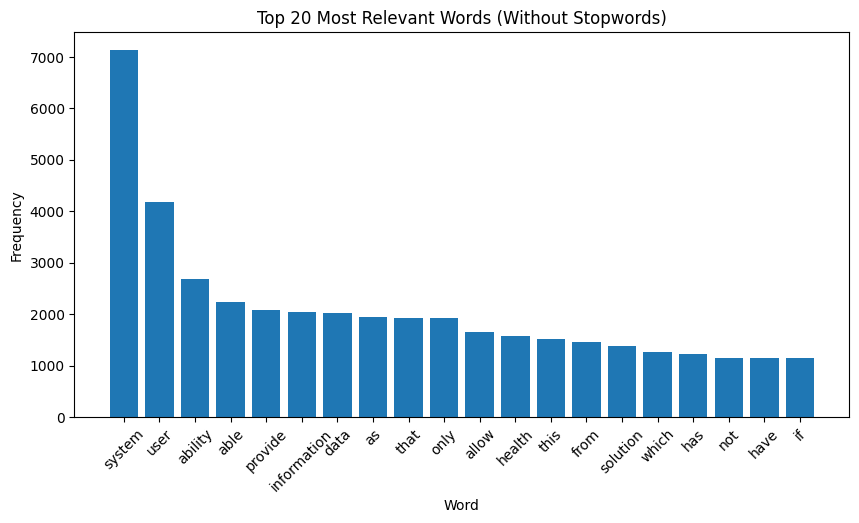

In [29]:
plt.figure(figsize=(10,5))
plt.bar(common_words["word"], common_words["count"])
plt.title("Top 20 Most Relevant Words (Without Stopwords)")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [30]:
display(df_requirements.sample(20, random_state=42))

,text,label,sub_label,quality_note,source,text_dedup,text_length_chars,text_length_words,has_shall,has_must,has_should
22482,3.2.36.4 Alternate Flows.,FR,functional,unknown,PURE,3 2 36 4 alternate flows,25,3,0,0,0
4463,Data and event logging,FR,functional,unknown,FNFC,data and event logging,22,4,0,0,0
21362,A covered entity must document the following a...,FR,functional,unknown,PURE,a covered entity must document the following a...,102,15,0,1,0
10657,System shall ensure portability by enabling ac...,NFR,general,unknown,FR_NFR,system shall ensure portability by enabling ac...,139,22,1,0,0
3880,MARC bibliographic and authority records can b...,FR,functional,unknown,FNFC,marc bibliographic and authority records can b...,319,47,0,0,0
23266,The system has an unmerge process.,FR,functional,unknown,PURE,the system has an unmerge process,34,6,0,0,0
9795,The BE shall store input data records in a mem...,FR,general,unknown,FR_NFR,the be shall store input data records in a mem...,136,24,1,0,0
12473,"Upon selecting Home, system shall display vide...",FR,general,unknown,FR_NFR,upon selecting home system shall display video...,97,14,1,0,0
22704,The LHCP can view of the comprehensive patient...,NFR,security,unknown,PURE,the lhcp can view of the comprehensive patient...,110,17,0,0,0
4383,Upload File,FR,functional,unknown,FNFC,upload file,11,2,0,0,0


In [31]:
# ======================================
# FINAL CLEAN DATASET SAVED
# ======================================
# This dataset is fully cleaned, deduplicated,
# and ready for machine learning tasks.

# version complète
df_requirements.to_csv("/kaggle/working/final_requirements_merged_clean_full.csv", index=False)

# version pour ML
df_model = df_requirements[["text", "label", "sub_label", "quality_note", "source"]].copy()
df_model.to_csv("/kaggle/working/final_requirements_merged_clean_model.csv", index=False)

**modèle FR vs NFR**

In [32]:
# ==============================
# STEP 1 - Prepare binary dataset
# ==============================

df_ml = df_balanced[df_balanced["label"].isin(["FR", "NFR"])].copy()

print("Shape of ML dataset:", df_ml.shape)
print("\nLabel distribution:")
print(df_ml["label"].value_counts())

display(df_ml.head(10))

Shape of ML dataset: (1208, 11)

Label distribution:
label
FR     604
NFR    604
Name: count, dtype: int64


,text,label,sub_label,quality_note,source,text_dedup,text_length_chars,text_length_words,has_shall,has_must,has_should
14268,The system shall display a confirmation messag...,FR,general,unknown,FR_NFR,the system shall display a confirmation messag...,91,14,1,0,0
17792,The solution should provide the ability to der...,FR,functional,unknown,PURE,the solution should provide the ability to der...,77,13,0,0,1
6985,Language switch button shall toggle the websit...,FR,functional,unknown,FNFC,language switch button shall toggle the websit...,130,19,1,0,0
16689,(i) To rebut the finding of a violation with s...,FR,functional,unknown,PURE,i to rebut the finding of a violation with suf...,150,26,0,0,0
8794,"Healthcare workers wants to able to create, ed...",FR,functional,unknown,FNFC,healthcare workers wants to able to create edi...,74,12,0,0,0
3532,System shall allow user to zoom in and out of ...,FR,functional,unknown,FNFC,system shall allow user to zoom in and out of ...,60,12,1,0,0
825,Icons will clearly illustrate the feature it r...,FR,functional,unknown,PROMISE,icons will clearly illustrate the feature it r...,56,8,0,0,0
15846,As specified by the Library of Congress ISO 63...,FR,functional,unknown,PURE,as specified by the library of congress iso 63...,138,24,0,0,0
17987,The solution should provide the ability to com...,FR,functional,unknown,PURE,the solution should provide the ability to com...,165,23,0,0,1
6568,Ability to maintain job descriptions for each ...,FR,functional,unknown,FNFC,ability to maintain job descriptions for each ...,69,11,0,0,0


In [33]:
# ==============================
# STEP 2 - Define X and y
# ==============================

X_text = df_ml["text"]
y = df_ml["label"]

print("Number of texts:", len(X_text))
print("Number of labels:", len(y))

Number of texts: 1208
Number of labels: 1208


In [34]:
# ==============================
# STEP 3 - Train / Test Split
# ==============================

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 966
Test size: 242

Train label distribution:
label
NFR    483
FR     483
Name: count, dtype: int64

Test label distribution:
label
FR     121
NFR    121
Name: count, dtype: int64


In [35]:
# ==============================
# STEP 4 - TF-IDF Vectorization
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (966, 5000)
X_test_tfidf shape: (242, 5000)


In [36]:
# ==============================
# STEP 5 - Train Logistic Regression
# ==============================

from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logreg_model.fit(X_train_tfidf, y_train)

print("Model trained successfully.")

Model trained successfully.


In [37]:
# ==============================
# STEP 6 - Predictions
# ==============================

y_pred = logreg_model.predict(X_test_tfidf)

print("Predictions done.")
print("First 10 predictions:", y_pred[:10])

Predictions done.
First 10 predictions: ['NFR' 'NFR' 'NFR' 'NFR' 'FR' 'FR' 'NFR' 'NFR' 'NFR' 'NFR']


In [38]:
# ==============================
# STEP 7 - Evaluation
# ==============================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.743801652892562

Classification Report:
              precision    recall  f1-score   support

          FR       0.78      0.68      0.73       121
         NFR       0.72      0.81      0.76       121

    accuracy                           0.74       242
   macro avg       0.75      0.74      0.74       242
weighted avg       0.75      0.74      0.74       242


Confusion Matrix:
[[82 39]
 [23 98]]


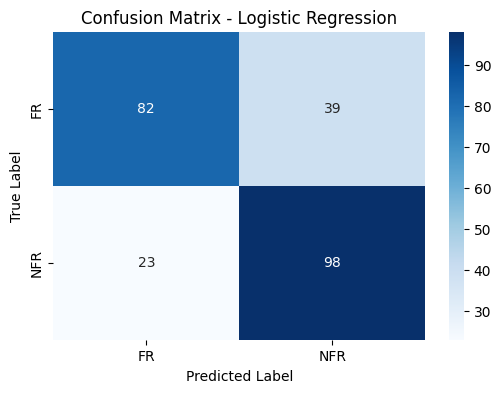

In [39]:
# ==============================
# STEP 8 - Confusion Matrix Visualization
# ==============================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["FR", "NFR"])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FR", "NFR"],
    yticklabels=["FR", "NFR"]
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [40]:
# ==============================
# STEP 9 - Compare Predictions with Real Labels
# ==============================

results_df = pd.DataFrame({
    "text": X_test_text.values,
    "true_label": y_test.values,
    "predicted_label": y_pred
})

display(results_df.sample(15, random_state=42))

,text,true_label,predicted_label
24,"Healthcare workers wants to able to create, ed...",FR,FR
6,"Above, shall be accomplished in manner that is...",NFR,NFR
152,Only authorized user shall access the RFS syst...,NFR,NFR
209,personal information security define outside s...,NFR,NFR
237,* unsuccessful user logins,FR,NFR
199,The solution should provide the ability to cap...,FR,FR
190,The system shall be maintainable through modul...,NFR,NFR
150,The data in the database is analyzed according...,NFR,FR
9,The Clinical Decision Support capability shoul...,FR,NFR
113,PART 164âSECURITY AND PRIVACY,FR,NFR


In [41]:
# ==============================
# STEP 10 - Manual Testing
# ==============================

sample_requirements = [
    "The system shall allow users to reset their password.",
    "The system shall respond within 2 seconds.",
    "All passwords must be encrypted.",
    "The user shall be able to upload profile pictures.",
    "The application should be easy to use."
]

sample_vectors = tfidf.transform(sample_requirements)
sample_predictions = logreg_model.predict(sample_vectors)

manual_test_df = pd.DataFrame({
    "requirement": sample_requirements,
    "predicted_label": sample_predictions
})

display(manual_test_df)

,requirement,predicted_label
0,The system shall allow users to reset their pa...,FR
1,The system shall respond within 2 seconds.,NFR
2,All passwords must be encrypted.,NFR
3,The user shall be able to upload profile pictu...,FR
4,The application should be easy to use.,NFR


In [42]:
# ==============================
# STEP 11 - Important Words Analysis
# ==============================

feature_names = tfidf.get_feature_names_out()
coefficients = logreg_model.coef_[0]

top_positive_idx = coefficients.argsort()[-15:]
top_negative_idx = coefficients.argsort()[:15]

top_positive_words = [feature_names[i] for i in top_positive_idx]
top_negative_words = [feature_names[i] for i in top_negative_idx]

print("Top words for FR:")
print(top_positive_words)

print("\nTop words for NFR:")
print(top_negative_words)

Top words for FR:
['all', 'click', 'ensure', 'user', 'interface', 'and', 'within', 'shall have', 'security', 'access', 'product shall', 'be', 'shall', 'system', 'use']

Top words for NFR:
['each', 'shall allow', 'ability', 'ability to', 'allow', 'order', 'user shall', 'be able', 'able to', 'content', 'calculate', 'preconditions', 'has', 'from', 'display']


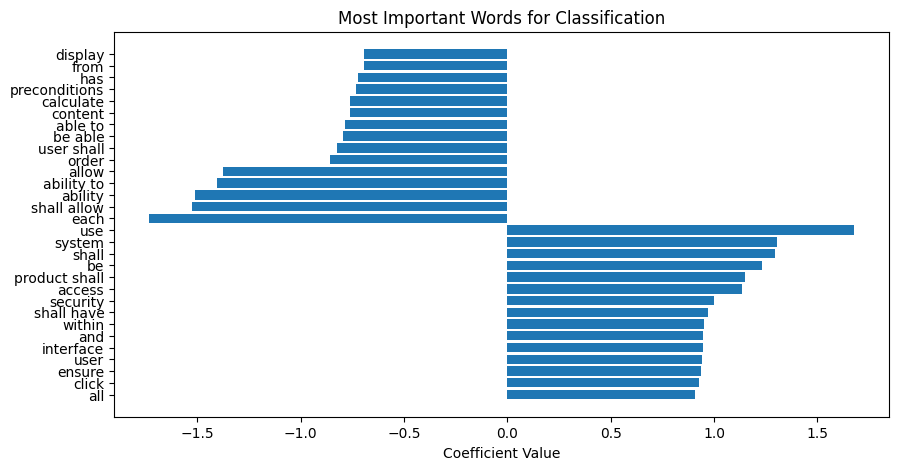

In [43]:
import matplotlib.pyplot as plt

top_words = top_positive_words + top_negative_words
top_scores = list(coefficients[top_positive_idx]) + list(coefficients[top_negative_idx])

plt.figure(figsize=(10,5))
plt.barh(top_words, top_scores)
plt.title("Most Important Words for Classification")
plt.xlabel("Coefficient Value")
plt.show()

In [44]:
# ==============================
# STEP 12 - Error Analysis
# ==============================

errors = results_df[results_df["true_label"] != results_df["predicted_label"]]

print("Number of errors:", len(errors))

display(errors.sample(10, random_state=42))

Number of errors: 62


,text,true_label,predicted_label
206,This includes browser-based server-side archit...,FR,NFR
218,The list of possible reason codes must be deri...,FR,NFR
0,The ROW Chief shall also assign the Project Te...,FR,NFR
220,Users shall be able to participate in discussi...,FR,NFR
19,(ii) A covered entity is not required to agree...,NFR,FR
204,System shall provide a menu-driven interface w...,FR,NFR
78,System shall link datasets with project metada...,NFR,FR
52,User shall be able to access the site with thr...,FR,NFR
120,The solution should provide the ability to att...,NFR,FR
227,System shall facilitate accounts managers in v...,FR,NFR


In [45]:
# ==============================
# STEP 13 - Train SVM
# ==============================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM trained successfully.")
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nSVM Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM trained successfully.
SVM Accuracy: 0.7355371900826446

SVM Classification Report:
              precision    recall  f1-score   support

          FR       0.76      0.69      0.72       121
         NFR       0.71      0.79      0.75       121

    accuracy                           0.74       242
   macro avg       0.74      0.74      0.73       242
weighted avg       0.74      0.74      0.73       242


SVM Confusion Matrix:
[[83 38]
 [26 95]]


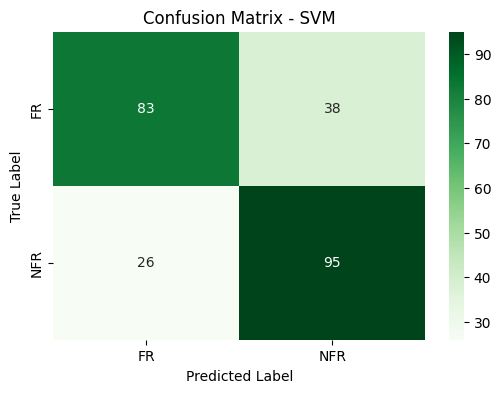

In [46]:
# ==============================
# STEP 14 - SVM Confusion Matrix
# ==============================

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=["FR", "NFR"])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["FR", "NFR"],
    yticklabels=["FR", "NFR"]
)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [47]:
# ==============================
# STEP 15 - Hyperparameter Tuning (LogReg)
# ==============================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.1, 1, 10]
}

grid_logreg = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_logreg.fit(X_train_tfidf, y_train)

print("Best LogReg params:", grid_logreg.best_params_)
print("Best CV score:", grid_logreg.best_score_)

Best LogReg params: {'C': 10}
Best CV score: 0.7691511387163561


In [48]:
# ==============================
# STEP 16 - Best Tuned LogReg Evaluation
# ==============================

best_logreg = grid_logreg.best_estimator_
y_pred_best_logreg = best_logreg.predict(X_test_tfidf)

print("Tuned LogReg Accuracy:", accuracy_score(y_test, y_pred_best_logreg))

print("\nTuned LogReg Classification Report:")
print(classification_report(y_test, y_pred_best_logreg))

print("\nTuned LogReg Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_logreg))

Tuned LogReg Accuracy: 0.7396694214876033

Tuned LogReg Classification Report:
              precision    recall  f1-score   support

          FR       0.77      0.69      0.72       121
         NFR       0.72      0.79      0.75       121

    accuracy                           0.74       242
   macro avg       0.74      0.74      0.74       242
weighted avg       0.74      0.74      0.74       242


Tuned LogReg Confusion Matrix:
[[83 38]
 [25 96]]


In [49]:
# ==============================
# STEP 17 - Model Comparison
# ==============================

models_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Tuned Logistic Regression": accuracy_score(y_test, y_pred_best_logreg),
}

comparison_df = pd.DataFrame.from_dict(
    models_results,
    orient="index",
    columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=False)

display(comparison_df)

,Accuracy
Logistic Regression,0.743802
Tuned Logistic Regression,0.739669
SVM,0.735537


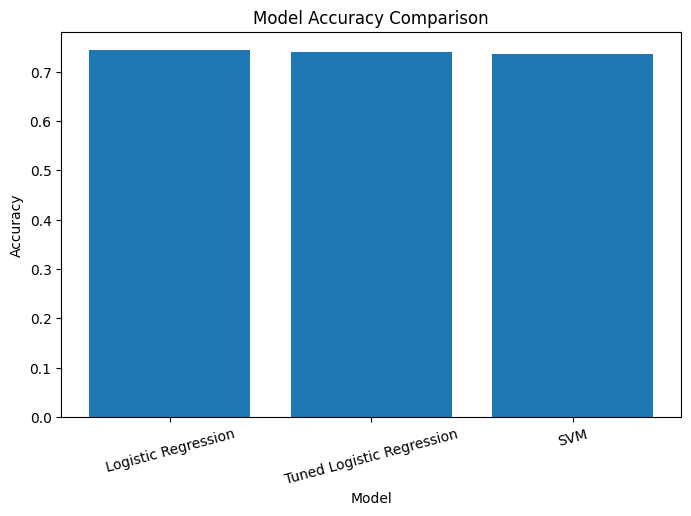

In [50]:
# ==============================
# STEP 18 - Accuracy Comparison Plot
# ==============================

plt.figure(figsize=(8, 5))
plt.bar(comparison_df.index, comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

In [51]:
errors = results_df[results_df["true_label"] != results_df["predicted_label"]]
print("Number of errors:", len(errors))
display(errors.sample(10, random_state=42))

Number of errors: 62


,text,true_label,predicted_label
206,This includes browser-based server-side archit...,FR,NFR
218,The list of possible reason codes must be deri...,FR,NFR
0,The ROW Chief shall also assign the Project Te...,FR,NFR
220,Users shall be able to participate in discussi...,FR,NFR
19,(ii) A covered entity is not required to agree...,NFR,FR
204,System shall provide a menu-driven interface w...,FR,NFR
78,System shall link datasets with project metada...,NFR,FR
52,User shall be able to access the site with thr...,FR,NFR
120,The solution should provide the ability to att...,NFR,FR
227,System shall facilitate accounts managers in v...,FR,NFR


## Model Comparison Analysis

We evaluated three machine learning models for requirement classification:

- Logistic Regression (baseline)
- Support Vector Machine (SVM)
- Tuned Logistic Regression (GridSearch)

### Observations:

- All models achieved similar performance (~73–74% accuracy)
- Logistic Regression performed slightly better
- Hyperparameter tuning did not significantly improve performance
- SVM did not outperform the baseline model

### Conclusion:

This suggests that the limitation is not the model itself, but the text representation (TF-IDF).

To achieve better performance, more advanced NLP models such as transformer-based models (e.g., BERT) should be used.

### Next Step:

We will move to deep learning models to improve contextual understanding of requirements.

In [52]:
# ==============================
# STEP 19 - Install / Import BERT tools
# ==============================



import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [53]:
# ==============================
# STEP 20 - Prepare dataset for BERT
# ==============================

df_bert = df_ml[["text", "label"]].copy()

label_map = {"FR": 0, "NFR": 1}
id2label = {0: "FR", 1: "NFR"}

df_bert["label_id"] = df_bert["label"].map(label_map)

print(df_bert.shape)
display(df_bert.head())
print(df_bert["label"].value_counts())

(1208, 3)


,text,label,label_id
14268,The system shall display a confirmation messag...,FR,0
17792,The solution should provide the ability to der...,FR,0
6985,Language switch button shall toggle the websit...,FR,0
16689,(i) To rebut the finding of a violation with s...,FR,0
8794,"Healthcare workers wants to able to create, ed...",FR,0


label
FR     604
NFR    604
Name: count, dtype: int64


In [54]:
# ==============================
# STEP 21 - Train / Validation / Test split
# ==============================

train_df, temp_df = train_test_split(
    df_bert,
    test_size=0.2,
    random_state=42,
    stratify=df_bert["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_id"]
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())



Train: (966, 3)
Validation: (121, 3)
Test: (121, 3)

Train labels:
label
NFR    483
FR     483
Name: count, dtype: int64

Validation labels:
label
NFR    61
FR     60
Name: count, dtype: int64

Test labels:
label
FR     61
NFR    60
Name: count, dtype: int64


In [55]:
# ==============================
# STEP 22 - Convert to Hugging Face datasets
# ==============================

from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df[["text", "label_id"]].rename(columns={"label_id": "label"}))
val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]].rename(columns={"label_id": "label"}))
test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]].rename(columns={"label_id": "label"}))

print(train_dataset)
print(val_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 966
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 121
})
Dataset({
    features: ['text', 'label', '__index_level_0__'],
    num_rows: 121
})


In [56]:
# ==============================
# STEP 23 - Load tokenizer
# ==============================

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [57]:
# ==============================
# STEP 24 - Tokenize text
# ==============================

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
val_tokenized = val_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.remove_columns(["text"])
val_tokenized = val_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")
test_tokenized.set_format("torch")

Map:   0%|          | 0/966 [00:00<?, ? examples/s]

Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/121 [00:00<?, ? examples/s]

In [58]:
# ==============================
# STEP 25 - Load DistilBERT model
# ==============================

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label_map
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [59]:
# ==============================
# STEP 26 - Metrics function
# ==============================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

In [60]:
import transformers
print(transformers.__version__)

5.0.0


In [61]:
# ==============================
# STEP 27 - Training arguments
# ==============================
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
)

In [62]:
# ==============================
# STEP 28 - Trainer
# ==============================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)


In [63]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,1.239155,1.054318,0.801653
2,0.926515,0.915314,0.776860
3,0.719595,0.894044,0.752066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=183, training_loss=0.9617548457911758, metrics={'train_runtime': 33.1508, 'train_samples_per_second': 87.419, 'train_steps_per_second': 5.52, 'total_flos': 95972630326272.0, 'train_loss': 0.9617548457911758, 'epoch': 3.0})

In [64]:
# ==============================
# STEP 29 - Final evaluation with predict()
# ==============================

pred_output = trainer.predict(test_tokenized)

y_true_bert = pred_output.label_ids
y_pred_bert = np.argmax(pred_output.predictions, axis=1)

bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)

print("DistilBERT Accuracy:", bert_accuracy)
print("\nClassification Report:")
print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=["FR", "NFR"]
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Accuracy: 0.7520661157024794

Classification Report:
              precision    recall  f1-score   support

          FR       0.76      0.74      0.75        61
         NFR       0.74      0.77      0.75        60

    accuracy                           0.75       121
   macro avg       0.75      0.75      0.75       121
weighted avg       0.75      0.75      0.75       121



In [65]:
# ==============================
# STEP 30 - Predictions on Test Set
# ==============================

predictions = trainer.predict(test_tokenized)

y_pred_bert = predictions.predictions.argmax(axis=1)
y_true_bert = predictions.label_ids

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


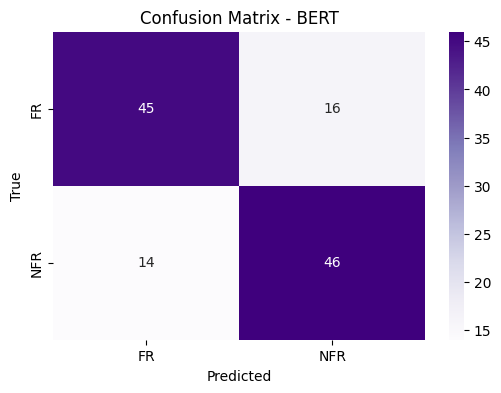

In [66]:
# ==============================
# STEP 31 - Confusion Matrix BERT
# ==============================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["FR", "NFR"],
    yticklabels=["FR", "NFR"]
)
plt.title("Confusion Matrix - BERT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [67]:
# ==============================
# STEP 32 - Final Model Comparison
# ==============================

bert_accuracy = (y_pred_bert == y_true_bert).mean()

final_results = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "BERT": bert_accuracy
}

import pandas as pd

final_df = pd.DataFrame.from_dict(
    final_results,
    orient='index',
    columns=["Accuracy"]
).sort_values(by="Accuracy", ascending=False)

display(final_df)

,Accuracy
BERT,0.752066
Logistic Regression,0.743802
SVM,0.735537


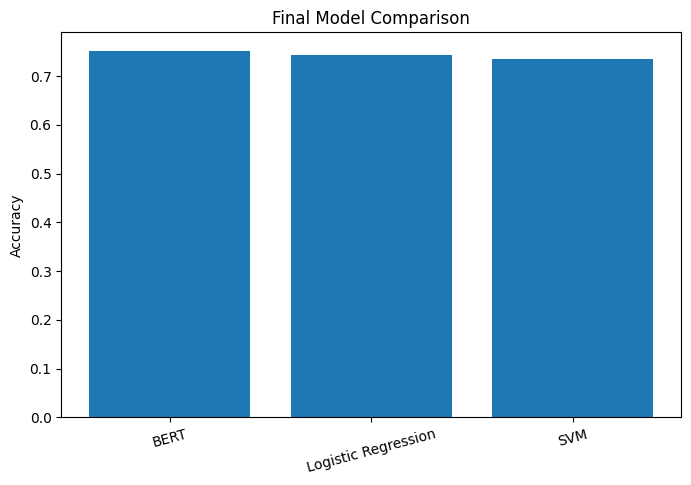

In [68]:
plt.figure(figsize=(8,5))
plt.bar(final_df.index, final_df["Accuracy"])
plt.title("Final Model Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

In [69]:
# ==============================
# STEP 33 - BERT Error Analysis
# ==============================

errors_bert = pd.DataFrame({
    "text": test_df["text"].values,
    "true": y_true_bert,
    "pred": y_pred_bert
})

errors_bert = errors_bert[errors_bert["true"] != errors_bert["pred"]]

print("Number of BERT errors:", len(errors_bert))
display(errors_bert.sample(20))

Number of BERT errors: 30


,text,true,pred
117,Agricultural research data are inherently spat...,0,1
71,* who or when marked a lab procedure as comple...,1,0
104,The solution should provide the ability to cre...,1,0
76,The system shall provide selection menus to mi...,1,0
43,(ii) A covered entity is not required to agree...,1,0
46,The packaging must come with each manual each ...,0,1
118,All Feature Layers shall have each Definition ...,0,1
111,This includes browser-based server-side archit...,0,1
66,Errors of any kind that might be corrected if ...,0,1
1,The patient looks for an hospital with experie...,1,0


In [70]:
# ==============================
# STEP 34 - Example Comparison
# ==============================

examples = [
    "The system shall allow users to login.",
    "The system shall respond within 2 seconds.",
    "The application should be easy to use.",
    "All data must be encrypted.",
]

inputs = tokenizer(examples, return_tensors="pt", padding=True, truncation=True).to("cuda" if torch.cuda.is_available() else "cpu")

outputs = model(**inputs)
preds = outputs.logits.argmax(dim=1).cpu().numpy()

for text, pred in zip(examples, preds):
    print(f"{text} → {'FR' if pred == 0 else 'NFR'}")

The system shall allow users to login. → FR
The system shall respond within 2 seconds. → NFR
The application should be easy to use. → NFR
All data must be encrypted. → NFR


In [71]:
# ==============================
# STEP 34 - Error Type Analysis
# ==============================

errors_bert["length"] = errors_bert["text"].apply(len)

print("Average length of error sentences:", errors_bert["length"].mean())

display(errors_bert.sort_values(by="length").head(10))

Average length of error sentences: 128.76666666666668


,text,true,pred,length
114,The system shall space alerts each 15 minutes.,0,1,46
71,* who or when marked a lab procedure as comple...,1,0,50
99,The solution should comply with the HIPAA Priv...,0,1,55
58,HEC rules shall be implemented while creating ...,1,0,57
15,The user can choose to examine recent trends i...,1,0,58
43,(ii) A covered entity is not required to agree...,1,0,64
120,Application has the capable of continue the su...,1,0,66
81,The Disputes application shall interface with ...,0,1,69
32,User shall enter the mobile number and receive...,0,1,71
89,The payment success page structure and content...,0,1,75


The model makes errors mainly in the following cases:

1. Short sentences:
   Short requirements often lack sufficient context, making classification difficult.

2. Ambiguous requirements:
   Some requirements contain both functional and non-functional aspects.

3. Lack of explicit keywords:
   Requirements without clear indicators such as "performance", "security", or "user action"
   are harder to classify.

4. Mixed semantics:
   Some requirements describe behavior and constraints at the same time.

In [72]:
# ==============================
# STEP 35 - Error Categorization
# ==============================

def categorize_error(text):
    text = text.lower()
    
    if "seconds" in text or "minutes" in text or "time" in text:
        return "Timing / Performance (NFR confusion)"
    
    elif "secure" in text or "encrypt" in text or "privacy" in text:
        return "Security (NFR)"
    
    elif "user" in text or "click" in text or "display" in text:
        return "User Action (FR)"
    
    else:
        return "Ambiguous"

errors_bert["error_type"] = errors_bert["text"].apply(categorize_error)

display(errors_bert["error_type"].value_counts())

error_type
Ambiguous                               21
User Action (FR)                         5
Timing / Performance (NFR confusion)     2
Security (NFR)                           2
Name: count, dtype: int64

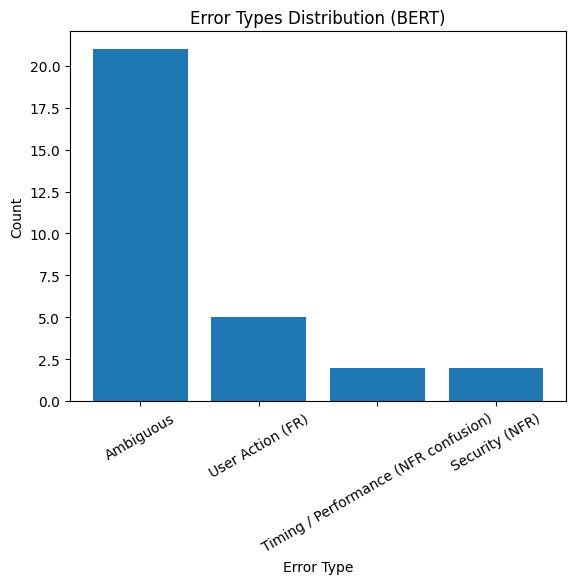

In [73]:
# ==============================
# STEP 36 - Error Types Plot
# ==============================

import matplotlib.pyplot as plt

error_counts = errors_bert["error_type"].value_counts()

plt.figure()
plt.bar(error_counts.index, error_counts.values)
plt.title("Error Types Distribution (BERT)")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

The error analysis reveals that:

- The majority of misclassifications are due to ambiguous requirements.
- The model performs well when requirements contain clear semantic indicators (e.g., security terms).
- Confusion mainly occurs when requirements mix functional and non-functional aspects.
- This suggests that improving requirement clarity is as important as improving the model itself.

This highlights a key real-world challenge in software engineering:
Poorly written requirements can significantly impact AI-based analysis.

The model errors can be grouped into several categories:

1. Timing / Performance errors:
   Requirements involving time constraints are sometimes confused with functional requirements.

2. Security-related ambiguity:
   Some security requirements lack explicit keywords, making them harder to classify.

3. User-action confusion:
   Requirements mentioning "user" or "actions" are sometimes incorrectly classified as functional.

4. Ambiguous requirements:
   Some requirements do not clearly belong to a single category and contain mixed semantics.

This analysis shows that the model struggles mainly with semantic ambiguity rather than simple classification.

In [74]:
def explain_prediction(text):
    device = model.device

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits.softmax(dim=1)

    return {
        "text": text,
        "FR_prob": float(probs[0][0].cpu()),
        "NFR_prob": float(probs[0][1].cpu()),
        "predicted_label": "FR" if probs.argmax(dim=1).item() == 0 else "NFR"
    }

In [75]:
print(explain_prediction("The system shall respond within 2 seconds."))

{'text': 'The system shall respond within 2 seconds.', 'FR_prob': 0.43239516019821167, 'NFR_prob': 0.5676048398017883, 'predicted_label': 'NFR'}


In [76]:
def explain_predictions(texts):
    device = model.device

    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = outputs.logits.softmax(dim=1).cpu().numpy()

    results = []
    for text, p in zip(texts, probs):
        results.append({
            "text": text,
            "FR_prob": float(p[0]),
            "NFR_prob": float(p[1]),
            "predicted_label": "FR" if p[0] > p[1] else "NFR"
        })

    return pd.DataFrame(results)

In [77]:
sample_texts = [
    "The system shall allow users to login.",
    "The system shall respond within 2 seconds.",
    "All passwords must be encrypted.",
    "The application should be easy to use."
]

display(explain_predictions(sample_texts))

,text,FR_prob,NFR_prob,predicted_label
0,The system shall allow users to login.,0.513601,0.486399,FR
1,The system shall respond within 2 seconds.,0.432395,0.567605,NFR
2,All passwords must be encrypted.,0.335367,0.664633,NFR
3,The application should be easy to use.,0.362570,0.637430,NFR


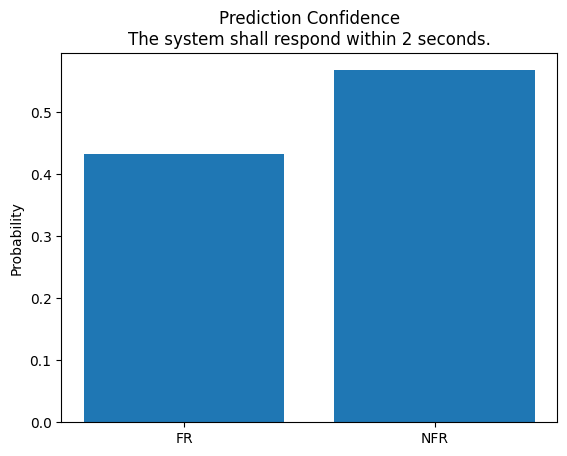

In [78]:
import matplotlib.pyplot as plt

def plot_prediction(text):
    result = explain_prediction(text)

    labels = ["FR", "NFR"]
    values = [result["FR_prob"], result["NFR_prob"]]

    plt.figure()
    plt.bar(labels, values)
    plt.title(f"Prediction Confidence\n{text}")
    plt.ylabel("Probability")
    plt.show()

plot_prediction("The system shall respond within 2 seconds.")

In [79]:
# =========================================
# MODULE DEEP 1 — DISTILBERT FOR FR VS NFR
# =========================================

In [80]:
# =========================================
# STEP 1 - Prepare DistilBERT dataset
# =========================================

df_bert = df_ml[["text", "label"]].copy()

label_map = {"FR": 0, "NFR": 1}
id2label = {0: "FR", 1: "NFR"}

df_bert["label_id"] = df_bert["label"].map(label_map)

print("BERT dataset shape:", df_bert.shape)
print(df_bert["label"].value_counts())
display(df_bert.head())

BERT dataset shape: (1208, 3)
label
FR     604
NFR    604
Name: count, dtype: int64


,text,label,label_id
14268,The system shall display a confirmation messag...,FR,0
17792,The solution should provide the ability to der...,FR,0
6985,Language switch button shall toggle the websit...,FR,0
16689,(i) To rebut the finding of a violation with s...,FR,0
8794,"Healthcare workers wants to able to create, ed...",FR,0


In [81]:
# =========================================
# STEP 2 - Train / Test Split
# =========================================

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_bert,
    test_size=0.2,
    random_state=42,
    stratify=df_bert["label_id"]
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("\nTrain distribution:")
print(train_df["label"].value_counts())
print("\nTest distribution:")
print(test_df["label"].value_counts())

Train size: 966
Test size: 242

Train distribution:
label
NFR    483
FR     483
Name: count, dtype: int64

Test distribution:
label
FR     121
NFR    121
Name: count, dtype: int64


In [82]:
# =========================================
# STEP 3 - Install / Import transformers
# =========================================



import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [83]:
# =========================================
# STEP 5 - Load tokenizer
# =========================================

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

train_tokenized = train_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

Map:   0%|          | 0/966 [00:00<?, ? examples/s]

Map:   0%|          | 0/121 [00:00<?, ? examples/s]

In [84]:
# =========================================
# STEP 6 - Load DistilBERT model
# =========================================

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label_map
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [85]:
# =========================================
# STEP 7 - Define metrics
# =========================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc}

In [86]:
# =========================================
# STEP 8 - Training arguments
# =========================================

training_args = TrainingArguments(
    output_dir="./distilbert_fr_nfr_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

In [87]:
# =========================================
# STEP 9 - Trainer
# =========================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

In [88]:
# =========================================
# STEP 10 - Train DistilBERT
# =========================================

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy
1,1.285607,1.159335,0.702479
2,1.070909,1.058614,0.760331
3,0.885826,1.029129,0.785124


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=93, training_loss=1.0807803984611266, metrics={'train_runtime': 26.7595, 'train_samples_per_second': 108.298, 'train_steps_per_second': 3.475, 'total_flos': 95972630326272.0, 'train_loss': 1.0807803984611266, 'epoch': 3.0})

In [89]:
# =========================================
# STEP 11 - Final evaluation
# =========================================

pred_output = trainer.predict(test_tokenized)

y_true_bert = pred_output.label_ids
y_pred_bert = np.argmax(pred_output.predictions, axis=1)

bert_accuracy = accuracy_score(y_true_bert, y_pred_bert)

print("DistilBERT Accuracy:", bert_accuracy)
print("\nClassification Report:")
print(classification_report(
    y_true_bert,
    y_pred_bert,
    target_names=["FR", "NFR"]
))

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


DistilBERT Accuracy: 0.7851239669421488

Classification Report:
              precision    recall  f1-score   support

          FR       0.84      0.70      0.77        61
         NFR       0.74      0.87      0.80        60

    accuracy                           0.79       121
   macro avg       0.79      0.79      0.78       121
weighted avg       0.79      0.79      0.78       121



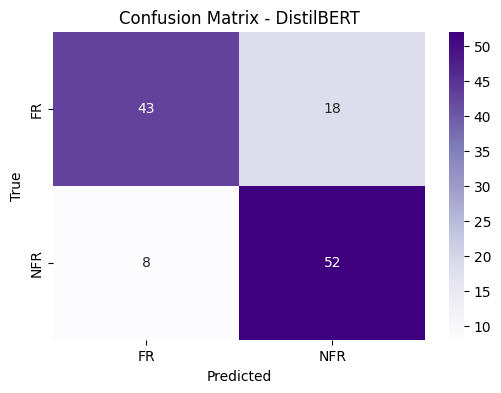

In [90]:
# =========================================
# STEP 12 - Confusion Matrix
# =========================================

import seaborn as sns
import matplotlib.pyplot as plt

cm_bert = confusion_matrix(y_true_bert, y_pred_bert)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["FR", "NFR"],
    yticklabels=["FR", "NFR"]
)
plt.title("Confusion Matrix - DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [91]:
# =========================================
# STEP 13 - Compare models
# =========================================

comparison_df = pd.DataFrame({
    "model": ["Logistic Regression", "SVM", "DistilBERT"],
    "accuracy": [0.743801652892562, 0.7355371900826446, bert_accuracy]
})

display(comparison_df)

,model,accuracy
0,Logistic Regression,0.743802
1,SVM,0.735537
2,DistilBERT,0.785124


In [92]:
# =========================================
# STEP 14 - Manual testing
# =========================================

sample_requirements_bert = [
    "The system shall allow users to reset their password.",
    "The system shall respond within 2 seconds.",
    "All passwords must be encrypted.",
    "The user shall be able to upload profile pictures.",
    "The application should be easy to use."
]

sample_tokens = tokenizer(
    sample_requirements_bert,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

device = model.device
sample_tokens = {k: v.to(device) for k, v in sample_tokens.items()}

model.eval()
with torch.no_grad():
    outputs = model(**sample_tokens)

sample_preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
sample_labels = [id2label[p] for p in sample_preds]

manual_bert_df = pd.DataFrame({
    "requirement": sample_requirements_bert,
    "predicted_label": sample_labels
})

display(manual_bert_df)

,requirement,predicted_label
0,The system shall allow users to reset their pa...,NFR
1,The system shall respond within 2 seconds.,NFR
2,All passwords must be encrypted.,NFR
3,The user shall be able to upload profile pictu...,FR
4,The application should be easy to use.,NFR


In [93]:
# =========================================
# STEP 15 - Reusable prediction function
# =========================================

def predict_fr_nfr_distilbert(text):
    tokens = tokenizer(
        [text],
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    device = model.device
    tokens = {k: v.to(device) for k, v in tokens.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**tokens)

    probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
    pred = int(np.argmax(probs))

    return {
        "text": text,
        "predicted_label": id2label[pred],
        "probabilities": {
            "FR": float(probs[0]),
            "NFR": float(probs[1])
        }
    }

In [94]:
predict_fr_nfr_distilbert("The system shall respond within 2 seconds.")

{'text': 'The system shall respond within 2 seconds.',
 'predicted_label': 'NFR',
 'probabilities': {'FR': 0.16479168832302094, 'NFR': 0.8352082967758179}}

In [95]:
# ==============================
# STEP 37 - Ambiguity Lexicon
# ==============================

ambiguity_lexicon = {
    "possibility": [
        "otherwise", "it can be", "it could be", "it is one of",
        "it must be", "should be", "it will be"
    ],

    "ambiguous_verbs": [
        "adjust", "change", "correct", "calculate", "compare", "derive",
        "determine", "enable", "indicate", "manipulate", "equalize",
        "modify", "play", "process", "support", "verify"
    ],

    "ambiguous_variables": [
        "data", "rule", "status", "value"
    ],

    "quantitative_adjectives": [
        "all", "any", "each", "few", "many", "same", "various",
        "similar", "some", "the complete", "the total"
    ],

    "ambiguous_adverbs": [
        "satisfactorily", "unconditionally", "in accordance", "almost",
        "approximately", "generally", "commonly", "habitually",
        "frequently", "almost never", "occasionally", "often",
        "more or less", "above all", "followed", "in the rare case",
        "ordinarily", "rarely", "very few times", "slowly",
        "something", "typically", "virtually"
    ],

    "implicit_references": [
        "also", "despite", "and also", "apart from", "but", "although",
        "besides", "in addition to", "that", "likewise",
        "on the other hand", "still", "the aforementioned",
        "the above", "these", "this", "while that"
    ],

    "time_ambiguity": [
        "after", "at a given moment", "in due time", "daily", "swiftly",
        "in a moment", "later", "monthly", "fast", "soon",
        "weekly", "annually"
    ],

    "total_ambiguity": [
        "etc", "etc.", "et cetera", "something"
    ]
}

In [96]:
# ==============================
# STEP 38 - Inspect ambiguity lexicon
# ==============================

for category, words in ambiguity_lexicon.items():
    print(f"{category}: {len(words)} words/phrases")

total_ambiguous_terms = sum(len(words) for words in ambiguity_lexicon.values())
print("\nTotal ambiguous terms:", total_ambiguous_terms)

possibility: 7 words/phrases
ambiguous_verbs: 16 words/phrases
ambiguous_variables: 4 words/phrases
quantitative_adjectives: 11 words/phrases
ambiguous_adverbs: 23 words/phrases
implicit_references: 17 words/phrases
time_ambiguity: 12 words/phrases
total_ambiguity: 4 words/phrases

Total ambiguous terms: 94


In [97]:
# ==============================
# STEP 39 - Detect ambiguity categories
# ==============================

def detect_ambiguity_categories(text, lexicon):
    text = str(text).lower()
    detected_categories = []

    for category, terms in lexicon.items():
        for term in terms:
            if term.lower() in text:
                detected_categories.append(category)
                break

    if not detected_categories:
        return ["clear"]

    return detected_categories

In [98]:
print(detect_ambiguity_categories(
    "The system should be fast and respond soon.",
    ambiguity_lexicon
))

['possibility', 'time_ambiguity']


In [99]:
# ==============================
# STEP 40 - Ambiguity score
# ==============================

def compute_ambiguity_score(text, lexicon):
    categories = detect_ambiguity_categories(text, lexicon)
    if categories == ["clear"]:
        return 0
    return len(categories)

In [100]:
# ==============================
# STEP 41 - Apply ambiguity detection
# ==============================

df_requirements["ambiguity_categories"] = df_requirements["text"].apply(
    lambda x: detect_ambiguity_categories(x, ambiguity_lexicon)
)

df_requirements["ambiguity_score"] = df_requirements["text"].apply(
    lambda x: compute_ambiguity_score(x, ambiguity_lexicon)
)

df_requirements["is_ambiguous_rule"] = df_requirements["ambiguity_score"].apply(
    lambda x: 1 if x > 0 else 0
)

display(df_requirements[["text", "ambiguity_categories", "ambiguity_score", "is_ambiguous_rule"]].head(10))

,text,ambiguity_categories,ambiguity_score,is_ambiguous_rule
0,The system shall refresh the display every 60 ...,"[ambiguous_verbs, quantitative_adjectives]",2,1
1,The application shall match the color of the s...,[quantitative_adjectives],1,1
2,If projected the data must be readable. On a 1...,[ambiguous_variables],1,1
3,The product shall be available during normal b...,[quantitative_adjectives],1,1
4,If projected the data must be understandable. ...,"[ambiguous_verbs, ambiguous_variables, implici...",3,1
5,The product shall ensure that it can only be a...,"[quantitative_adjectives, implicit_references]",2,1
6,The product shall be intuitive and self-explan...,"[ambiguous_verbs, quantitative_adjectives]",2,1
7,The product shall respond fast to keep up-to-d...,"[ambiguous_verbs, ambiguous_variables, quantit...",4,1
8,The system shall have a MDI form that allows f...,"[ambiguous_variables, quantitative_adjectives,...",3,1
9,The system shall display Events in a vertical ...,"[ambiguous_verbs, quantitative_adjectives]",2,1


is_ambiguous_rule
1    18069
0     6374
Name: count, dtype: int64


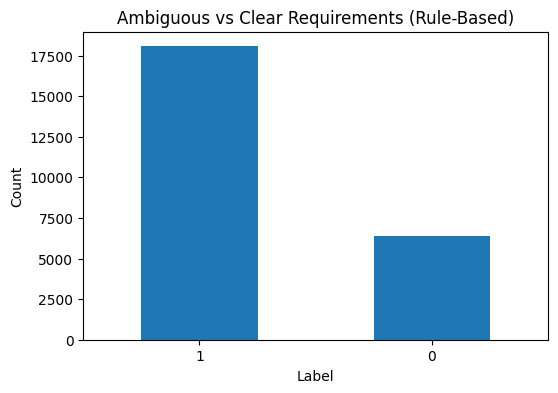

In [101]:
# ==============================
# STEP 42 - Ambiguity distribution
# ==============================

print(df_requirements["is_ambiguous_rule"].value_counts())

plt.figure(figsize=(6,4))
df_requirements["is_ambiguous_rule"].value_counts().plot(kind="bar")
plt.title("Ambiguous vs Clear Requirements (Rule-Based)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

ambiguity_score
0     6374
1    10858
2     5605
3     1348
4      231
5       24
6        3
Name: count, dtype: int64


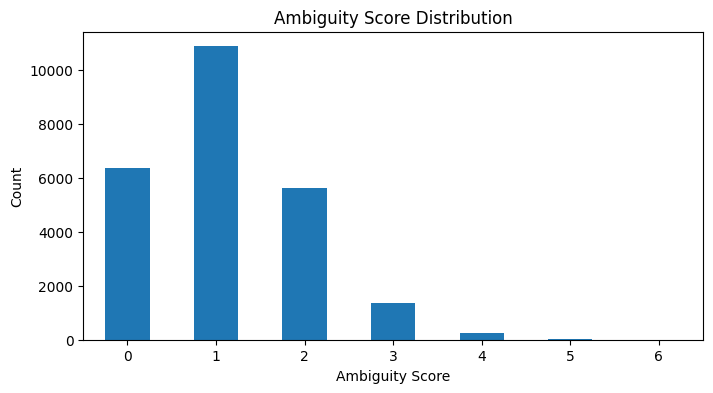

In [102]:
# ==============================
# STEP 43 - Ambiguity score distribution
# ==============================

print(df_requirements["ambiguity_score"].value_counts().sort_index())

plt.figure(figsize=(8,4))
df_requirements["ambiguity_score"].value_counts().sort_index().plot(kind="bar")
plt.title("Ambiguity Score Distribution")
plt.xlabel("Ambiguity Score")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

ambiguity_categories
quantitative_adjectives    14042
clear                       6374
ambiguous_verbs             4709
implicit_references         3444
ambiguous_variables         3374
time_ambiguity               631
possibility                  340
total_ambiguity              324
ambiguous_adverbs            310
Name: count, dtype: int64

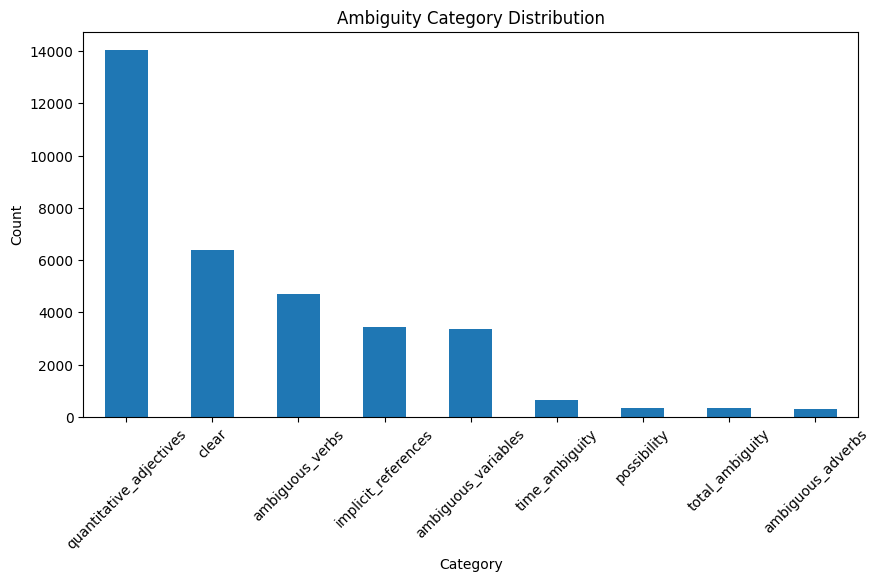

In [103]:
# ==============================
# STEP 44 - Category frequency analysis
# ==============================

df_amb_expanded = df_requirements[["text", "ambiguity_categories"]].explode("ambiguity_categories")

category_counts = df_amb_expanded["ambiguity_categories"].value_counts()

display(category_counts)

plt.figure(figsize=(10,5))
category_counts.plot(kind="bar")
plt.title("Ambiguity Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [104]:
# ==============================
# STEP 45 - Most ambiguous requirements
# ==============================

most_ambiguous = df_requirements.sort_values(by="ambiguity_score", ascending=False)

display(
    most_ambiguous[
        ["text", "ambiguity_categories", "ambiguity_score"]
    ].head(20)
)

,text,ambiguity_categories,ambiguity_score
15555,On behalf of _________________________________...,"[possibility, ambiguous_verbs, ambiguous_varia...",6
23399,System provides the following password change ...,"[ambiguous_verbs, ambiguous_variables, quantit...",6
7722,Whether digital maps shall be implemented as s...,"[ambiguous_verbs, quantitative_adjectives, amb...",6
7965,The system shall ask the user to specify each ...,"[possibility, ambiguous_verbs, ambiguous_varia...",5
8609,This application also requires each of which t...,"[possibility, ambiguous_verbs, ambiguous_varia...",5
25103,If this is your first time logging in to OpenE...,"[ambiguous_verbs, quantitative_adjectives, amb...",5
5000,Availability/Accuracy of Data Description: The...,"[ambiguous_verbs, ambiguous_variables, quantit...",5
15494,The User agrees that any use of CMS data in th...,"[ambiguous_verbs, ambiguous_variables, quantit...",5
7529,Allows to define parameter values for Data Sto...,"[ambiguous_verbs, ambiguous_variables, quantit...",5
4996,Display Hydrological Conditions Description: T...,"[ambiguous_verbs, ambiguous_variables, quantit...",5


In [105]:
# ==============================
# STEP 46 - Build ambiguity dataset
# ==============================

df_ambiguity = df_requirements[["text", "ambiguity_score", "is_ambiguous_rule"]].copy()

print(df_ambiguity.shape)
print(df_ambiguity["is_ambiguous_rule"].value_counts())

display(df_ambiguity.head())

(24443, 3)
is_ambiguous_rule
1    18069
0     6374
Name: count, dtype: int64


,text,ambiguity_score,is_ambiguous_rule
0,The system shall refresh the display every 60 ...,2,1
1,The application shall match the color of the s...,1,1
2,If projected the data must be readable. On a 1...,1,1
3,The product shall be available during normal b...,1,1
4,If projected the data must be understandable. ...,3,1


In [106]:
# ==============================
# STEP 47 — Split dataset
# ==============================

from sklearn.model_selection import train_test_split

train_amb, test_amb = train_test_split(
    df_ambiguity,
    test_size=0.2,
    stratify=df_ambiguity["is_ambiguous_rule"],
    random_state=42
)

In [107]:
# ==============================
# STEP 48 — Baseline (Logistic Regression)
# ==============================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_amb["text"])
X_test = vectorizer.transform(test_amb["text"])

y_train = train_amb["is_ambiguous_rule"]
y_test = test_amb["is_ambiguous_rule"]

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1275
           1       0.97      0.98      0.97      3614

    accuracy                           0.96      4889
   macro avg       0.95      0.94      0.94      4889
weighted avg       0.96      0.96      0.96      4889



In [108]:
label_map = {0: "clear", 1: "ambiguous"}

In [109]:
#STEP 49 — TF-IDF + Logistic Regression

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [110]:
#Vectorisation

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_amb["text"])
X_test = vectorizer.transform(test_amb["text"])

y_train = train_amb["is_ambiguous_rule"]
y_test = test_amb["is_ambiguous_rule"]

In [111]:
#Train model

model_amb = LogisticRegression(max_iter=200)
model_amb.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [112]:
#Prediction

y_pred_amb = model_amb.predict(X_test)

In [113]:
#Evaluation

print(classification_report(y_test, y_pred_amb))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92      1275
           1       0.97      0.98      0.97      3614

    accuracy                           0.96      4889
   macro avg       0.95      0.94      0.94      4889
weighted avg       0.96      0.96      0.96      4889



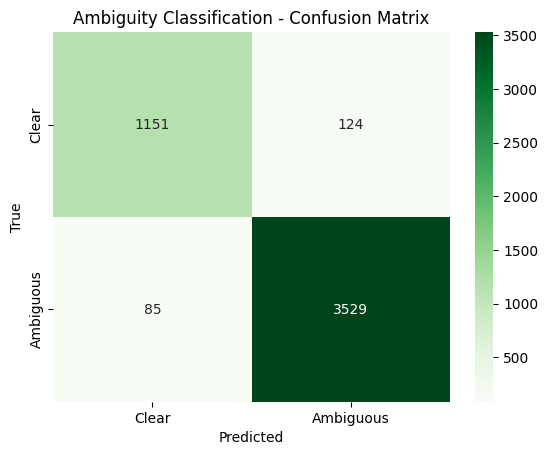

In [114]:
#Confusion Matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_amb)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Clear", "Ambiguous"],
            yticklabels=["Clear", "Ambiguous"])

plt.title("Ambiguity Classification - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [115]:
# ==============================
# STEP 51 - FINAL HYBRID ANALYZER
# ==============================

def analyze_requirement(text):

    bert_result = explain_prediction(text)

    ambiguity_score = compute_ambiguity_score(text, ambiguity_lexicon)
    ambiguity_categories = detect_ambiguity_categories(text, ambiguity_lexicon)

    X_input = vectorizer.transform([text])
    amb_pred = model_amb.predict(X_input)[0]

    # Rule-based decision
    rule_based_ambiguity = "Ambiguous" if ambiguity_score > 0 else "Clear"

    # Hybrid fusion
    if amb_pred == 1 or ambiguity_score > 0:
        final_ambiguity = "Ambiguous"
    else:
        final_ambiguity = "Clear"

    return {
        "text": text,
        "type": bert_result["predicted_label"],
        "FR_prob": bert_result["FR_prob"],
        "NFR_prob": bert_result["NFR_prob"],
        "ambiguity_score": ambiguity_score,
        "ambiguity_categories": ambiguity_categories,
        "ambiguity_rule": rule_based_ambiguity,
        "ambiguity_ml": "Ambiguous" if amb_pred == 1 else "Clear",
        "final_ambiguity": final_ambiguity
    }

In [116]:
analyze_requirement("The system should respond quickly and efficiently.")

{'text': 'The system should respond quickly and efficiently.',
 'type': 'NFR',
 'FR_prob': 0.19425131380558014,
 'NFR_prob': 0.805748701095581,
 'ambiguity_score': 0,
 'ambiguity_categories': ['clear'],
 'ambiguity_rule': 'Clear',
 'ambiguity_ml': 'Ambiguous',
 'final_ambiguity': 'Ambiguous'}

In [117]:
def explain_requirement(text):
    result = analyze_requirement(text)

    explanation = []

    if result["ambiguity_rule"] != result["ambiguity_ml"]:
        explanation.append("Conflict detected between rule-based and ML ambiguity predictions.")

    if result["final_ambiguity"] == "Ambiguous":
        explanation.append("This requirement may lead to misunderstanding or implementation issues.")

    if result["type"] == "NFR":
        explanation.append("The requirement is classified as a non-functional requirement.")

    return explanation

In [118]:
explain_requirement("The system should respond quickly and efficiently.")

['Conflict detected between rule-based and ML ambiguity predictions.',
 'This requirement may lead to misunderstanding or implementation issues.',
 'The requirement is classified as a non-functional requirement.']

### Hybrid Requirement Analysis

The final system combines three complementary approaches:

- Deep learning (BERT) for FR/NFR classification
- Rule-based ambiguity detection using a handcrafted ambiguity lexicon
- Machine learning ambiguity classification using TF-IDF and Logistic Regression

This hybrid design improves robustness and allows conflict analysis between lexical and learned ambiguity signals.

In [119]:
examples = [
    "The system shall allow users to reset their password.",
    "The system should respond quickly and efficiently.",
    "All passwords must be encrypted.",
    "The interface should be user-friendly.",
    "The application shall support 10,000 concurrent users."
]

for req in examples:
    print("=" * 80)
    print(analyze_requirement(req))
    print("Explanation:", explain_requirement(req))

{'text': 'The system shall allow users to reset their password.', 'type': 'NFR', 'FR_prob': 0.3587692677974701, 'NFR_prob': 0.6412307024002075, 'ambiguity_score': 1, 'ambiguity_categories': ['quantitative_adjectives'], 'ambiguity_rule': 'Ambiguous', 'ambiguity_ml': 'Ambiguous', 'final_ambiguity': 'Ambiguous'}
Explanation: ['This requirement may lead to misunderstanding or implementation issues.', 'The requirement is classified as a non-functional requirement.']
{'text': 'The system should respond quickly and efficiently.', 'type': 'NFR', 'FR_prob': 0.19425131380558014, 'NFR_prob': 0.805748701095581, 'ambiguity_score': 0, 'ambiguity_categories': ['clear'], 'ambiguity_rule': 'Clear', 'ambiguity_ml': 'Ambiguous', 'final_ambiguity': 'Ambiguous'}
Explanation: ['Conflict detected between rule-based and ML ambiguity predictions.', 'This requirement may lead to misunderstanding or implementation issues.', 'The requirement is classified as a non-functional requirement.']
{'text': 'All passwords

# Conclusion

In this notebook, we built a hybrid AI-based requirement analysis system for software specification documents.

The system combines:
- dataset merging and strong cleaning
- FR/NFR classification
- ambiguity detection using both rule-based and machine learning approaches
- hybrid decision fusion
- explainable outputs for requirement analysis

This work demonstrates that intelligent assistance can support startups and analysts in improving the quality of software requirements and identifying potentially problematic specifications.

Future work may include:
- requirement quality scoring
- automatic requirement rewriting
- missing section detection in full SRS documents
- complete specification generation from startup ideas

### Error Analysis

Some clearly written requirements may still be flagged as ambiguous by the rule-based detector.
This happens because lexical ambiguity rules can over-trigger on generic words without enough semantic context.

This observation justifies the use of a hybrid approach combining:
- rule-based ambiguity detection
- machine learning ambiguity classification
- deep learning requirement classification

# Conclusion

In this notebook, we built a hybrid AI-based requirement analysis system for software specification documents.

The system combines:
- dataset merging and strong cleaning
- FR/NFR classification
- ambiguity detection using both rule-based and machine learning approaches
- hybrid decision fusion
- explainable outputs for requirement analysis

This work demonstrates that intelligent assistance can support startups and analysts in improving the quality of software requirements and identifying potentially problematic specifications.

Future work may include:
- requirement quality scoring
- automatic requirement rewriting
- missing section detection in full SRS documents
- complete specification generation from startup ideas

In [120]:
# =========================================
# STEP 37A - Build ambiguity lexicon dataset
# =========================================

ambiguity_lexicon_rows = [
    # possibility
    {"term": "otherwise", "category": "possibility", "term_type": "phrase", "severity": 2, "notes": "conditional ambiguity"},
    {"term": "it can be", "category": "possibility", "term_type": "phrase", "severity": 2, "notes": "weak possibility"},
    {"term": "it could be", "category": "possibility", "term_type": "phrase", "severity": 2, "notes": "weak possibility"},
    {"term": "it is one of", "category": "possibility", "term_type": "phrase", "severity": 2, "notes": "non-specific alternative"},
    {"term": "it must be", "category": "possibility", "term_type": "phrase", "severity": 1, "notes": "context-dependent"},
    {"term": "should be", "category": "possibility", "term_type": "phrase", "severity": 3, "notes": "weak modality"},
    {"term": "it will be", "category": "possibility", "term_type": "phrase", "severity": 1, "notes": "future vague statement"},

    # ambiguous_verbs
    {"term": "adjust", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "unclear action"},
    {"term": "change", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "unclear action"},
    {"term": "correct", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "unclear action"},
    {"term": "calculate", "category": "ambiguous_verbs", "term_type": "word", "severity": 1, "notes": "can be vague without formula"},
    {"term": "compare", "category": "ambiguous_verbs", "term_type": "word", "severity": 1, "notes": "needs comparison criteria"},
    {"term": "derive", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "needs derivation rule"},
    {"term": "determine", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "needs exact rule"},
    {"term": "enable", "category": "ambiguous_verbs", "term_type": "word", "severity": 1, "notes": "too generic"},
    {"term": "indicate", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "unclear output"},
    {"term": "manipulate", "category": "ambiguous_verbs", "term_type": "word", "severity": 3, "notes": "too broad"},
    {"term": "equalize", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "needs measurable reference"},
    {"term": "modify", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "too broad"},
    {"term": "play", "category": "ambiguous_verbs", "term_type": "word", "severity": 1, "notes": "context dependent"},
    {"term": "process", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "too generic"},
    {"term": "support", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "too generic"},
    {"term": "verify", "category": "ambiguous_verbs", "term_type": "word", "severity": 2, "notes": "needs validation criteria"},

    # ambiguous_variables
    {"term": "data", "category": "ambiguous_variables", "term_type": "word", "severity": 1, "notes": "too generic without specification"},
    {"term": "rule", "category": "ambiguous_variables", "term_type": "word", "severity": 2, "notes": "unspecified rule"},
    {"term": "status", "category": "ambiguous_variables", "term_type": "word", "severity": 2, "notes": "unspecified state"},
    {"term": "value", "category": "ambiguous_variables", "term_type": "word", "severity": 2, "notes": "unspecified value"},

    # quantitative_adjectives
    {"term": "all", "category": "quantitative_adjectives", "term_type": "word", "severity": 1, "notes": "broad universal quantifier"},
    {"term": "any", "category": "quantitative_adjectives", "term_type": "word", "severity": 1, "notes": "broad universal quantifier"},
    {"term": "each", "category": "quantitative_adjectives", "term_type": "word", "severity": 1, "notes": "can be broad"},
    {"term": "few", "category": "quantitative_adjectives", "term_type": "word", "severity": 3, "notes": "non measurable"},
    {"term": "many", "category": "quantitative_adjectives", "term_type": "word", "severity": 3, "notes": "non measurable"},
    {"term": "same", "category": "quantitative_adjectives", "term_type": "word", "severity": 2, "notes": "needs reference"},
    {"term": "various", "category": "quantitative_adjectives", "term_type": "word", "severity": 3, "notes": "non measurable"},
    {"term": "similar", "category": "quantitative_adjectives", "term_type": "word", "severity": 2, "notes": "needs similarity definition"},
    {"term": "some", "category": "quantitative_adjectives", "term_type": "word", "severity": 3, "notes": "non measurable"},
    {"term": "the complete", "category": "quantitative_adjectives", "term_type": "phrase", "severity": 2, "notes": "broad scope"},
    {"term": "the total", "category": "quantitative_adjectives", "term_type": "phrase", "severity": 2, "notes": "needs measurable scope"},

    # ambiguous_adverbs
    {"term": "satisfactorily", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "subjective"},
    {"term": "unconditionally", "category": "ambiguous_adverbs", "term_type": "word", "severity": 2, "notes": "broad condition"},
    {"term": "in accordance", "category": "ambiguous_adverbs", "term_type": "phrase", "severity": 2, "notes": "needs explicit reference"},
    {"term": "almost", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "approximate"},
    {"term": "approximately", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "approximate"},
    {"term": "generally", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "commonly", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "habitually", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "frequently", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "occasionally", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "often", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "more or less", "category": "ambiguous_adverbs", "term_type": "phrase", "severity": 3, "notes": "approximate"},
    {"term": "ordinarily", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "rarely", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "slowly", "category": "ambiguous_adverbs", "term_type": "word", "severity": 2, "notes": "non measurable"},
    {"term": "typically", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "vague frequency"},
    {"term": "virtually", "category": "ambiguous_adverbs", "term_type": "word", "severity": 3, "notes": "approximate"},

    # implicit_references
    {"term": "also", "category": "implicit_references", "term_type": "word", "severity": 1, "notes": "implicit dependency"},
    {"term": "despite", "category": "implicit_references", "term_type": "word", "severity": 2, "notes": "implicit exception"},
    {"term": "and also", "category": "implicit_references", "term_type": "phrase", "severity": 1, "notes": "implicit dependency"},
    {"term": "apart from", "category": "implicit_references", "term_type": "phrase", "severity": 2, "notes": "implicit exception"},
    {"term": "but", "category": "implicit_references", "term_type": "word", "severity": 1, "notes": "contrast may hide exception"},
    {"term": "although", "category": "implicit_references", "term_type": "word", "severity": 2, "notes": "implicit exception"},
    {"term": "besides", "category": "implicit_references", "term_type": "word", "severity": 1, "notes": "implicit addition"},
    {"term": "in addition to", "category": "implicit_references", "term_type": "phrase", "severity": 1, "notes": "implicit addition"},
    {"term": "likewise", "category": "implicit_references", "term_type": "word", "severity": 1, "notes": "implicit relation"},
    {"term": "on the other hand", "category": "implicit_references", "term_type": "phrase", "severity": 2, "notes": "implicit contrast"},
    {"term": "still", "category": "implicit_references", "term_type": "word", "severity": 1, "notes": "implicit exception"},
    {"term": "the aforementioned", "category": "implicit_references", "term_type": "phrase", "severity": 3, "notes": "needs explicit antecedent"},
    {"term": "the above", "category": "implicit_references", "term_type": "phrase", "severity": 3, "notes": "needs explicit antecedent"},
    {"term": "these", "category": "implicit_references", "term_type": "word", "severity": 2, "notes": "unclear antecedent"},
    {"term": "this", "category": "implicit_references", "term_type": "word", "severity": 2, "notes": "unclear antecedent"},
    {"term": "while that", "category": "implicit_references", "term_type": "phrase", "severity": 2, "notes": "implicit contrast"},

    # time_ambiguity
    {"term": "after", "category": "time_ambiguity", "term_type": "word", "severity": 1, "notes": "missing exact delay"},
    {"term": "at a given moment", "category": "time_ambiguity", "term_type": "phrase", "severity": 3, "notes": "undefined time"},
    {"term": "in due time", "category": "time_ambiguity", "term_type": "phrase", "severity": 3, "notes": "undefined time"},
    {"term": "daily", "category": "time_ambiguity", "term_type": "word", "severity": 1, "notes": "periodic but not precise enough sometimes"},
    {"term": "swiftly", "category": "time_ambiguity", "term_type": "word", "severity": 3, "notes": "non measurable"},
    {"term": "in a moment", "category": "time_ambiguity", "term_type": "phrase", "severity": 3, "notes": "undefined time"},
    {"term": "later", "category": "time_ambiguity", "term_type": "word", "severity": 3, "notes": "undefined time"},
    {"term": "monthly", "category": "time_ambiguity", "term_type": "word", "severity": 1, "notes": "periodic"},
    {"term": "fast", "category": "time_ambiguity", "term_type": "word", "severity": 3, "notes": "non measurable speed"},
    {"term": "soon", "category": "time_ambiguity", "term_type": "word", "severity": 3, "notes": "undefined time"},
    {"term": "weekly", "category": "time_ambiguity", "term_type": "word", "severity": 1, "notes": "periodic"},
    {"term": "annually", "category": "time_ambiguity", "term_type": "word", "severity": 1, "notes": "periodic"},

    # total_ambiguity
    {"term": "etc", "category": "total_ambiguity", "term_type": "word", "severity": 3, "notes": "open-ended"},
    {"term": "etc.", "category": "total_ambiguity", "term_type": "word", "severity": 3, "notes": "open-ended"},
    {"term": "et cetera", "category": "total_ambiguity", "term_type": "phrase", "severity": 3, "notes": "open-ended"},
    {"term": "something", "category": "total_ambiguity", "term_type": "word", "severity": 3, "notes": "completely vague"}
]

df_ambiguity_lexicon = pd.DataFrame(ambiguity_lexicon_rows)

print("Lexicon dataset shape:", df_ambiguity_lexicon.shape)
display(df_ambiguity_lexicon.head(10))

Lexicon dataset shape: (87, 5)


,term,category,term_type,severity,notes
0,otherwise,possibility,phrase,2,conditional ambiguity
1,it can be,possibility,phrase,2,weak possibility
2,it could be,possibility,phrase,2,weak possibility
3,it is one of,possibility,phrase,2,non-specific alternative
4,it must be,possibility,phrase,1,context-dependent
5,should be,possibility,phrase,3,weak modality
6,it will be,possibility,phrase,1,future vague statement
7,adjust,ambiguous_verbs,word,2,unclear action
8,change,ambiguous_verbs,word,2,unclear action
9,correct,ambiguous_verbs,word,2,unclear action


In [121]:
# =========================================
# STEP 37B - Save ambiguity lexicon dataset
# =========================================

df_ambiguity_lexicon.to_csv("/kaggle/working/ambiguity_lexicon_dataset.csv", index=False)
print("Saved: /kaggle/working/ambiguity_lexicon_dataset.csv")

Saved: /kaggle/working/ambiguity_lexicon_dataset.csv


In [122]:
# =========================================
# STEP 37C - Inspect ambiguity lexicon dataset
# =========================================

print("Shape:", df_ambiguity_lexicon.shape)
print("\nCategory counts:")
print(df_ambiguity_lexicon["category"].value_counts())

print("\nTerm type counts:")
print(df_ambiguity_lexicon["term_type"].value_counts())

print("\nSeverity counts:")
print(df_ambiguity_lexicon["severity"].value_counts().sort_index())

display(df_ambiguity_lexicon.sample(10, random_state=42))

Shape: (87, 5)

Category counts:
category
ambiguous_adverbs          17
ambiguous_verbs            16
implicit_references        16
time_ambiguity             12
quantitative_adjectives    11
possibility                 7
ambiguous_variables         4
total_ambiguity             4
Name: count, dtype: int64

Term type counts:
term_type
word      65
phrase    22
Name: count, dtype: int64

Severity counts:
severity
1    22
2    32
3    33
Name: count, dtype: int64


,term,category,term_type,severity,notes
76,in a moment,time_ambiguity,phrase,3,undefined time
0,otherwise,possibility,phrase,2,conditional ambiguity
26,value,ambiguous_variables,word,2,unspecified value
22,verify,ambiguous_verbs,word,2,needs validation criteria
12,derive,ambiguous_verbs,word,2,needs derivation rule
67,the above,implicit_references,phrase,3,needs explicit antecedent
10,calculate,ambiguous_verbs,word,1,can be vague without formula
18,modify,ambiguous_verbs,word,2,too broad
4,it must be,possibility,phrase,1,context-dependent
68,these,implicit_references,word,2,unclear antecedent


In [123]:
# =========================================
# STEP 37D - Rebuild ambiguity dictionary
# =========================================

ambiguity_lexicon = (
    df_ambiguity_lexicon
    .groupby("category")["term"]
    .apply(list)
    .to_dict()
)

for category, terms in ambiguity_lexicon.items():
    print(f"{category}: {len(terms)} terms")

ambiguous_adverbs: 17 terms
ambiguous_variables: 4 terms
ambiguous_verbs: 16 terms
implicit_references: 16 terms
possibility: 7 terms
quantitative_adjectives: 11 terms
time_ambiguity: 12 terms
total_ambiguity: 4 terms


# =========================================
# MODULE B1 — QUALITY LEXICON DATASET
# =========================================

In [124]:
# =========================================
# STEP B1.1 - Build structured quality dataset
# =========================================

quality_lexicon_rows = [
    # -----------------------------
    # CLARITY - negative
    # -----------------------------
    {"term": "fast", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "replace_vague_terms", "notes": "vague performance wording"},
    {"term": "quick", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "replace_vague_terms", "notes": "vague speed wording"},
    {"term": "quickly", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "replace_vague_terms", "notes": "vague speed wording"},
    {"term": "efficient", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "subjective wording"},
    {"term": "efficiently", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "subjective wording"},
    {"term": "easy", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "subjective wording"},
    {"term": "easy to use", "dimension": "clarity", "polarity": "negative", "term_type": "phrase", "severity": 3, "recommended_action": "replace_vague_terms", "notes": "subjective usability wording"},
    {"term": "user-friendly", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "replace_vague_terms", "notes": "subjective usability wording"},
    {"term": "robust", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "subjective quality wording"},
    {"term": "flexible", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "subjective wording"},
    {"term": "appropriate", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "unclear standard"},
    {"term": "suitable", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "unclear standard"},
    {"term": "soon", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "add_measurable_criteria", "notes": "undefined time"},
    {"term": "later", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "add_measurable_criteria", "notes": "undefined time"},
    {"term": "normally", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 1, "recommended_action": "clarify_operating_conditions", "notes": "unclear context"},
    {"term": "generally", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "vague wording"},
    {"term": "typically", "dimension": "clarity", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "replace_vague_terms", "notes": "vague wording"},

    # -----------------------------
    # MODALITY STRENGTH
    # -----------------------------
    {"term": "should", "dimension": "modality_strength", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "strengthen_modality", "notes": "weak modality"},
    {"term": "may", "dimension": "modality_strength", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "strengthen_modality", "notes": "optional modality"},
    {"term": "can", "dimension": "modality_strength", "polarity": "negative", "term_type": "word", "severity": 2, "recommended_action": "strengthen_modality", "notes": "capability wording may be weak"},
    {"term": "could", "dimension": "modality_strength", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "strengthen_modality", "notes": "weak modality"},
    {"term": "might", "dimension": "modality_strength", "polarity": "negative", "term_type": "word", "severity": 3, "recommended_action": "strengthen_modality", "notes": "weak modality"},

    {"term": "shall", "dimension": "modality_strength", "polarity": "positive", "term_type": "word", "severity": 3, "recommended_action": "keep_strong_modality", "notes": "recommended requirement modality"},
    {"term": "must", "dimension": "modality_strength", "polarity": "positive", "term_type": "word", "severity": 3, "recommended_action": "keep_strong_modality", "notes": "strong mandatory modality"},
    {"term": "will", "dimension": "modality_strength", "polarity": "positive", "term_type": "word", "severity": 2, "recommended_action": "keep_strong_modality", "notes": "future commitment wording"},

    # -----------------------------
    # MEASURABILITY / TESTABILITY - positive
    # -----------------------------
    {"term": "within", "dimension": "measurability", "polarity": "positive", "term_type": "word", "severity": 3, "recommended_action": "keep_measurable_criteria", "notes": "measurable constraint cue"},
    {"term": "less than", "dimension": "measurability", "polarity": "positive", "term_type": "phrase", "severity": 3, "recommended_action": "keep_measurable_criteria", "notes": "explicit threshold"},
    {"term": "greater than", "dimension": "measurability", "polarity": "positive", "term_type": "phrase", "severity": 3, "recommended_action": "keep_measurable_criteria", "notes": "explicit threshold"},
    {"term": "at least", "dimension": "measurability", "polarity": "positive", "term_type": "phrase", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "minimum threshold"},
    {"term": "at most", "dimension": "measurability", "polarity": "positive", "term_type": "phrase", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "maximum threshold"},
    {"term": "%", "dimension": "measurability", "polarity": "positive", "term_type": "symbol", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "percentage metric"},
    {"term": "seconds", "dimension": "testability", "polarity": "positive", "term_type": "word", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "time-based verification"},
    {"term": "minutes", "dimension": "testability", "polarity": "positive", "term_type": "word", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "time-based verification"},
    {"term": "hours", "dimension": "testability", "polarity": "positive", "term_type": "word", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "time-based verification"},
    {"term": "ms", "dimension": "testability", "polarity": "positive", "term_type": "word", "severity": 2, "recommended_action": "keep_measurable_criteria", "notes": "latency verification"},
    {"term": "users", "dimension": "specificity", "polarity": "positive", "term_type": "word", "severity": 1, "recommended_action": "keep_actor_context", "notes": "clear actor or scale context"},
    {"term": "records", "dimension": "specificity", "polarity": "positive", "term_type": "word", "severity": 1, "recommended_action": "keep_domain_object", "notes": "domain object context"},

    # -----------------------------
    # ATOMICITY - negative
    # -----------------------------
    {"term": " and ", "dimension": "atomicity", "polarity": "negative", "term_type": "splitter", "severity": 1, "recommended_action": "split_into_atomic_requirements", "notes": "may indicate multiple actions"},
    {"term": " or ", "dimension": "atomicity", "polarity": "negative", "term_type": "splitter", "severity": 1, "recommended_action": "split_into_atomic_requirements", "notes": "may indicate alternatives in one requirement"},
    {"term": " then ", "dimension": "atomicity", "polarity": "negative", "term_type": "splitter", "severity": 1, "recommended_action": "split_into_atomic_requirements", "notes": "sequence may indicate multiple requirements"},
    {"term": " while ", "dimension": "atomicity", "polarity": "negative", "term_type": "splitter", "severity": 1, "recommended_action": "split_into_atomic_requirements", "notes": "concurrent behaviors may need splitting"},
    {"term": ";", "dimension": "atomicity", "polarity": "negative", "term_type": "splitter", "severity": 1, "recommended_action": "split_into_atomic_requirements", "notes": "statement separator"},

    # -----------------------------
    # SPECIFICITY - positive action verbs
    # -----------------------------
    {"term": "allow", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "display", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "save", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "update", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "validate", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "generate", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "notify", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "authenticate", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "encrypt", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 2, "recommended_action": "keep_explicit_action", "notes": "clear technical action"},
    {"term": "process", "dimension": "specificity", "polarity": "neutral", "term_type": "verb", "severity": 1, "recommended_action": "clarify_processing_scope", "notes": "can be too generic depending on context"},
    {"term": "load", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "create", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "delete", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "store", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "send", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "receive", "dimension": "specificity", "polarity": "positive", "term_type": "verb", "severity": 1, "recommended_action": "keep_explicit_action", "notes": "clear system action"},
    {"term": "calculate", "dimension": "specificity", "polarity": "neutral", "term_type": "verb", "severity": 1, "recommended_action": "clarify_calculation_rule", "notes": "needs formula or rule"},
    {"term": "support", "dimension": "specificity", "polarity": "neutral", "term_type": "verb", "severity": 1, "recommended_action": "clarify_supported_scope", "notes": "can be too broad"}
]

df_quality_lexicon = pd.DataFrame(quality_lexicon_rows)

print("Quality lexicon dataset shape:", df_quality_lexicon.shape)
display(df_quality_lexicon.head(15))

Quality lexicon dataset shape: (60, 7)


,term,dimension,polarity,term_type,severity,recommended_action,notes
0,fast,clarity,negative,word,3,replace_vague_terms,vague performance wording
1,quick,clarity,negative,word,3,replace_vague_terms,vague speed wording
2,quickly,clarity,negative,word,3,replace_vague_terms,vague speed wording
3,efficient,clarity,negative,word,2,replace_vague_terms,subjective wording
4,efficiently,clarity,negative,word,2,replace_vague_terms,subjective wording
5,easy,clarity,negative,word,2,replace_vague_terms,subjective wording
6,easy to use,clarity,negative,phrase,3,replace_vague_terms,subjective usability wording
7,user-friendly,clarity,negative,word,3,replace_vague_terms,subjective usability wording
8,robust,clarity,negative,word,2,replace_vague_terms,subjective quality wording
9,flexible,clarity,negative,word,2,replace_vague_terms,subjective wording


In [125]:
# =========================================
# STEP B1.2 - Inspect quality lexicon dataset
# =========================================

print("Dimension counts:")
print(df_quality_lexicon["dimension"].value_counts())

print("\nPolarity counts:")
print(df_quality_lexicon["polarity"].value_counts())

print("\nTerm type counts:")
print(df_quality_lexicon["term_type"].value_counts())

print("\nSeverity counts:")
print(df_quality_lexicon["severity"].value_counts().sort_index())

display(df_quality_lexicon.sample(12, random_state=42))

Dimension counts:
dimension
specificity          20
clarity              17
modality_strength     8
measurability         6
atomicity             5
testability           4
Name: count, dtype: int64

Polarity counts:
polarity
positive    30
negative    27
neutral      3
Name: count, dtype: int64

Term type counts:
term_type
word        31
verb        18
phrase       5
splitter     5
symbol       1
Name: count, dtype: int64

Severity counts:
severity
1    25
2    19
3    16
Name: count, dtype: int64


,term,dimension,polarity,term_type,severity,recommended_action,notes
0,fast,clarity,negative,word,3,replace_vague_terms,vague performance wording
5,easy,clarity,negative,word,2,replace_vague_terms,subjective wording
36,records,specificity,positive,word,1,keep_domain_object,domain object context
45,update,specificity,positive,verb,1,keep_explicit_action,clear system action
13,later,clarity,negative,word,3,add_measurable_criteria,undefined time
54,delete,specificity,positive,verb,1,keep_explicit_action,clear system action
33,hours,testability,positive,word,2,keep_measurable_criteria,time-based verification
48,notify,specificity,positive,verb,1,keep_explicit_action,clear system action
12,soon,clarity,negative,word,3,add_measurable_criteria,undefined time
57,receive,specificity,positive,verb,1,keep_explicit_action,clear system action


In [126]:
# =========================================
# STEP B1.3 - Save quality lexicon dataset
# =========================================

df_quality_lexicon.to_csv("/kaggle/working/quality_lexicon_dataset.csv", index=False)
print("Saved: /kaggle/working/quality_lexicon_dataset.csv")

Saved: /kaggle/working/quality_lexicon_dataset.csv


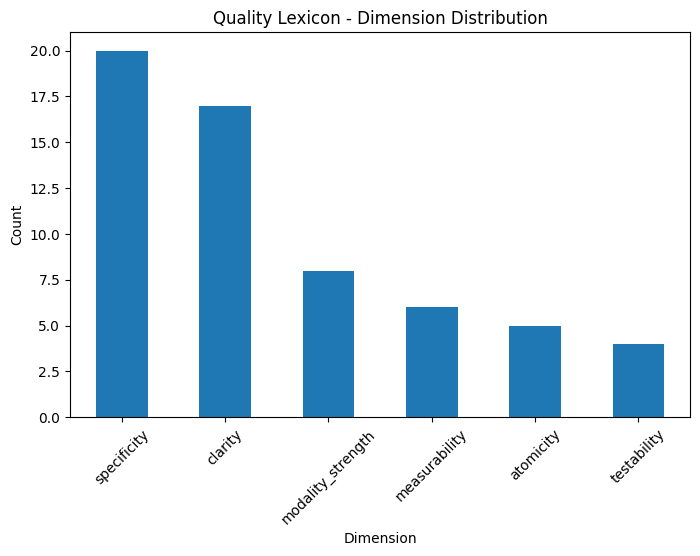

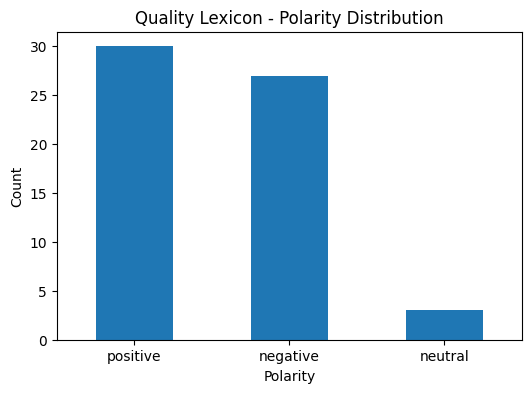

In [127]:
# =========================================
# STEP B1.4 - Visualize quality lexicon dataset
# =========================================

plt.figure(figsize=(8,5))
df_quality_lexicon["dimension"].value_counts().plot(kind="bar")
plt.title("Quality Lexicon - Dimension Distribution")
plt.xlabel("Dimension")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,4))
df_quality_lexicon["polarity"].value_counts().plot(kind="bar")
plt.title("Quality Lexicon - Polarity Distribution")
plt.xlabel("Polarity")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [128]:
# =========================================
# STEP B1.5 - Rebuild resources from quality dataset
# =========================================

def get_terms(dimension=None, polarity=None, term_type=None):
    df = df_quality_lexicon.copy()
    if dimension is not None:
        df = df[df["dimension"] == dimension]
    if polarity is not None:
        df = df[df["polarity"] == polarity]
    if term_type is not None:
        df = df[df["term_type"] == term_type]
    return df["term"].tolist()

vague_terms = set(get_terms(dimension="clarity", polarity="negative"))
weak_modalities = set(get_terms(dimension="modality_strength", polarity="negative"))
strong_modalities = set(get_terms(dimension="modality_strength", polarity="positive"))
testability_terms = set(get_terms(dimension="testability", polarity="positive") + get_terms(dimension="measurability", polarity="positive"))
atomic_splitters = set(get_terms(dimension="atomicity", polarity="negative"))
action_verbs = set(get_terms(dimension="specificity", term_type="verb"))

print("vague_terms:", len(vague_terms))
print("weak_modalities:", len(weak_modalities))
print("strong_modalities:", len(strong_modalities))
print("testability_terms:", len(testability_terms))
print("atomic_splitters:", len(atomic_splitters))
print("action_verbs:", len(action_verbs))

vague_terms: 17
weak_modalities: 5
strong_modalities: 3
testability_terms: 10
atomic_splitters: 5
action_verbs: 18


In [129]:
# =========================================
# STEP B1.6 - Helper functions from quality dataset
# =========================================

import re

def get_quality_terms(dimension=None, polarity=None, term_type=None):
    df = df_quality_lexicon.copy()
    if dimension is not None:
        df = df[df["dimension"] == dimension]
    if polarity is not None:
        df = df[df["polarity"] == polarity]
    if term_type is not None:
        df = df[df["term_type"] == term_type]
    return df["term"].tolist()

def match_quality_terms(text, dimension=None, polarity=None, term_type=None):
    text_lower = str(text).lower()
    terms = get_quality_terms(dimension=dimension, polarity=polarity, term_type=term_type)
    matched = [term for term in terms if term.lower() in text_lower]
    return matched

def contains_number(text):
    return bool(re.search(r"\d", str(text)))

def detect_modality(text):
    strong_found = match_quality_terms(text, dimension="modality_strength", polarity="positive")
    weak_found = match_quality_terms(text, dimension="modality_strength", polarity="negative")
    return strong_found, weak_found

def detect_vagueness(text):
    return match_quality_terms(text, dimension="clarity", polarity="negative")

def detect_atomicity_issue(text):
    return match_quality_terms(text, dimension="atomicity", polarity="negative")

def detect_action_verbs(text):
    return match_quality_terms(text, dimension="specificity", term_type="verb")

def detect_measurability_terms(text):
    matched_meas = match_quality_terms(text, dimension="measurability", polarity="positive")
    matched_test = match_quality_terms(text, dimension="testability", polarity="positive")
    return list(set(matched_meas + matched_test))

In [130]:
# =========================================
# STEP B1.7 - Dimension scoring functions
# =========================================

def compute_clarity_score(text):
    vague_hits = detect_vagueness(text)
    if len(vague_hits) == 0:
        return 1.0
    elif len(vague_hits) == 1:
        return 0.7
    elif len(vague_hits) == 2:
        return 0.5
    else:
        return 0.3

def compute_specificity_score(text):
    score = 0.4
    action_hits = detect_action_verbs(text)

    if len(action_hits) > 0:
        score += 0.3
    if contains_number(text):
        score += 0.2
    if len(str(text).split()) >= 8:
        score += 0.1

    return min(score, 1.0)

def compute_measurability_score(text):
    meas_hits = detect_measurability_terms(text)
    if contains_number(text) and len(meas_hits) > 0:
        return 1.0
    elif contains_number(text):
        return 0.8
    elif len(meas_hits) > 0:
        return 0.7
    else:
        return 0.4

def compute_testability_score(text):
    text_lower = str(text).lower()
    meas_hits = detect_measurability_terms(text)

    if len(meas_hits) > 0 and contains_number(text):
        return 1.0
    elif "if" in text_lower or "when" in text_lower:
        return 0.7
    elif len(meas_hits) > 0:
        return 0.7
    else:
        return 0.5

def compute_atomicity_score(text):
    atomic_hits = detect_atomicity_issue(text)
    if len(atomic_hits) == 0:
        return 1.0
    elif len(atomic_hits) == 1:
        return 0.6
    else:
        return 0.3

def compute_modality_strength_score(text):
    strong_found, weak_found = detect_modality(text)

    if len(strong_found) > 0:
        return 1.0
    elif len(weak_found) > 0:
        return 0.4
    else:
        return 0.7

In [131]:
# =========================================
# STEP B1.8 - Main quality scoring function
# =========================================

def score_requirement_quality_dataset_based(text):
    text = str(text)

    clarity = compute_clarity_score(text)
    specificity = compute_specificity_score(text)
    measurability = compute_measurability_score(text)
    testability = compute_testability_score(text)
    atomicity = compute_atomicity_score(text)
    modality_strength = compute_modality_strength_score(text)

    overall_score = round(
        (clarity + specificity + measurability + testability + atomicity + modality_strength) / 6,
        3
    )

    issues = []
    if clarity < 0.8:
        issues.append("vague_wording")
    if measurability < 0.8:
        issues.append("not_measurable")
    if testability < 0.8:
        issues.append("weak_testability")
    if atomicity < 0.8:
        issues.append("possibly_non_atomic")
    if modality_strength < 0.8:
        issues.append("weak_modality")

    recommended_actions = []
    if "vague_wording" in issues:
        recommended_actions.append("replace_vague_terms")
    if "not_measurable" in issues:
        recommended_actions.append("add_measurable_criteria")
    if "weak_testability" in issues:
        recommended_actions.append("add_test_conditions")
    if "possibly_non_atomic" in issues:
        recommended_actions.append("split_into_atomic_requirements")
    if "weak_modality" in issues:
        recommended_actions.append("strengthen_modality")

    return {
        "text": text,
        "overall_score": overall_score,
        "issues": issues,
        "recommended_actions": recommended_actions,
        "scores": {
            "clarity": clarity,
            "specificity": specificity,
            "measurability": measurability,
            "testability": testability,
            "atomicity": atomicity,
            "modality_strength": modality_strength
        },
        "matched_quality_terms": {
            "vague_terms": detect_vagueness(text),
            "action_verbs": detect_action_verbs(text),
            "measurability_terms": detect_measurability_terms(text),
            "atomicity_terms": detect_atomicity_issue(text),
            "strong_modalities": detect_modality(text)[0],
            "weak_modalities": detect_modality(text)[1]
        }
    }

In [132]:
# =========================================
# STEP B1.9 - Manual testing
# =========================================

quality_examples = [
    "The system should be fast.",
    "The interface shall be easy to use.",
    "The system shall respond within 2 seconds under normal operating conditions.",
    "The application may process some requests later.",
    "The system shall validate input and save data and notify administrators.",
    "The system shall encrypt all passwords using AES-256 before storage."
]

quality_results = [score_requirement_quality_dataset_based(req) for req in quality_examples]

for result in quality_results:
    print("=" * 100)
    print("Requirement:", result["text"])
    print("Overall score:", result["overall_score"])
    print("Issues:", result["issues"])
    print("Recommended actions:", result["recommended_actions"])
    print("Scores:", result["scores"])
    print("Matched quality terms:", result["matched_quality_terms"])

Requirement: The system should be fast.
Overall score: 0.567
Issues: ['vague_wording', 'not_measurable', 'weak_testability', 'weak_modality']
Recommended actions: ['replace_vague_terms', 'add_measurable_criteria', 'add_test_conditions', 'strengthen_modality']
Scores: {'clarity': 0.7, 'specificity': 0.4, 'measurability': 0.4, 'testability': 0.5, 'atomicity': 1.0, 'modality_strength': 0.4}
Matched quality terms: {'vague_terms': ['fast'], 'action_verbs': [], 'measurability_terms': [], 'atomicity_terms': [], 'strong_modalities': [], 'weak_modalities': ['should']}
Requirement: The interface shall be easy to use.
Overall score: 0.633
Issues: ['vague_wording', 'not_measurable', 'weak_testability']
Recommended actions: ['replace_vague_terms', 'add_measurable_criteria', 'add_test_conditions']
Scores: {'clarity': 0.5, 'specificity': 0.4, 'measurability': 0.4, 'testability': 0.5, 'atomicity': 1.0, 'modality_strength': 1.0}
Matched quality terms: {'vague_terms': ['easy', 'easy to use'], 'action_ve

In [133]:
# =========================================
# STEP B1.10 - Build quality results table
# =========================================

quality_df = pd.DataFrame([
    {
        "requirement": r["text"],
        "overall_score": r["overall_score"],
        "issues": ", ".join(r["issues"]),
        "recommended_actions": ", ".join(r["recommended_actions"]),
        "vague_terms": ", ".join(r["matched_quality_terms"]["vague_terms"]),
        "action_verbs": ", ".join(r["matched_quality_terms"]["action_verbs"]),
        "measurability_terms": ", ".join(r["matched_quality_terms"]["measurability_terms"]),
        "atomicity_terms": ", ".join(r["matched_quality_terms"]["atomicity_terms"]),
        "strong_modalities": ", ".join(r["matched_quality_terms"]["strong_modalities"]),
        "weak_modalities": ", ".join(r["matched_quality_terms"]["weak_modalities"]),
        **r["scores"]
    }
    for r in quality_results
])

display(quality_df)

,requirement,overall_score,issues,recommended_actions,vague_terms,action_verbs,measurability_terms,atomicity_terms,strong_modalities,weak_modalities,clarity,specificity,measurability,testability,atomicity,modality_strength
0,The system should be fast.,0.567,"vague_wording, not_measurable, weak_testabilit...","replace_vague_terms, add_measurable_criteria, ...",fast,,,,,should,0.7,0.4,0.4,0.5,1.0,0.4
1,The interface shall be easy to use.,0.633,"vague_wording, not_measurable, weak_testability","replace_vague_terms, add_measurable_criteria, ...","easy, easy to use",,,,shall,,0.5,0.4,0.4,0.5,1.0,1.0
2,The system shall respond within 2 seconds unde...,0.950,,,,,"within, seconds",,shall,,1.0,0.7,1.0,1.0,1.0,1.0
3,The application may process some requests later.,0.617,"vague_wording, not_measurable, weak_testabilit...","replace_vague_terms, add_measurable_criteria, ...",later,process,,,,may,0.7,0.7,0.4,0.5,1.0,0.4
4,The system shall validate input and save data ...,0.750,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ...",,"save, validate, notify",,and,shall,,1.0,0.8,0.4,0.7,0.6,1.0
5,The system shall encrypt all passwords using A...,0.883,weak_testability,add_test_conditions,,encrypt,,,shall,,1.0,1.0,0.8,0.5,1.0,1.0


In [134]:
# =========================================
# STEP B1.11 - Apply on notebook sample
# =========================================

sample_quality_df = df_requirements[["text", "label", "sub_label"]].sample(20, random_state=42).copy()
sample_quality_df["quality_result"] = sample_quality_df["text"].apply(score_requirement_quality_dataset_based)

sample_quality_df["quality_score"] = sample_quality_df["quality_result"].apply(lambda x: x["overall_score"])
sample_quality_df["issues_detected"] = sample_quality_df["quality_result"].apply(lambda x: ", ".join(x["issues"]))
sample_quality_df["recommended_actions"] = sample_quality_df["quality_result"].apply(lambda x: ", ".join(x["recommended_actions"]))

display(
    sample_quality_df[
        ["text", "label", "sub_label", "quality_score", "issues_detected", "recommended_actions"]
    ]
)

,text,label,sub_label,quality_score,issues_detected,recommended_actions
22482,3.2.36.4 Alternate Flows.,FR,functional,0.767,"weak_testability, weak_modality","add_test_conditions, strengthen_modality"
4463,Data and event logging,FR,functional,0.600,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
21362,A covered entity must document the following a...,FR,functional,0.767,"weak_testability, possibly_non_atomic","add_test_conditions, split_into_atomic_require..."
10657,System shall ensure portability by enabling ac...,NFR,general,0.733,"not_measurable, weak_testability","add_measurable_criteria, add_test_conditions"
3880,MARC bibliographic and authority records can b...,FR,functional,0.617,"weak_testability, possibly_non_atomic, weak_mo...","add_test_conditions, split_into_atomic_require..."
23266,The system has an unmerge process.,FR,functional,0.717,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."
9795,The BE shall store input data records in a mem...,FR,general,0.717,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
12473,"Upon selecting Home, system shall display vide...",FR,general,0.717,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
22704,The LHCP can view of the comprehensive patient...,NFR,security,0.667,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."
4383,Upload File,FR,functional,0.717,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."


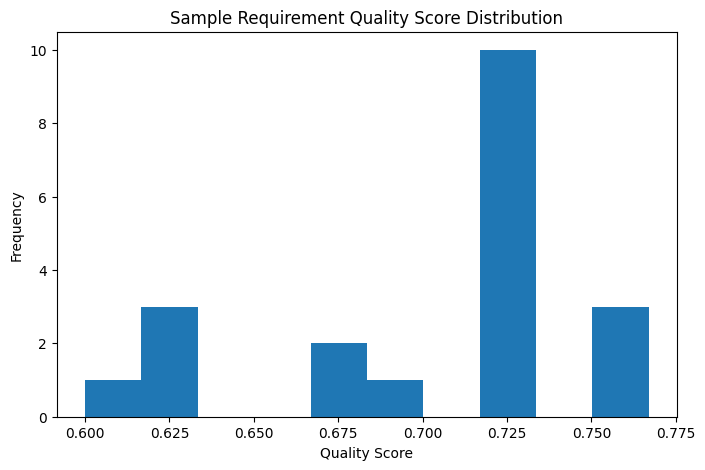

In [135]:
# =========================================
# STEP B1.12 - Quality score distribution
# =========================================

plt.figure(figsize=(8,5))
plt.hist(sample_quality_df["quality_score"], bins=10)
plt.title("Sample Requirement Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")
plt.show()

In [136]:
# =========================================
# STEP B1.13 - Reusable quality analysis function
# =========================================

def analyze_requirement_quality(text):
    quality = score_requirement_quality_dataset_based(text)
    return {
        "text": text,
        "overall_score": quality["overall_score"],
        "issues": quality["issues"],
        "recommended_actions": quality["recommended_actions"],
        "dimension_scores": quality["scores"],
        "matched_quality_terms": quality["matched_quality_terms"]
    }

analyze_requirement_quality("The system should be fast and easy to use.")

{'text': 'The system should be fast and easy to use.',
 'overall_score': 0.45,
 'issues': ['vague_wording',
  'not_measurable',
  'weak_testability',
  'possibly_non_atomic',
  'weak_modality'],
 'recommended_actions': ['replace_vague_terms',
  'add_measurable_criteria',
  'add_test_conditions',
  'split_into_atomic_requirements',
  'strengthen_modality'],
 'dimension_scores': {'clarity': 0.3,
  'specificity': 0.5,
  'measurability': 0.4,
  'testability': 0.5,
  'atomicity': 0.6,
  'modality_strength': 0.4},
 'matched_quality_terms': {'vague_terms': ['fast', 'easy', 'easy to use'],
  'action_verbs': [],
  'measurability_terms': [],
  'atomicity_terms': [' and '],
  'strong_modalities': [],
  'weak_modalities': ['should']}}

# =========================================
# MODULE A3.2 — SYNTHETIC AMBIGUITY SENTENCE DATASET
# =========================================

In [137]:
# =========================================
# STEP A3.2.1 - Define template components
# =========================================

subjects = [
    "The system",
    "The application",
    "The platform",
    "The software",
    "The interface",
    "The product"
]

actions = [
    "respond",
    "process requests",
    "display results",
    "save records",
    "notify users",
    "authenticate users",
    "load the dashboard",
    "generate reports",
    "update data",
    "validate input"
]

objects = [
    "user requests",
    "uploaded files",
    "transaction records",
    "system notifications",
    "search results",
    "user accounts",
    "security events",
    "application data"
]

conditions = [
    "under normal operating conditions",
    "during peak usage",
    "after login",
    "after a valid request",
    "when the user submits a form",
    "during standard business hours"
]

time_values = [
    "1 second",
    "2 seconds",
    "3 seconds",
    "5 seconds",
    "10 seconds",
    "1 minute"
]

quantity_values = [
    "100 users",
    "500 users",
    "1,000 users",
    "10,000 users",
    "100,000 users"
]

In [138]:
# =========================================
# STEP A3.2.2 - Build ambiguous generators
# =========================================

import random

random.seed(42)

def make_ambiguous_time_sentence():
    subject = random.choice(subjects)
    action = random.choice(actions)
    vague_time = random.choice(["quickly", "soon", "later", "swiftly", "in due time"])
    return f"{subject} should {action} {vague_time}."

def make_ambiguous_quantity_sentence():
    subject = random.choice(subjects)
    action = random.choice(actions)
    vague_quantity = random.choice(["many", "some", "few", "various", "several"])
    obj = random.choice(objects)
    return f"{subject} shall {action} {vague_quantity} {obj}."

def make_ambiguous_quality_sentence():
    subject = random.choice(subjects)
    vague_quality = random.choice(["fast", "efficient", "user-friendly", "reliable", "flexible", "robust"])
    return f"{subject} should be {vague_quality}."

def make_ambiguous_reference_sentence():
    subject = random.choice(subjects)
    action = random.choice(actions)
    ref = random.choice(["this", "these", "the above", "the aforementioned"])
    return f"{subject} shall {action} according to {ref}."

def make_ambiguous_variable_sentence():
    subject = random.choice(subjects)
    action = random.choice(["process", "update", "verify", "determine", "modify"])
    vague_var = random.choice(["data", "value", "status", "rule"])
    return f"{subject} shall {action} the {vague_var}."

In [139]:
# =========================================
# STEP A3.2.3 - Build clear generators
# =========================================

def make_clear_time_sentence():
    subject = random.choice(subjects)
    action = random.choice(actions)
    t = random.choice(time_values)
    condition = random.choice(conditions)
    return f"{subject} shall {action} within {t} {condition}."

def make_clear_quantity_sentence():
    subject = random.choice(subjects)
    action = random.choice(actions)
    q = random.choice(quantity_values)
    obj = random.choice(objects)
    return f"{subject} shall {action} for up to {q}."

def make_clear_security_sentence():
    subject = random.choice(subjects)
    return f"{subject} shall encrypt all passwords using AES-256 before storage."

def make_clear_validation_sentence():
    subject = random.choice(subjects)
    return f"{subject} shall validate all mandatory input fields before form submission."

def make_clear_availability_sentence():
    subject = random.choice(subjects)
    return f"{subject} shall remain available 99.9% of the time during standard business hours."

In [140]:
# =========================================
# STEP A3.2.4 - Generate synthetic dataset
# =========================================

synthetic_rows = []

# ambiguous
for _ in range(100):
    synthetic_rows.append({
        "text": make_ambiguous_time_sentence(),
        "label": 1,
        "label_name": "ambiguous",
        "ambiguity_category": "time_ambiguity",
        "source": "synthetic"
    })

for _ in range(100):
    synthetic_rows.append({
        "text": make_ambiguous_quantity_sentence(),
        "label": 1,
        "label_name": "ambiguous",
        "ambiguity_category": "quantitative_adjectives",
        "source": "synthetic"
    })

for _ in range(100):
    synthetic_rows.append({
        "text": make_ambiguous_quality_sentence(),
        "label": 1,
        "label_name": "ambiguous",
        "ambiguity_category": "vague_quality",
        "source": "synthetic"
    })

for _ in range(100):
    synthetic_rows.append({
        "text": make_ambiguous_reference_sentence(),
        "label": 1,
        "label_name": "ambiguous",
        "ambiguity_category": "implicit_references",
        "source": "synthetic"
    })

for _ in range(100):
    synthetic_rows.append({
        "text": make_ambiguous_variable_sentence(),
        "label": 1,
        "label_name": "ambiguous",
        "ambiguity_category": "ambiguous_variables",
        "source": "synthetic"
    })

# clear
for _ in range(120):
    synthetic_rows.append({
        "text": make_clear_time_sentence(),
        "label": 0,
        "label_name": "clear",
        "ambiguity_category": "clear",
        "source": "synthetic"
    })

for _ in range(120):
    synthetic_rows.append({
        "text": make_clear_quantity_sentence(),
        "label": 0,
        "label_name": "clear",
        "ambiguity_category": "clear",
        "source": "synthetic"
    })

for _ in range(120):
    synthetic_rows.append({
        "text": make_clear_security_sentence(),
        "label": 0,
        "label_name": "clear",
        "ambiguity_category": "clear",
        "source": "synthetic"
    })

for _ in range(120):
    synthetic_rows.append({
        "text": make_clear_validation_sentence(),
        "label": 0,
        "label_name": "clear",
        "ambiguity_category": "clear",
        "source": "synthetic"
    })

for _ in range(120):
    synthetic_rows.append({
        "text": make_clear_availability_sentence(),
        "label": 0,
        "label_name": "clear",
        "ambiguity_category": "clear",
        "source": "synthetic"
    })

df_ambiguity_synth = pd.DataFrame(synthetic_rows)

print("Synthetic ambiguity dataset shape:", df_ambiguity_synth.shape)
print(df_ambiguity_synth["label_name"].value_counts())
display(df_ambiguity_synth.sample(10, random_state=42))

Synthetic ambiguity dataset shape: (1100, 5)
label_name
clear        600
ambiguous    500
Name: count, dtype: int64


,text,label,label_name,ambiguity_category,source
328,The interface shall authenticate users accordi...,1,ambiguous,implicit_references,synthetic
688,The interface shall authenticate users for up ...,0,clear,clear,synthetic
413,The interface shall update the rule.,1,ambiguous,ambiguous_variables,synthetic
788,The application shall encrypt all passwords us...,0,clear,clear,synthetic
244,The platform should be user-friendly.,1,ambiguous,vague_quality,synthetic
759,The software shall encrypt all passwords using...,0,clear,clear,synthetic
96,The product should update data swiftly.,1,ambiguous,time_ambiguity,synthetic
605,The product shall respond within 1 second duri...,0,clear,clear,synthetic
734,"The product shall save records for up to 100,0...",0,clear,clear,synthetic
101,The interface shall generate reports several t...,1,ambiguous,quantitative_adjectives,synthetic


In [141]:
# =========================================
# STEP A3.2.5 - Deduplicate synthetic data
# =========================================

df_ambiguity_synth["text_dedup"] = (
    df_ambiguity_synth["text"]
    .str.lower()
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

before = len(df_ambiguity_synth)
df_ambiguity_synth = df_ambiguity_synth.drop_duplicates(subset=["text_dedup"]).copy()
after = len(df_ambiguity_synth)

print("Before dedup:", before)
print("After dedup :", after)
print("Removed     :", before - after)

Before dedup: 1100
After dedup : 606
Removed     : 494


In [142]:
# =========================================
# STEP A3.2.6 - Save synthetic ambiguity dataset
# =========================================

df_ambiguity_synth.to_csv("/kaggle/working/ambiguity_synthetic_dataset.csv", index=False)
print("Saved: /kaggle/working/ambiguity_synthetic_dataset.csv")

Saved: /kaggle/working/ambiguity_synthetic_dataset.csv


ambiguity_category
clear                      237
quantitative_adjectives     96
time_ambiguity              88
implicit_references         84
ambiguous_variables         66
vague_quality               35
Name: count, dtype: int64


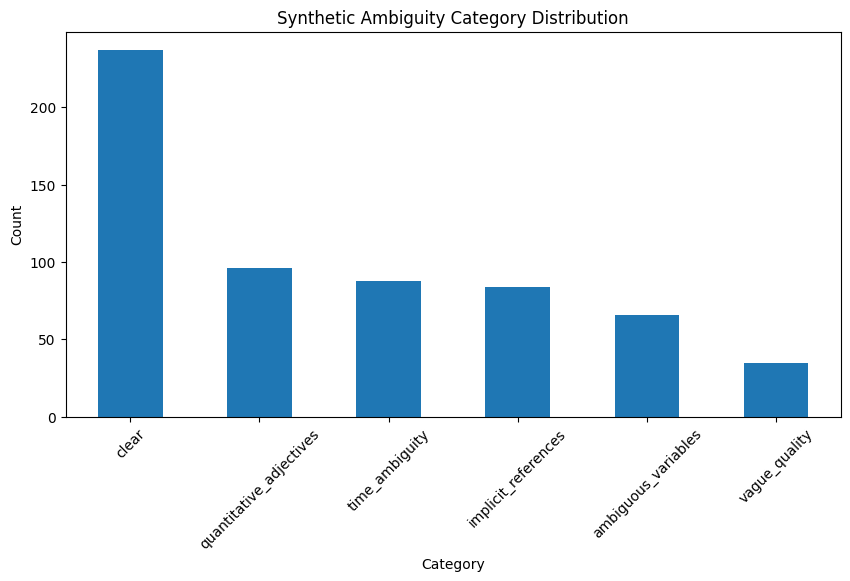

In [143]:
# =========================================
# STEP A3.2.7 - Visualize synthetic dataset
# =========================================

print(df_ambiguity_synth["ambiguity_category"].value_counts())

plt.figure(figsize=(10, 5))
df_ambiguity_synth["ambiguity_category"].value_counts().plot(kind="bar")
plt.title("Synthetic Ambiguity Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# =========================================
# MODULE A3.3 — MERGE REAL + SYNTHETIC AMBIGUITY DATA
# =========================================

In [144]:
# =========================================
# STEP A3.3.1 - Prepare real ambiguity dataset
# =========================================

df_ambiguity_real = df_requirements[["text", "ambiguity_score", "is_ambiguous_rule"]].copy()

df_ambiguity_real["label"] = df_ambiguity_real["is_ambiguous_rule"]
df_ambiguity_real["label_name"] = df_ambiguity_real["label"].map({0: "clear", 1: "ambiguous"})
df_ambiguity_real["ambiguity_category"] = "rule_derived"
df_ambiguity_real["source"] = "real_rule_based"

df_ambiguity_real = df_ambiguity_real[["text", "label", "label_name", "ambiguity_category", "source"]].copy()

print("Real ambiguity dataset shape:", df_ambiguity_real.shape)
print(df_ambiguity_real["label_name"].value_counts())
display(df_ambiguity_real.head())

Real ambiguity dataset shape: (24443, 5)
label_name
ambiguous    18069
clear         6374
Name: count, dtype: int64


,text,label,label_name,ambiguity_category,source
0,The system shall refresh the display every 60 ...,1,ambiguous,rule_derived,real_rule_based
1,The application shall match the color of the s...,1,ambiguous,rule_derived,real_rule_based
2,If projected the data must be readable. On a 1...,1,ambiguous,rule_derived,real_rule_based
3,The product shall be available during normal b...,1,ambiguous,rule_derived,real_rule_based
4,If projected the data must be understandable. ...,1,ambiguous,rule_derived,real_rule_based


In [145]:
# =========================================
# STEP A3.3.2 - Align synthetic ambiguity dataset
# =========================================

df_ambiguity_synth_aligned = df_ambiguity_synth[["text", "label", "label_name", "ambiguity_category", "source"]].copy()

print("Synthetic ambiguity dataset shape:", df_ambiguity_synth_aligned.shape)
print(df_ambiguity_synth_aligned["label_name"].value_counts())
display(df_ambiguity_synth_aligned.head())

Synthetic ambiguity dataset shape: (606, 5)
label_name
ambiguous    369
clear        237
Name: count, dtype: int64


,text,label,label_name,ambiguity_category,source
0,The product should process requests quickly.,1,ambiguous,time_ambiguity,synthetic
1,The product should notify users soon.,1,ambiguous,time_ambiguity,synthetic
2,The application should display results quickly.,1,ambiguous,time_ambiguity,synthetic
3,The product should update data quickly.,1,ambiguous,time_ambiguity,synthetic
4,The interface should load the dashboard quickly.,1,ambiguous,time_ambiguity,synthetic


In [146]:
# =========================================
# STEP A3.3.3 - Merge real + synthetic datasets
# =========================================

df_ambiguity_merged = pd.concat(
    [df_ambiguity_real, df_ambiguity_synth_aligned],
    ignore_index=True
)

df_ambiguity_merged["text_dedup"] = (
    df_ambiguity_merged["text"]
    .str.lower()
    .str.replace(r"[^\w\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

before_merge_dedup = len(df_ambiguity_merged)
df_ambiguity_merged = df_ambiguity_merged.drop_duplicates(subset=["text_dedup"]).copy()
after_merge_dedup = len(df_ambiguity_merged)

print("Merged ambiguity dataset shape:", df_ambiguity_merged.shape)
print("Before dedup:", before_merge_dedup)
print("After dedup :", after_merge_dedup)
print("Removed     :", before_merge_dedup - after_merge_dedup)

print("\nLabel distribution:")
print(df_ambiguity_merged["label_name"].value_counts())

print("\nSource distribution:")
print(df_ambiguity_merged["source"].value_counts())

display(df_ambiguity_merged.sample(10, random_state=42))

Merged ambiguity dataset shape: (25049, 6)
Before dedup: 25049
After dedup : 25049
Removed     : 0

Label distribution:
label_name
ambiguous    18438
clear         6611
Name: count, dtype: int64

Source distribution:
source
real_rule_based    24443
synthetic            606
Name: count, dtype: int64


,text,label,label_name,ambiguity_category,source,text_dedup
12114,The system shall have a user-friendly interfac...,1,ambiguous,rule_derived,real_rule_based,the system shall have a user friendly interfac...
4903,ELG Platform development must follow applicati...,0,clear,rule_derived,real_rule_based,elg platform development must follow applicati...
18641,A health plan must meet each of the following ...,1,ambiguous,rule_derived,real_rule_based,a health plan must meet each of the following ...
19035,(c) Standard: Workstation security.,0,clear,rule_derived,real_rule_based,c standard workstation security
19731,A limited data set is protected health informa...,1,ambiguous,rule_derived,real_rule_based,a limited data set is protected health informa...
2055,"All reservations, loans and returns shall be r...",1,ambiguous,rule_derived,real_rule_based,all reservations loans and returns shall be re...
21741,The system has the ability to trend vital sign...,0,clear,rule_derived,real_rule_based,the system has the ability to trend vital sign...
24222,The website shall appear to be fun and the col...,1,ambiguous,rule_derived,real_rule_based,the website shall appear to be fun and the col...
12451,System shall offer quick access to training op...,1,ambiguous,rule_derived,real_rule_based,system shall offer quick access to training op...
11946,An API User shall be able to persistently stor...,1,ambiguous,rule_derived,real_rule_based,an api user shall be able to persistently stor...


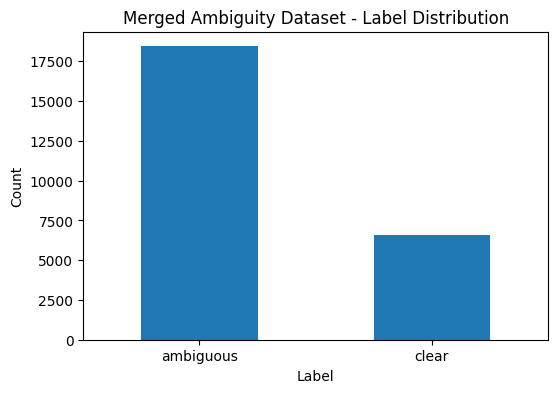

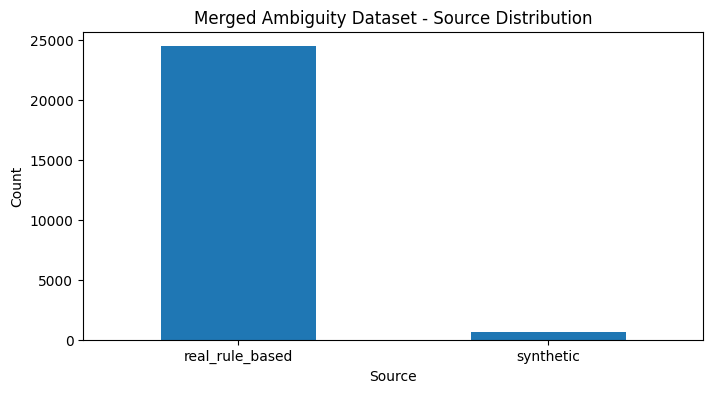

In [147]:
# =========================================
# STEP A3.3.4 - Visualize merged ambiguity dataset
# =========================================

plt.figure(figsize=(6,4))
df_ambiguity_merged["label_name"].value_counts().plot(kind="bar")
plt.title("Merged Ambiguity Dataset - Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(8,4))
df_ambiguity_merged["source"].value_counts().plot(kind="bar")
plt.title("Merged Ambiguity Dataset - Source Distribution")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# =========================================
# MODULE A3.4 — IMPROVED AMBIGUITY CLASSIFIER
# =========================================

In [148]:
# =========================================
# STEP A3.4.1 - Train / Test Split
# =========================================

from sklearn.model_selection import train_test_split

train_amb2, test_amb2 = train_test_split(
    df_ambiguity_merged,
    test_size=0.2,
    stratify=df_ambiguity_merged["label"],
    random_state=42
)

print("Train shape:", train_amb2.shape)
print("Test shape :", test_amb2.shape)

print("\nTrain distribution:")
print(train_amb2["label_name"].value_counts())

print("\nTest distribution:")
print(test_amb2["label_name"].value_counts())

Train shape: (20039, 6)
Test shape : (5010, 6)

Train distribution:
label_name
ambiguous    14750
clear         5289
Name: count, dtype: int64

Test distribution:
label_name
ambiguous    3688
clear        1322
Name: count, dtype: int64


In [149]:
# =========================================
# STEP A3.4.2 - TF-IDF Vectorization
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_amb2 = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),
    lowercase=True
)

X_train_amb2 = vectorizer_amb2.fit_transform(train_amb2["text"])
X_test_amb2 = vectorizer_amb2.transform(test_amb2["text"])

y_train_amb2 = train_amb2["label"]
y_test_amb2 = test_amb2["label"]

print("X_train shape:", X_train_amb2.shape)
print("X_test shape :", X_test_amb2.shape)

X_train shape: (20039, 8000)
X_test shape : (5010, 8000)


In [150]:
# =========================================
# STEP A3.4.3 - Train Logistic Regression
# =========================================

from sklearn.linear_model import LogisticRegression

model_amb2 = LogisticRegression(
    max_iter=300,
    class_weight="balanced",
    random_state=42
)

model_amb2.fit(X_train_amb2, y_train_amb2)

print("Improved ambiguity model trained successfully.")

Improved ambiguity model trained successfully.


In [151]:
# =========================================
# STEP A3.4.4 - Evaluation
# =========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_amb2 = model_amb2.predict(X_test_amb2)

amb2_accuracy = accuracy_score(y_test_amb2, y_pred_amb2)

print("Improved Ambiguity Accuracy:", amb2_accuracy)
print("\nClassification Report:")
print(classification_report(
    y_test_amb2,
    y_pred_amb2,
    target_names=["clear", "ambiguous"]
))

Improved Ambiguity Accuracy: 0.9395209580838323

Classification Report:
              precision    recall  f1-score   support

       clear       0.82      0.99      0.90      1322
   ambiguous       1.00      0.92      0.96      3688

    accuracy                           0.94      5010
   macro avg       0.91      0.95      0.93      5010
weighted avg       0.95      0.94      0.94      5010



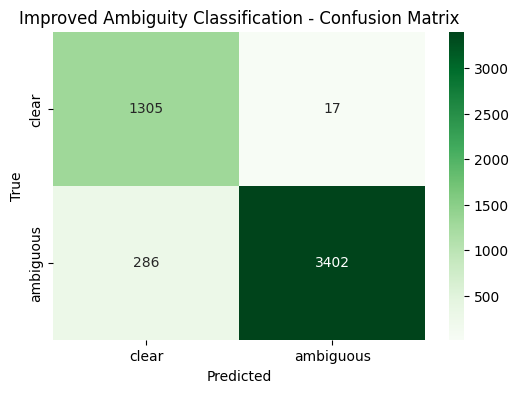

In [152]:
# =========================================
# STEP A3.4.5 - Confusion Matrix
# =========================================

import seaborn as sns
import matplotlib.pyplot as plt

cm_amb2 = confusion_matrix(y_test_amb2, y_pred_amb2)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_amb2,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["clear", "ambiguous"],
    yticklabels=["clear", "ambiguous"]
)
plt.title("Improved Ambiguity Classification - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [153]:
# =========================================
# STEP A3.4.6 - Reusable ambiguity predictor
# =========================================

def predict_ambiguity_ml(text):
    X_input = vectorizer_amb2.transform([text])
    pred = model_amb2.predict(X_input)[0]
    probs = model_amb2.predict_proba(X_input)[0]

    return {
        "text": text,
        "predicted_label": "ambiguous" if pred == 1 else "clear",
        "probabilities": {
            "clear": float(probs[0]),
            "ambiguous": float(probs[1])
        }
    }

predict_ambiguity_ml("The system should respond quickly and efficiently.")

{'text': 'The system should respond quickly and efficiently.',
 'predicted_label': 'ambiguous',
 'probabilities': {'clear': 0.39355114613623854,
  'ambiguous': 0.6064488538637615}}

# =========================================
# MODULE A3.5 — FINAL HYBRID AMBIGUITY ANALYZER
# =========================================

In [154]:
# =========================================
# STEP A3.5.1 - Rule-based ambiguity detector
# =========================================

def detect_ambiguity_matches(text, lexicon_df):
    text_lower = str(text).lower()
    
    matches = lexicon_df[
        lexicon_df["term"].str.lower().apply(lambda term: term in text_lower)
    ].copy()
    
    return matches

def analyze_ambiguity_rule(text, lexicon_df):
    matches = detect_ambiguity_matches(text, lexicon_df)
    
    if matches.empty:
        return {
            "rule_label": "clear",
            "rule_score": 0,
            "matched_terms": [],
            "matched_categories": ["clear"]
        }
    
    matched_terms = matches["term"].tolist()
    matched_categories = matches["category"].unique().tolist()
    weighted_score = int(matches["severity"].sum())
    
    return {
        "rule_label": "ambiguous",
        "rule_score": weighted_score,
        "matched_terms": matched_terms,
        "matched_categories": matched_categories
    }

analyze_ambiguity_rule(
    "The system should respond quickly and efficiently.",
    df_ambiguity_lexicon
)

{'rule_label': 'clear',
 'rule_score': 0,
 'matched_terms': [],
 'matched_categories': ['clear']}

In [155]:
# =========================================
# STEP A3.5.2 - ML ambiguity detector
# =========================================

def analyze_ambiguity_ml(text):
    X_input = vectorizer_amb2.transform([text])
    pred = model_amb2.predict(X_input)[0]
    probs = model_amb2.predict_proba(X_input)[0]
    
    return {
        "ml_label": "ambiguous" if pred == 1 else "clear",
        "ml_prob_clear": float(probs[0]),
        "ml_prob_ambiguous": float(probs[1])
    }

analyze_ambiguity_ml("The system should respond quickly and efficiently.")

{'ml_label': 'ambiguous',
 'ml_prob_clear': 0.39355114613623854,
 'ml_prob_ambiguous': 0.6064488538637615}

In [156]:
# =========================================
# STEP A3.5.3 - Hybrid ambiguity fusion
# =========================================

def fuse_ambiguity_decision(rule_result, ml_result):
    rule_label = rule_result["rule_label"]
    ml_label = ml_result["ml_label"]
    ml_conf = ml_result["ml_prob_ambiguous"]
    
    # Case 1: both agree on ambiguous
    if rule_label == "ambiguous" and ml_label == "ambiguous":
        final_label = "ambiguous"
        confidence = "high"
        reason = "Both rule-based and ML detectors identified ambiguity."
    
    # Case 2: rule says ambiguous, ML says clear
    elif rule_label == "ambiguous" and ml_label == "clear":
        final_label = "ambiguous"
        confidence = "medium"
        reason = "Ambiguity lexicon detected explicit vague terms, even though ML predicted clear."
    
    # Case 3: rule says clear, ML says ambiguous
    elif rule_label == "clear" and ml_label == "ambiguous":
        final_label = "ambiguous"
        confidence = "medium"
        reason = "ML detected semantic ambiguity not explicitly covered by the lexicon."
    
    # Case 4: both agree on clear
    else:
        final_label = "clear"
        confidence = "high"
        reason = "Both rule-based and ML detectors identified the requirement as clear."
    
    return {
        "final_ambiguity": final_label,
        "confidence": confidence,
        "fusion_reason": reason
    }

In [157]:
# =========================================
# STEP A3.5.4 - Final hybrid requirement analyzer
# =========================================

def analyze_requirement_hybrid(text):
    # FR / NFR with DistilBERT
    type_result = predict_fr_nfr_distilbert(text)
    
    # Rule-based ambiguity
    rule_result = analyze_ambiguity_rule(text, df_ambiguity_lexicon)
    
    # ML ambiguity
    ml_result = analyze_ambiguity_ml(text)
    
    # Final fusion
    fusion_result = fuse_ambiguity_decision(rule_result, ml_result)
    
    return {
        "text": text,
        "requirement_type": type_result["predicted_label"],
        "type_probabilities": type_result["probabilities"],
        "rule_label": rule_result["rule_label"],
        "rule_score": rule_result["rule_score"],
        "matched_terms": rule_result["matched_terms"],
        "matched_categories": rule_result["matched_categories"],
        "ml_label": ml_result["ml_label"],
        "ml_prob_clear": ml_result["ml_prob_clear"],
        "ml_prob_ambiguous": ml_result["ml_prob_ambiguous"],
        "final_ambiguity": fusion_result["final_ambiguity"],
        "confidence": fusion_result["confidence"],
        "fusion_reason": fusion_result["fusion_reason"]
    }

analyze_requirement_hybrid("The system should respond quickly and efficiently.")

{'text': 'The system should respond quickly and efficiently.',
 'requirement_type': 'NFR',
 'type_probabilities': {'FR': 0.19425131380558014, 'NFR': 0.805748701095581},
 'rule_label': 'clear',
 'rule_score': 0,
 'matched_terms': [],
 'matched_categories': ['clear'],
 'ml_label': 'ambiguous',
 'ml_prob_clear': 0.39355114613623854,
 'ml_prob_ambiguous': 0.6064488538637615,
 'final_ambiguity': 'ambiguous',
 'confidence': 'medium',
 'fusion_reason': 'ML detected semantic ambiguity not explicitly covered by the lexicon.'}

In [158]:
# =========================================
# STEP A3.5.5 - Explain final decision
# =========================================

def explain_requirement_hybrid(text):
    result = analyze_requirement_hybrid(text)
    
    explanation = []
    
    explanation.append(f"Requirement type: {result['requirement_type']}")
    explanation.append(f"Final ambiguity decision: {result['final_ambiguity']} ({result['confidence']} confidence)")
    explanation.append(result["fusion_reason"])
    
    if result["matched_terms"]:
        explanation.append("Matched ambiguous terms: " + ", ".join(result["matched_terms"]))
    
    if result["matched_categories"]:
        explanation.append("Ambiguity categories: " + ", ".join(result["matched_categories"]))
    
    explanation.append(
        f"ML probabilities -> clear: {result['ml_prob_clear']:.3f}, ambiguous: {result['ml_prob_ambiguous']:.3f}"
    )
    
    explanation.append(
        f"FR/NFR probabilities -> FR: {result['type_probabilities']['FR']:.3f}, NFR: {result['type_probabilities']['NFR']:.3f}"
    )
    
    return explanation

for line in explain_requirement_hybrid("The system should respond quickly and efficiently."):
    print("-", line)

- Requirement type: NFR
- Final ambiguity decision: ambiguous (medium confidence)
- ML detected semantic ambiguity not explicitly covered by the lexicon.
- Ambiguity categories: clear
- ML probabilities -> clear: 0.394, ambiguous: 0.606
- FR/NFR probabilities -> FR: 0.194, NFR: 0.806


In [159]:
# =========================================
# STEP A3.5.6 - Test hybrid analyzer
# =========================================

test_requirements_hybrid = [
    "The system should respond quickly and efficiently.",
    "The system shall respond within 2 seconds under normal operating conditions.",
    "The interface should be user-friendly.",
    "The application shall support up to 10,000 concurrent users.",
    "The system shall encrypt all passwords using AES-256 before storage.",
    "The software may process some requests later."
]

for req in test_requirements_hybrid:
    print("=" * 100)
    print("INPUT:", req)
    result = analyze_requirement_hybrid(req)
    print("TYPE:", result["requirement_type"])
    print("FINAL AMBIGUITY:", result["final_ambiguity"])
    print("CONFIDENCE:", result["confidence"])
    print("MATCHED TERMS:", result["matched_terms"])
    print("MATCHED CATEGORIES:", result["matched_categories"])
    print("ML ambiguous probability:", round(result["ml_prob_ambiguous"], 3))
    print("FUSION REASON:", result["fusion_reason"])

INPUT: The system should respond quickly and efficiently.
TYPE: NFR
FINAL AMBIGUITY: ambiguous
CONFIDENCE: medium
MATCHED TERMS: []
MATCHED CATEGORIES: ['clear']
ML ambiguous probability: 0.606
FUSION REASON: ML detected semantic ambiguity not explicitly covered by the lexicon.
INPUT: The system shall respond within 2 seconds under normal operating conditions.
TYPE: NFR
FINAL AMBIGUITY: ambiguous
CONFIDENCE: medium
MATCHED TERMS: ['all']
MATCHED CATEGORIES: ['quantitative_adjectives']
ML ambiguous probability: 0.262
FUSION REASON: Ambiguity lexicon detected explicit vague terms, even though ML predicted clear.
INPUT: The interface should be user-friendly.
TYPE: NFR
FINAL AMBIGUITY: ambiguous
CONFIDENCE: high
MATCHED TERMS: ['should be']
MATCHED CATEGORIES: ['possibility']
ML ambiguous probability: 0.775
FUSION REASON: Both rule-based and ML detectors identified ambiguity.
INPUT: The application shall support up to 10,000 concurrent users.
TYPE: NFR
FINAL AMBIGUITY: ambiguous
CONFIDENCE

In [160]:
# =========================================
# STEP A3.5.7 - Build hybrid results table
# =========================================

hybrid_results = [analyze_requirement_hybrid(req) for req in test_requirements_hybrid]

hybrid_results_df = pd.DataFrame([
    {
        "text": r["text"],
        "requirement_type": r["requirement_type"],
        "final_ambiguity": r["final_ambiguity"],
        "confidence": r["confidence"],
        "rule_score": r["rule_score"],
        "rule_label": r["rule_label"],
        "ml_label": r["ml_label"],
        "ml_prob_ambiguous": r["ml_prob_ambiguous"],
        "matched_categories": ", ".join(r["matched_categories"]),
        "matched_terms": ", ".join(r["matched_terms"])
    }
    for r in hybrid_results
])

display(hybrid_results_df)

,text,requirement_type,final_ambiguity,confidence,rule_score,rule_label,ml_label,ml_prob_ambiguous,matched_categories,matched_terms
0,The system should respond quickly and efficien...,NFR,ambiguous,medium,0,clear,ambiguous,0.606449,clear,
1,The system shall respond within 2 seconds unde...,NFR,ambiguous,medium,1,ambiguous,clear,0.261773,quantitative_adjectives,all
2,The interface should be user-friendly.,NFR,ambiguous,high,3,ambiguous,ambiguous,0.775141,possibility,should be
3,"The application shall support up to 10,000 con...",NFR,ambiguous,high,3,ambiguous,ambiguous,0.694418,"ambiguous_verbs, quantitative_adjectives","support, all"
4,The system shall encrypt all passwords using A...,NFR,ambiguous,high,1,ambiguous,ambiguous,0.885316,quantitative_adjectives,all
5,The software may process some requests later.,NFR,ambiguous,high,8,ambiguous,ambiguous,0.931996,"ambiguous_verbs, quantitative_adjectives, time...","process, some, later"


# =========================================
# MODULE A3.6 — REFINED HYBRID AMBIGUITY ANALYZER
# =========================================

In [161]:
# =========================================
# STEP A3.6.1 - Define clarity evidence patterns
# =========================================

clarity_patterns = [
    r"within \d+\s*(second|seconds|minute|minutes|hour|hours)",
    r"\d+(\.\d+)?\s*%",
    r"up to \d+[,\d]*",
    r"aes-\d+",
    r"using [A-Z0-9\-_]+",
    r"before storage",
    r"before submission",
    r"under normal operating conditions",
    r"during standard business hours"
]

import re

def detect_clarity_evidence(text, patterns):
    text_lower = str(text).lower()
    matched_patterns = []
    
    for pattern in patterns:
        if re.search(pattern, text_lower):
            matched_patterns.append(pattern)
    
    return matched_patterns

In [162]:
# =========================================
# STEP A3.6.2 - Define weak lexicon terms
# =========================================

weak_ambiguity_terms = {
    "all",
    "any",
    "each",
    "support",
    "data",
    "value",
    "status"
}

In [163]:
# =========================================
# STEP A3.6.3 - Refined rule analysis
# =========================================

def analyze_ambiguity_rule_refined(text, lexicon_df, clarity_patterns, weak_terms):
    base_result = analyze_ambiguity_rule(text, lexicon_df)
    clarity_matches = detect_clarity_evidence(text, clarity_patterns)
    
    matched_terms = base_result["matched_terms"]
    matched_categories = base_result["matched_categories"]
    rule_score = base_result["rule_score"]
    
    # count strong matches only
    strong_terms = [t for t in matched_terms if t.lower() not in weak_terms]
    weak_terms_found = [t for t in matched_terms if t.lower() in weak_terms]
    
    # refined decision
    if not matched_terms:
        refined_label = "clear"
        refined_reason = "No ambiguity terms detected."
    
    elif clarity_matches and len(strong_terms) == 0:
        refined_label = "clear"
        refined_reason = "Only weak ambiguity terms detected, but strong clarity evidence is present."
    
    elif clarity_matches and rule_score <= 2 and len(strong_terms) <= 1:
        refined_label = "clear"
        refined_reason = "Low ambiguity score with explicit measurable clarity evidence."
    
    else:
        refined_label = "ambiguous"
        refined_reason = "Ambiguity signals remain significant after refinement."
    
    return {
        "rule_label_refined": refined_label,
        "rule_score_refined": rule_score,
        "matched_terms": matched_terms,
        "matched_categories": matched_categories,
        "strong_terms": strong_terms,
        "weak_terms_found": weak_terms_found,
        "clarity_evidence": clarity_matches,
        "rule_reason_refined": refined_reason
    }

analyze_ambiguity_rule_refined(
    "The system shall respond within 2 seconds under normal operating conditions.",
    df_ambiguity_lexicon,
    clarity_patterns,
    weak_ambiguity_terms
)

{'rule_label_refined': 'clear',
 'rule_score_refined': 1,
 'matched_terms': ['all'],
 'matched_categories': ['quantitative_adjectives'],
 'strong_terms': [],
 'weak_terms_found': ['all'],
 'clarity_evidence': ['within \\d+\\s*(second|seconds|minute|minutes|hour|hours)',
  'under normal operating conditions'],
 'rule_reason_refined': 'Only weak ambiguity terms detected, but strong clarity evidence is present.'}

In [164]:

# =========================================
# STEP A3.6.4 - Refined fusion logic
# =========================================

def fuse_ambiguity_decision_refined(rule_result, ml_result):
    rule_label = rule_result["rule_label_refined"]
    ml_label = ml_result["ml_label"]
    ml_prob_amb = ml_result["ml_prob_ambiguous"]
    clarity_evidence = rule_result["clarity_evidence"]
    strong_terms = rule_result["strong_terms"]
    rule_score = rule_result["rule_score_refined"]
    
    if rule_label == "ambiguous" and ml_label == "ambiguous":
        return {
            "final_ambiguity": "ambiguous",
            "confidence": "high",
            "fusion_reason": "Both refined rule-based and ML detectors identified ambiguity."
        }
    
    if rule_label == "clear" and ml_label == "clear":
        return {
            "final_ambiguity": "clear",
            "confidence": "high",
            "fusion_reason": "Both refined rule-based and ML detectors identified clarity."
        }
    
    if rule_label == "clear" and ml_label == "ambiguous":
        if ml_prob_amb >= 0.75 and not clarity_evidence:
            return {
                "final_ambiguity": "ambiguous",
                "confidence": "medium",
                "fusion_reason": "ML detected strong semantic ambiguity not explicitly covered by the lexicon."
            }
        else:
            return {
                "final_ambiguity": "clear",
                "confidence": "medium",
                "fusion_reason": "Rule-based refinement found clarity evidence and ML ambiguity confidence is not strong enough."
            }
    
    if rule_label == "ambiguous" and ml_label == "clear":
        if clarity_evidence and rule_score <= 2 and len(strong_terms) == 0:
            return {
                "final_ambiguity": "clear",
                "confidence": "medium",
                "fusion_reason": "Refined rule analysis downgraded ambiguity because the sentence contains measurable clarity evidence."
            }
        else:
            return {
                "final_ambiguity": "ambiguous",
                "confidence": "medium",
                "fusion_reason": "Rule-based ambiguity remains meaningful despite ML clear prediction."
            }

In [165]:
# =========================================
# STEP A3.6.5 - Refined final analyzer
# =========================================

def analyze_requirement_hybrid_refined(text):
    type_result = predict_fr_nfr_distilbert(text)
    rule_result = analyze_ambiguity_rule_refined(
        text,
        df_ambiguity_lexicon,
        clarity_patterns,
        weak_ambiguity_terms
    )
    ml_result = analyze_ambiguity_ml(text)
    fusion_result = fuse_ambiguity_decision_refined(rule_result, ml_result)
    
    return {
        "text": text,
        "requirement_type": type_result["predicted_label"],
        "type_probabilities": type_result["probabilities"],
        "rule_label": rule_result["rule_label_refined"],
        "rule_score": rule_result["rule_score_refined"],
        "matched_terms": rule_result["matched_terms"],
        "matched_categories": rule_result["matched_categories"],
        "strong_terms": rule_result["strong_terms"],
        "weak_terms_found": rule_result["weak_terms_found"],
        "clarity_evidence": rule_result["clarity_evidence"],
        "rule_reason": rule_result["rule_reason_refined"],
        "ml_label": ml_result["ml_label"],
        "ml_prob_clear": ml_result["ml_prob_clear"],
        "ml_prob_ambiguous": ml_result["ml_prob_ambiguous"],
        "final_ambiguity": fusion_result["final_ambiguity"],
        "confidence": fusion_result["confidence"],
        "fusion_reason": fusion_result["fusion_reason"]
    }

In [166]:
# =========================================
# STEP A3.6.6 - Test refined analyzer
# =========================================

refined_test_requirements = [
    "The system should respond quickly and efficiently.",
    "The system shall respond within 2 seconds under normal operating conditions.",
    "The interface should be user-friendly.",
    "The application shall support up to 10,000 concurrent users.",
    "The system shall encrypt all passwords using AES-256 before storage.",
    "The software may process some requests later."
]

refined_results = [analyze_requirement_hybrid_refined(req) for req in refined_test_requirements]

refined_results_df = pd.DataFrame([
    {
        "text": r["text"],
        "requirement_type": r["requirement_type"],
        "final_ambiguity": r["final_ambiguity"],
        "confidence": r["confidence"],
        "rule_label": r["rule_label"],
        "ml_label": r["ml_label"],
        "ml_prob_ambiguous": r["ml_prob_ambiguous"],
        "clarity_evidence": ", ".join(r["clarity_evidence"]),
        "matched_terms": ", ".join(r["matched_terms"]),
        "fusion_reason": r["fusion_reason"]
    }
    for r in refined_results
])

display(refined_results_df)

,text,requirement_type,final_ambiguity,confidence,rule_label,ml_label,ml_prob_ambiguous,clarity_evidence,matched_terms,fusion_reason
0,The system should respond quickly and efficien...,NFR,clear,medium,clear,ambiguous,0.606449,,,Rule-based refinement found clarity evidence a...
1,The system shall respond within 2 seconds unde...,NFR,clear,high,clear,clear,0.261773,within \d+\s*(second|seconds|minute|minutes|ho...,all,Both refined rule-based and ML detectors ident...
2,The interface should be user-friendly.,NFR,ambiguous,high,ambiguous,ambiguous,0.775141,,should be,Both refined rule-based and ML detectors ident...
3,"The application shall support up to 10,000 con...",NFR,clear,medium,clear,ambiguous,0.694418,"up to \d+[,\d]*","support, all",Rule-based refinement found clarity evidence a...
4,The system shall encrypt all passwords using A...,NFR,clear,medium,clear,ambiguous,0.885316,"aes-\d+, before storage",all,Rule-based refinement found clarity evidence a...
5,The software may process some requests later.,NFR,ambiguous,high,ambiguous,ambiguous,0.931996,,"process, some, later",Both refined rule-based and ML detectors ident...


# =========================================
# MODULE 3 — NFR TYPE CLASSIFICATION
# =========================================

Step 1 - Prepare NFR-only dataset
Step 2 - Select valid NFR subtypes
Step 3 - Explore class distribution
Step 4 - Train / Test Split
Step 5 - TF-IDF Vectorization
Step 6 - Train Logistic Regression
Step 7 - Evaluation
Step 8 - Confusion Matrix
Step 9 - Manual Testing
Step 10 - Reusable prediction function

In [167]:
# =========================================
# STEP 1 - Prepare NFR-only dataset
# =========================================

df_nfr = df_requirements[df_requirements["label"] == "NFR"].copy()

print("Shape of NFR dataset:", df_nfr.shape)
print("\nTop NFR sub-labels:")
print(df_nfr["sub_label"].value_counts().head(20))

display(df_nfr[["text", "label", "sub_label"]].head())

Shape of NFR dataset: (5115, 14)

Top NFR sub-labels:
sub_label
security           2179
general            1941
usability           248
performance         234
availability        169
look_and_feel       121
scalability          55
maintainability      48
fault_tolerance      45
reliability          28
portability          24
compatibility         4
integration           3
compliance            3
logging               2
security_tech         1
infrastructure        1
stack                 1
policy                1
architecture          1
Name: count, dtype: int64


,text,label,sub_label
0,The system shall refresh the display every 60 ...,NFR,performance
1,The application shall match the color of the s...,NFR,look_and_feel
2,If projected the data must be readable. On a 1...,NFR,usability
3,The product shall be available during normal b...,NFR,availability
4,If projected the data must be understandable. ...,NFR,usability


In [168]:

# =========================================
# STEP 2 - Keep meaningful NFR subtypes
# =========================================

valid_nfr_types = [
    "security",
    "performance",
    "usability",
    "availability",
    "scalability",
    "maintainability",
    "fault_tolerance",
    "reliability",
    "portability",
    "look_and_feel"
]

df_nfr_model = df_nfr[df_nfr["sub_label"].isin(valid_nfr_types)].copy()

print("Filtered NFR dataset shape:", df_nfr_model.shape)
print("\nClass distribution:")
print(df_nfr_model["sub_label"].value_counts())

display(df_nfr_model[["text", "sub_label"]].sample(10, random_state=42))

Filtered NFR dataset shape: (3151, 14)

Class distribution:
sub_label
security           2179
usability           248
performance         234
availability        169
look_and_feel       121
scalability          55
maintainability      48
fault_tolerance      45
reliability          28
portability          24
Name: count, dtype: int64


,text,sub_label
26620,The availability of the system must be over 85%,reliability
18715,The solution de-identification capability shou...,security
21838,The HCP can select a medication from a pull do...,security
22582,An LHCP views the number of submitted weight o...,security
25597,If it does Click the 'Continue' button.,security
1191,average number recycled part record per day shall,scalability
8464,The user ID shall be unique.,security
1663,display shall require user log,security
21614,For the diagnostic information which a patient...,security
2897,The 27 notification to the operator workstatio...,performance


In [169]:
# =========================================
# STEP 3 - Balance classes
# =========================================

min_count_nfr = df_nfr_model["sub_label"].value_counts().min()

df_nfr_balanced = (
    df_nfr_model
    .groupby("sub_label", group_keys=False)
    .sample(min_count_nfr, random_state=42)
    .copy()
)

print("Balanced shape:", df_nfr_balanced.shape)
print("\nBalanced class distribution:")
print(df_nfr_balanced["sub_label"].value_counts())

display(df_nfr_balanced[["text", "sub_label"]].sample(10, random_state=42))

Balanced shape: (240, 14)

Balanced class distribution:
sub_label
availability       24
fault_tolerance    24
look_and_feel      24
maintainability    24
performance        24
portability        24
reliability        24
scalability        24
security           24
usability          24
Name: count, dtype: int64


,text,sub_label
1016,save user preference shall restore system come...,fault_tolerance
8764,Reasonable efforts shall be made to ensure the...,availability
609,Application updates shall occur between 3AM an...,maintainability
6922,End-user tools provide quick response times to...,performance
3873,The system provides real-time processing. For ...,performance
957,The system should be able to scale up to 500 c...,scalability
1118,list dispute case display search perform must ...,usability
1641,change make manage id website adopt without al...,maintainability
1907,system shall provide contractual agreement int...,availability
1731,may use system o either window linux,portability


In [170]:
# =========================================
# STEP 4 - Train / Test Split
# =========================================

from sklearn.model_selection import train_test_split

X_nfr = df_nfr_balanced["text"]
y_nfr = df_nfr_balanced["sub_label"]

X_train_nfr, X_test_nfr, y_train_nfr, y_test_nfr = train_test_split(
    X_nfr,
    y_nfr,
    test_size=0.2,
    random_state=42,
    stratify=y_nfr
)

print("Train size:", len(X_train_nfr))
print("Test size:", len(X_test_nfr))

print("\nTrain distribution:")
print(y_train_nfr.value_counts())

print("\nTest distribution:")
print(y_test_nfr.value_counts())

Train size: 192
Test size: 48

Train distribution:
sub_label
fault_tolerance    20
security           20
usability          19
maintainability    19
portability        19
performance        19
scalability        19
availability       19
reliability        19
look_and_feel      19
Name: count, dtype: int64

Test distribution:
sub_label
portability        5
usability          5
look_and_feel      5
availability       5
reliability        5
performance        5
maintainability    5
scalability        5
security           4
fault_tolerance    4
Name: count, dtype: int64


In [171]:
# =========================================
# STEP 5 - TF-IDF Vectorization
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_nfr = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

X_train_nfr_tfidf = tfidf_nfr.fit_transform(X_train_nfr)
X_test_nfr_tfidf = tfidf_nfr.transform(X_test_nfr)

print("X_train_nfr_tfidf shape:", X_train_nfr_tfidf.shape)
print("X_test_nfr_tfidf shape:", X_test_nfr_tfidf.shape)

X_train_nfr_tfidf shape: (192, 3613)
X_test_nfr_tfidf shape: (48, 3613)


In [172]:
# =========================================
# STEP 6 - Train Logistic Regression
# =========================================

from sklearn.linear_model import LogisticRegression

nfr_type_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

nfr_type_model.fit(X_train_nfr_tfidf, y_train_nfr)

print("NFR type model trained successfully.")

NFR type model trained successfully.


In [173]:
# =========================================
# STEP 7 - Evaluation
# =========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_nfr = nfr_type_model.predict(X_test_nfr_tfidf)

nfr_accuracy = accuracy_score(y_test_nfr, y_pred_nfr)

print("Accuracy:", nfr_accuracy)
print("\nClassification Report:")
print(classification_report(y_test_nfr, y_pred_nfr))

Accuracy: 0.5833333333333334

Classification Report:
                 precision    recall  f1-score   support

   availability       0.62      1.00      0.77         5
fault_tolerance       0.00      0.00      0.00         4
  look_and_feel       0.67      0.40      0.50         5
maintainability       0.75      0.60      0.67         5
    performance       1.00      0.60      0.75         5
    portability       1.00      1.00      1.00         5
    reliability       0.50      0.40      0.44         5
    scalability       0.60      0.60      0.60         5
       security       0.44      1.00      0.62         4
      usability       0.25      0.20      0.22         5

       accuracy                           0.58        48
      macro avg       0.58      0.58      0.56        48
   weighted avg       0.60      0.58      0.57        48



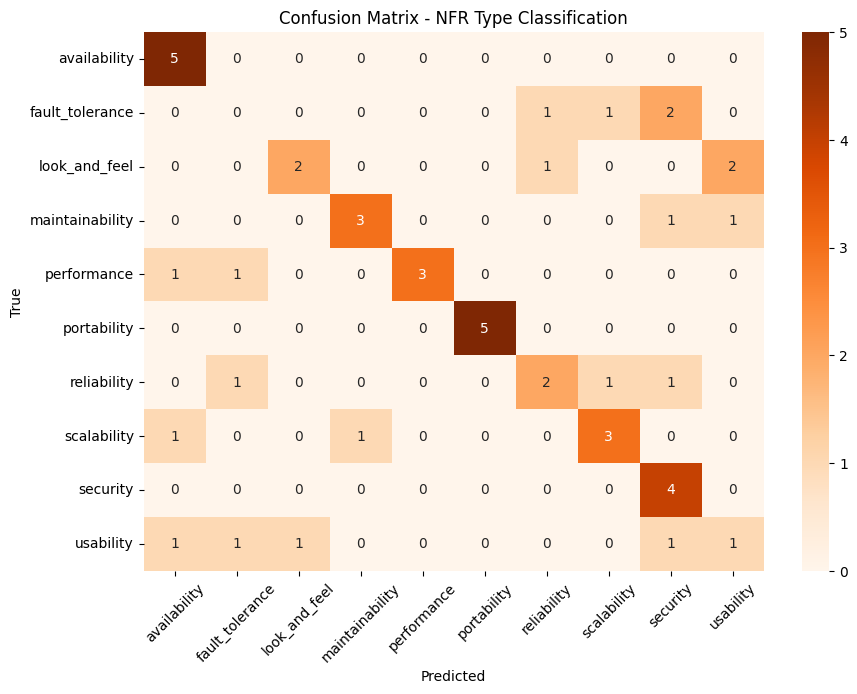

In [174]:

# =========================================
# STEP 8 - Confusion Matrix
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

labels_nfr = sorted(y_nfr.unique())
cm_nfr = confusion_matrix(y_test_nfr, y_pred_nfr, labels=labels_nfr)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_nfr,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=labels_nfr,
    yticklabels=labels_nfr
)
plt.title("Confusion Matrix - NFR Type Classification")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

The NFR subtype classifier achieved an accuracy of about 58% on a balanced 10-class dataset.
Given the small number of training examples per subtype, this result is acceptable as a proof of concept.
The model performs well on distinctive classes such as portability, availability, and security,
but struggles on semantically overlapping subtypes such as fault tolerance, reliability, and usability.
This highlights the need for either more data, class regrouping, or transformer-based modeling in future work.

In [175]:
# =========================================
# STEP 9 - Manual Testing
# =========================================

sample_nfrs = [
    "All passwords must be encrypted.",
    "The system shall respond within 2 seconds.",
    "The interface shall be easy to use.",
    "The product shall be available 99.9% of the time.",
    "The system shall support up to 100,000 concurrent users.",
    "The application shall run on Android and iOS devices."
]

sample_nfr_vectors = tfidf_nfr.transform(sample_nfrs)
sample_nfr_predictions = nfr_type_model.predict(sample_nfr_vectors)

manual_nfr_df = pd.DataFrame({
    "requirement": sample_nfrs,
    "predicted_nfr_type": sample_nfr_predictions
})

display(manual_nfr_df)

,requirement,predicted_nfr_type
0,All passwords must be encrypted.,maintainability
1,The system shall respond within 2 seconds.,performance
2,The interface shall be easy to use.,usability
3,The product shall be available 99.9% of the time.,availability
4,"The system shall support up to 100,000 concurr...",scalability
5,The application shall run on Android and iOS d...,portability


In [176]:
# =========================================
# STEP 10 - Reusable prediction function
# =========================================

def predict_nfr_type(text):
    vector = tfidf_nfr.transform([text])
    pred = nfr_type_model.predict(vector)[0]

    if hasattr(nfr_type_model, "predict_proba"):
        probs = nfr_type_model.predict_proba(vector)[0]
        class_probs = dict(zip(nfr_type_model.classes_, probs))
    else:
        class_probs = None

    return {
        "text": text,
        "predicted_nfr_type": pred,
        "class_probabilities": class_probs
    }

In [177]:
#### predict_nfr_type("All passwords must be encrypted.")

# =========================================
# MODULE 3B — GROUPED NFR TYPE CLASSIFICATION
# =========================================

In [178]:
# =========================================
# STEP 1 - Group NFR subtypes
# =========================================

group_map = {
    "security": "security",
    "performance": "performance",
    "usability": "usability",
    "availability": "reliability_availability",
    "reliability": "reliability_availability",
    "portability": "portability_compatibility",
    "compatibility": "portability_compatibility",
    "maintainability": "maintainability_fault_tolerance",
    "fault_tolerance": "maintainability_fault_tolerance",
    "scalability": "scalability",
    "look_and_feel": "look_and_feel"
}

df_nfr_grouped = df_nfr.copy()
df_nfr_grouped["grouped_nfr_type"] = df_nfr_grouped["sub_label"].map(group_map)

df_nfr_grouped = df_nfr_grouped.dropna(subset=["grouped_nfr_type"]).copy()

print("Grouped NFR dataset shape:", df_nfr_grouped.shape)
print("\nGrouped class distribution:")
print(df_nfr_grouped["grouped_nfr_type"].value_counts())

display(df_nfr_grouped[["text", "sub_label", "grouped_nfr_type"]].sample(12, random_state=42))

Grouped NFR dataset shape: (3155, 15)

Grouped class distribution:
grouped_nfr_type
security                           2179
usability                           248
performance                         234
reliability_availability            197
look_and_feel                       121
maintainability_fault_tolerance      93
scalability                          55
portability_compatibility            28
Name: count, dtype: int64


,text,sub_label,grouped_nfr_type
25996,The Disputes System must prevent external user...,security,security
22808,The system has capability to electronically pr...,security,security
25466,Selecting multiple encounters will allow you t...,security,security
26491,The product shall enable privacy by encryption...,security,security
353,The System shall maintain consistent security....,security,security
26183,The product possibly and possibly dependent da...,security,security
22473,The public health agent can select to see the ...,security,security
22138,An HCP can view a previously created lab proce...,security,security
25477,Click 'Update List' to refresh the billing lis...,security,security
15181,The user ID and date or time stamp shall be re...,security,security


In [179]:
# =========================================
# STEP 2 - Balance grouped classes
# =========================================

min_count_grouped = df_nfr_grouped["grouped_nfr_type"].value_counts().min()

df_nfr_grouped_balanced = (
    df_nfr_grouped
    .groupby("grouped_nfr_type", group_keys=False)
    .sample(min_count_grouped, random_state=42)
    .copy()
)

print("Balanced grouped shape:", df_nfr_grouped_balanced.shape)
print("\nBalanced grouped distribution:")
print(df_nfr_grouped_balanced["grouped_nfr_type"].value_counts())

display(df_nfr_grouped_balanced[["text", "grouped_nfr_type"]].sample(10, random_state=42))

Balanced grouped shape: (224, 15)

Balanced grouped distribution:
grouped_nfr_type
look_and_feel                      28
maintainability_fault_tolerance    28
performance                        28
portability_compatibility          28
reliability_availability           28
scalability                        28
security                           28
usability                          28
Name: count, dtype: int64


,text,grouped_nfr_type
6980,Single column page layout shall be used for th...,look_and_feel
762,An end-user may use this system on any OS; eit...,portability_compatibility
3446,Reports must be available giving statistical a...,reliability_availability
1019,product shall capable handle exist user number...,scalability
4,If projected the data must be understandable. ...,usability
26621,Mean Time Between Failures should be more than...,reliability_availability
1630,system shall display confirmation message user...,performance
26630,The system must be accessible via standard web...,portability_compatibility
20799,If the individual is present for or otherwise ...,security
17126,The solution should provide audit capabilities...,security


In [180]:
# =========================================
# STEP 3 - Train / Test Split
# =========================================

from sklearn.model_selection import train_test_split

X_grouped = df_nfr_grouped_balanced["text"]
y_grouped = df_nfr_grouped_balanced["grouped_nfr_type"]

X_train_grouped, X_test_grouped, y_train_grouped, y_test_grouped = train_test_split(
    X_grouped,
    y_grouped,
    test_size=0.2,
    random_state=42,
    stratify=y_grouped
)

print("Train size:", len(X_train_grouped))
print("Test size:", len(X_test_grouped))

print("\nTrain distribution:")
print(y_train_grouped.value_counts())

print("\nTest distribution:")
print(y_test_grouped.value_counts())

Train size: 179
Test size: 45

Train distribution:
grouped_nfr_type
look_and_feel                      23
maintainability_fault_tolerance    23
scalability                        23
portability_compatibility          22
performance                        22
reliability_availability           22
security                           22
usability                          22
Name: count, dtype: int64

Test distribution:
grouped_nfr_type
usability                          6
portability_compatibility          6
security                           6
performance                        6
reliability_availability           6
maintainability_fault_tolerance    5
look_and_feel                      5
scalability                        5
Name: count, dtype: int64


In [181]:
# =========================================
# STEP 4 - TF-IDF Vectorization
# =========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_grouped = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    lowercase=True
)

X_train_grouped_tfidf = tfidf_grouped.fit_transform(X_train_grouped)
X_test_grouped_tfidf = tfidf_grouped.transform(X_test_grouped)

print("X_train_grouped_tfidf shape:", X_train_grouped_tfidf.shape)
print("X_test_grouped_tfidf shape:", X_test_grouped_tfidf.shape)

X_train_grouped_tfidf shape: (179, 3199)
X_test_grouped_tfidf shape: (45, 3199)


In [182]:
# =========================================
# STEP 5 - Train Logistic Regression
# =========================================

from sklearn.linear_model import LogisticRegression

grouped_nfr_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

grouped_nfr_model.fit(X_train_grouped_tfidf, y_train_grouped)

print("Grouped NFR type model trained successfully.")

Grouped NFR type model trained successfully.


In [183]:
# =========================================
# STEP 6 - Evaluation
# =========================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_grouped = grouped_nfr_model.predict(X_test_grouped_tfidf)

grouped_accuracy = accuracy_score(y_test_grouped, y_pred_grouped)

print("Accuracy:", grouped_accuracy)
print("\nClassification Report:")
print(classification_report(y_test_grouped, y_pred_grouped))

Accuracy: 0.6666666666666666

Classification Report:
                                 precision    recall  f1-score   support

                  look_and_feel       0.80      0.80      0.80         5
maintainability_fault_tolerance       0.67      0.40      0.50         5
                    performance       1.00      0.83      0.91         6
      portability_compatibility       0.75      1.00      0.86         6
       reliability_availability       0.50      0.17      0.25         6
                    scalability       0.44      0.80      0.57         5
                       security       0.80      0.67      0.73         6
                      usability       0.50      0.67      0.57         6

                       accuracy                           0.67        45
                      macro avg       0.68      0.67      0.65        45
                   weighted avg       0.69      0.67      0.65        45



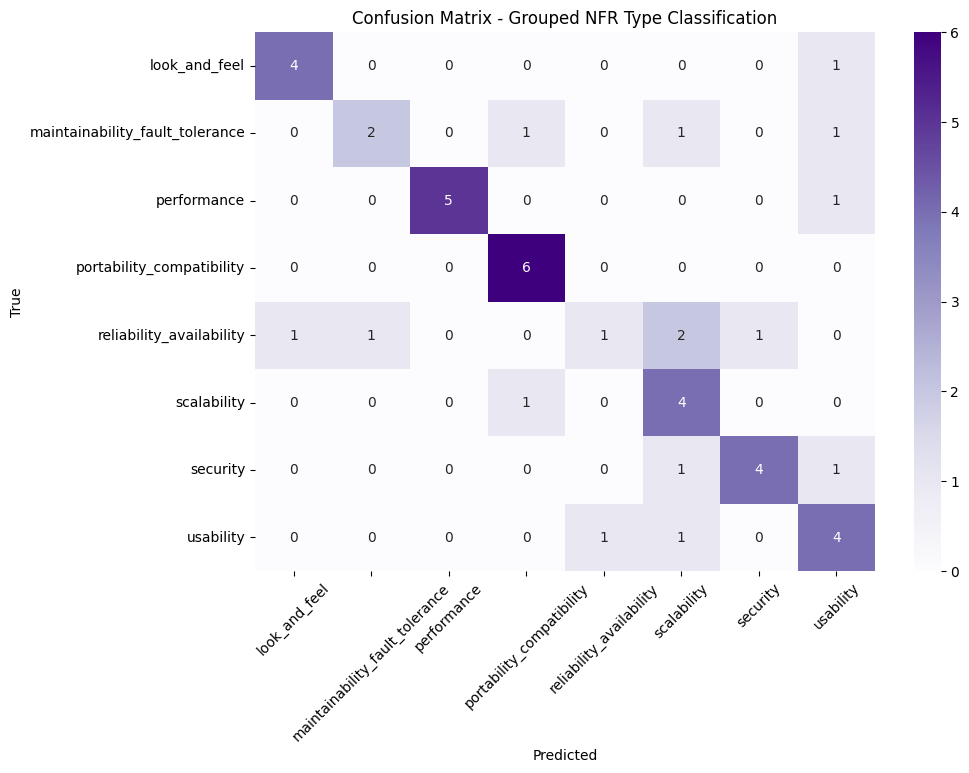

In [184]:
# =========================================
# STEP 7 - Confusion Matrix
# =========================================

import matplotlib.pyplot as plt
import seaborn as sns

labels_grouped = sorted(y_grouped.unique())
cm_grouped = confusion_matrix(y_test_grouped, y_pred_grouped, labels=labels_grouped)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm_grouped,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=labels_grouped,
    yticklabels=labels_grouped
)
plt.title("Confusion Matrix - Grouped NFR Type Classification")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [185]:
# =========================================
# STEP 8 - Manual Testing
# =========================================

sample_grouped_nfrs = [
    "All passwords must be encrypted.",
    "The system shall respond within 2 seconds.",
    "The interface shall be easy to use.",
    "The product shall be available 99.9% of the time.",
    "The system shall support up to 100,000 concurrent users.",
    "The application shall run on Android and iOS devices.",
    "The system shall continue operating after a server failure.",
    "The source code shall be easy to maintain."
]

sample_grouped_vectors = tfidf_grouped.transform(sample_grouped_nfrs)
sample_grouped_predictions = grouped_nfr_model.predict(sample_grouped_vectors)

manual_grouped_df = pd.DataFrame({
    "requirement": sample_grouped_nfrs,
    "predicted_grouped_nfr_type": sample_grouped_predictions
})

display(manual_grouped_df)

,requirement,predicted_grouped_nfr_type
0,All passwords must be encrypted.,reliability_availability
1,The system shall respond within 2 seconds.,performance
2,The interface shall be easy to use.,look_and_feel
3,The product shall be available 99.9% of the time.,reliability_availability
4,"The system shall support up to 100,000 concurr...",scalability
5,The application shall run on Android and iOS d...,portability_compatibility
6,The system shall continue operating after a se...,maintainability_fault_tolerance
7,The source code shall be easy to maintain.,scalability


In [186]:
# =========================================
# STEP 9 - Reusable prediction function
# =========================================

def predict_grouped_nfr_type(text):
    vector = tfidf_grouped.transform([text])
    pred = grouped_nfr_model.predict(vector)[0]

    if hasattr(grouped_nfr_model, "predict_proba"):
        probs = grouped_nfr_model.predict_proba(vector)[0]
        class_probs = dict(zip(grouped_nfr_model.classes_, probs))
    else:
        class_probs = None

    return {
        "text": text,
        "predicted_grouped_nfr_type": pred,
        "class_probabilities": class_probs
    }

In [187]:
predict_grouped_nfr_type("All passwords must be encrypted.")

{'text': 'All passwords must be encrypted.',
 'predicted_grouped_nfr_type': 'reliability_availability',
 'class_probabilities': {'look_and_feel': np.float64(0.1280587341273911),
  'maintainability_fault_tolerance': np.float64(0.12458428630022088),
  'performance': np.float64(0.0884421430159154),
  'portability_compatibility': np.float64(0.1018448867663032),
  'reliability_availability': np.float64(0.1785381851905614),
  'scalability': np.float64(0.1198934588168267),
  'security': np.float64(0.11460151161741404),
  'usability': np.float64(0.14403679416536727)}}

The grouped NFR subtype model is more robust than the fine-grained version.
Manual testing confirms that it correctly identifies several distinctive categories
such as performance, scalability, portability/compatibility, and reliability/availability.

However, some conceptually close categories remain difficult, especially security,
usability, and maintainability-related requirements. This is mainly due to limited
training data and lexical overlap between NFR categories.

For the final pipeline, the grouped classifier is retained as the main NFR subtype module,
while its limitations are clearly acknowledged.

In [188]:
# =========================================
# MODULE C0 — KEYWORD-BASED SECTION COVERAGE
# =========================================

In [189]:
## Step 1 - Define expected SRS sections
## Step 2 - Build keyword dictionaries
## Step 3 - Create a simple document example
## Step 4 - Detect missing sections
## Step 5 - Compute coverage summary
## Step 6 - Show recommendations
## Step 7 - Build reusable gap detection function

In [190]:
# =========================================
# STEP 1 - Define expected SRS sections
# =========================================


expected_srs_sections = [
    "introduction",
    "general_description",
    "functional_requirements",
    "interface_requirements",
    "performance_requirements",
    "constraints",
    "non_functional_requirements",
    "risks",
    "schedule_budget",
    "appendices",
    "conclusion",
    "acceptance_criteria"
]

print(expected_srs_sections)

['introduction', 'general_description', 'functional_requirements', 'interface_requirements', 'performance_requirements', 'constraints', 'non_functional_requirements', 'risks', 'schedule_budget', 'appendices', 'conclusion', 'acceptance_criteria']


In [191]:
# =========================================
# STEP 2 - Build keyword dictionaries
# =========================================


section_keywords_enhanced = {
    "introduction": [
        "introduction", "purpose", "scope", "overview", "document convention",
        "intended audience", "definitions", "acronyms", "references"
    ],
    "general_description": [
        "general description", "overall description", "product perspective",
        "product functions", "user characteristics", "user objectives",
        "business context", "general functions"
    ],
    "functional_requirements": [
        "functional requirements", "function name", "functionality",
        "the system shall", "shall allow", "shall provide", "use case"
    ],
    "interface_requirements": [
        "interface requirements", "interfaces", "user interfaces",
        "hardware interfaces", "software interfaces", "communications interfaces"
    ],
    "performance_requirements": [
        "performance requirements", "performance", "response time",
        "latency", "throughput", "maximum error rate", "required memory"
    ],
    "constraints": [
        "design constraints", "general constraints", "constraints",
        "limitation", "restriction", "must comply", "standard",
        "regulation", "technical problems", "resource limits"
    ],
    "non_functional_requirements": [
        "non functional requirements", "non-functional requirements",
        "non functional attributes", "non-functional attributes",
        "security", "usability", "availability", "reliability",
        "maintainability", "portability", "scalability", "supportability"
    ],
    "risks": [
        "risk", "risks", "issue", "issues", "challenge", "threat",
        "dependency", "uncertainty", "database failure", "data corruption",
        "system failures", "network down"
    ],
    "schedule_budget": [
        "schedule and budget", "preliminary schedule and budget",
        "cost and schedule", "budget", "delivery date", "cost",
        "time required", "duration", "hosting service", "domain"
    ],
    "appendices": [
        "appendices", "appendix", "supporting information",
        "references", "glossary", "acronyms", "abbreviations"
    ],
    "conclusion": [
        "conclusion", "summary", "final remarks"
    ],
    "acceptance_criteria": [
        "acceptance criteria", "accepted if", "success criteria",
        "validation", "verification", "testable", "done when"
    ]
}

section_keywords_enhanced

{'introduction': ['introduction',
  'purpose',
  'scope',
  'overview',
  'document convention',
  'intended audience',
  'definitions',
  'acronyms',
  'references'],
 'general_description': ['general description',
  'overall description',
  'product perspective',
  'product functions',
  'user characteristics',
  'user objectives',
  'business context',
  'general functions'],
 'functional_requirements': ['functional requirements',
  'function name',
  'functionality',
  'the system shall',
  'shall allow',
  'shall provide',
  'use case'],
 'interface_requirements': ['interface requirements',
  'interfaces',
  'user interfaces',
  'hardware interfaces',
  'software interfaces',
  'communications interfaces'],
 'performance_requirements': ['performance requirements',
  'performance',
  'response time',
  'latency',
  'throughput',
  'maximum error rate',
  'required memory'],
 'constraints': ['design constraints',
  'general constraints',
  'constraints',
  'limitation',
  'restricti

In [192]:
# =========================================
# STEP 3 - Real SRS text example
# =========================================

sample_srs_text = """
Software Requirement Specification (SRS) Format

Introduction
Purpose of this Document - At first, main aim of why this document is necessary and what’s purpose of document is explained and described.
Scope of this document - In this, overall working and main objective of document and what value it will provide to customer is described and explained.
Overview - In this, description of product is explained. It’s simply summary or overall review of product.

General description
In this, general functions of product which includes objective of user, a user characteristic, features, benefits, about why its importance is mentioned.

Functional Requirements
In this, possible outcome of software system which includes effects due to operation of program is fully explained.

Interface Requirements
In this, software interfaces which mean how software program communicates with each other or users either in form of any language, code, or message are fully described and explained.

Performance Requirements
In this, how a software system performs desired functions under specific condition is explained.

Design Constraints
In this, constraints which simply means limitation or restriction are specified and explained for design team.

Non-Functional Attributes
In this, non-functional attributes are explained that are required by software system for better performance.

Preliminary Schedule and Budget
In this, initial version and budget of project plan are explained.

Appendices
In this, additional information like references from where information is gathered, definitions of some specific terms, acronyms, abbreviations, etc. are given and explained.

Uses of SRS document
Development team require it for developing product according to the need.
Test plans are generated by testing group based on the describe external behaviour.

Conclusion
Software development requires a well-structured Software Requirement Specification (SRS).
"""
print(sample_srs_text[:1500])


Software Requirement Specification (SRS) Format

Introduction
Purpose of this Document - At first, main aim of why this document is necessary and what’s purpose of document is explained and described.
Scope of this document - In this, overall working and main objective of document and what value it will provide to customer is described and explained.
Overview - In this, description of product is explained. It’s simply summary or overall review of product.

General description
In this, general functions of product which includes objective of user, a user characteristic, features, benefits, about why its importance is mentioned.

Functional Requirements
In this, possible outcome of software system which includes effects due to operation of program is fully explained.

Interface Requirements
In this, software interfaces which mean how software program communicates with each other or users either in form of any language, code, or message are fully described and explained.

Performance Req

In [193]:
# =========================================
# STEP 4 - Detect SRS sections
# =========================================

def detect_srs_sections(text, section_keywords):
    text_lower = text.lower()
    detected = {}

    for section, keywords in section_keywords.items():
        matched_keywords = [kw for kw in keywords if kw.lower() in text_lower]
        detected[section] = {
            "present": len(matched_keywords) > 0,
            "matched_keywords": matched_keywords
        }

    return detected

detected_sections = detect_srs_sections(sample_srs_text, section_keywords_enhanced)

for section, info in detected_sections.items():
    print(f"{section}: {'Present' if info['present'] else 'Missing'} | matched: {info['matched_keywords'][:5]}")

introduction: Present | matched: ['introduction', 'purpose', 'scope', 'overview', 'definitions']
general_description: Present | matched: ['general description', 'general functions']
functional_requirements: Present | matched: ['functional requirements']
interface_requirements: Present | matched: ['interface requirements', 'interfaces', 'software interfaces']
performance_requirements: Present | matched: ['performance requirements', 'performance']
constraints: Present | matched: ['design constraints', 'constraints', 'limitation', 'restriction']
non_functional_requirements: Present | matched: ['non-functional attributes']
risks: Missing | matched: []
schedule_budget: Present | matched: ['schedule and budget', 'preliminary schedule and budget', 'budget']
appendices: Present | matched: ['appendices', 'references', 'acronyms', 'abbreviations']
conclusion: Present | matched: ['conclusion', 'summary']
acceptance_criteria: Missing | matched: []


In [194]:
# =========================================
# STEP 5 - Compute coverage summary
# =========================================

coverage_df = pd.DataFrame([
    {
        "section": section,
        "present": info["present"],
        "matched_keywords": ", ".join(info["matched_keywords"])
    }
    for section, info in detected_sections.items()
])

coverage_df["status"] = coverage_df["present"].map(lambda x: "Present" if x else "Missing")

display(coverage_df)

coverage_score = coverage_df["present"].mean()
print(f"Coverage score: {coverage_score:.2%}")

,section,present,matched_keywords,status
0,introduction,True,"introduction, purpose, scope, overview, defini...",Present
1,general_description,True,"general description, general functions",Present
2,functional_requirements,True,functional requirements,Present
3,interface_requirements,True,"interface requirements, interfaces, software i...",Present
4,performance_requirements,True,"performance requirements, performance",Present
5,constraints,True,"design constraints, constraints, limitation, r...",Present
6,non_functional_requirements,True,non-functional attributes,Present
7,risks,False,,Missing
8,schedule_budget,True,"schedule and budget, preliminary schedule and ...",Present
9,appendices,True,"appendices, references, acronyms, abbreviations",Present


Coverage score: 83.33%


In [195]:
# =========================================
# STEP 6 - Show recommendations
# =========================================

missing_sections = coverage_df.loc[coverage_df["present"] == False, "section"].tolist()

print("Missing sections detected:")
for sec in missing_sections:
    print("-", sec)

print("\nRecommendations:")
recommendation_map = {
    "introduction": "Add purpose, scope, overview, and audience information.",
    "general_description": "Add product perspective, user characteristics, and system context.",
    "functional_requirements": "Add detailed system behaviors, features, and expected outputs.",
    "interface_requirements": "Add user, software, hardware, or communication interface definitions.",
    "performance_requirements": "Add measurable performance targets such as response time or throughput.",
    "constraints": "Add technical, regulatory, budget, or platform constraints.",
    "non_functional_requirements": "Add security, usability, reliability, portability, and maintainability requirements.",
    "risks": "Add operational, technical, and project risks.",
    "schedule_budget": "Add estimated timeline, delivery milestones, and budget constraints.",
    "appendices": "Add glossary, acronyms, references, or supporting documents.",
    "conclusion": "Add a final synthesis of the specification.",
    "acceptance_criteria": "Add verifiable success conditions and validation rules."
}

for sec in missing_sections:
    print(f"- {sec}: {recommendation_map[sec]}")

Missing sections detected:
- risks
- acceptance_criteria

Recommendations:
- risks: Add operational, technical, and project risks.
- acceptance_criteria: Add verifiable success conditions and validation rules.


In [196]:
# =========================================
# STEP 7 - Reusable enhanced gap detection function
# =========================================

def analyze_srs_gaps_enhanced(text):
    detected = detect_srs_sections(text, section_keywords_enhanced)

    coverage_df = pd.DataFrame([
        {
            "section": section,
            "present": info["present"],
            "matched_keywords": ", ".join(info["matched_keywords"])
        }
        for section, info in detected.items()
    ])

    coverage_df["status"] = coverage_df["present"].map(lambda x: "Present" if x else "Missing")

    missing_sections = coverage_df.loc[coverage_df["present"] == False, "section"].tolist()
    coverage_score = coverage_df["present"].mean()

    return {
        "coverage_score": coverage_score,
        "missing_sections": missing_sections,
        "coverage_table": coverage_df
    }

In [197]:
gap_result = analyze_srs_gaps_enhanced(sample_srs_text)

print("Coverage score:", gap_result["coverage_score"])
print("Missing sections:", gap_result["missing_sections"])
display(gap_result["coverage_table"])

Coverage score: 0.8333333333333334
Missing sections: ['risks', 'acceptance_criteria']


,section,present,matched_keywords,status
0,introduction,True,"introduction, purpose, scope, overview, defini...",Present
1,general_description,True,"general description, general functions",Present
2,functional_requirements,True,functional requirements,Present
3,interface_requirements,True,"interface requirements, interfaces, software i...",Present
4,performance_requirements,True,"performance requirements, performance",Present
5,constraints,True,"design constraints, constraints, limitation, r...",Present
6,non_functional_requirements,True,non-functional attributes,Present
7,risks,False,,Missing
8,schedule_budget,True,"schedule and budget, preliminary schedule and ...",Present
9,appendices,True,"appendices, references, acronyms, abbreviations",Present


In [198]:
# =========================================
# MODULE 5 — REQUIREMENT REWRITING / IMPROVEMENT
# =========================================

In [199]:
## Step 1 - Define ambiguity and weakness patterns
## Step 2 - Define rewrite templates
## Step 3 - Build requirement improvement function
## Step 4 - Test on weak requirements
## Step 5 - Build before/after comparison table
## Step 6 - Add quality flags
## Step 7 - Build reusable final function

In [200]:
# =========================================
# STEP 1 - Define ambiguity and weakness patterns
# =========================================

ambiguity_patterns = {
    "weak_modality": [
        "should", "could", "may", "might", "can"
    ],
    "vague_adjectives": [
        "fast", "easy", "user-friendly", "efficient", "quick", "simple", "secure"
    ],
    "vague_adverbs": [
        "quickly", "easily", "efficiently", "smoothly"
    ],
    "vague_quantifiers": [
        "some", "many", "few", "several", "adequate", "appropriate"
    ],
    "open_ended_time": [
        "soon", "as soon as possible", "later", "eventually"
    ]
}

ambiguity_patterns

{'weak_modality': ['should', 'could', 'may', 'might', 'can'],
 'vague_adjectives': ['fast',
  'easy',
  'user-friendly',
  'efficient',
  'quick',
  'simple',
  'secure'],
 'vague_adverbs': ['quickly', 'easily', 'efficiently', 'smoothly'],
 'vague_quantifiers': ['some',
  'many',
  'few',
  'several',
  'adequate',
  'appropriate'],
 'open_ended_time': ['soon', 'as soon as possible', 'later', 'eventually']}

In [201]:
# =========================================
# STEP 2 - Define rewrite templates
# =========================================

rewrite_templates = {
    "fast": "The system shall respond within 2 seconds under normal operating conditions.",
    "easy": "The interface shall enable first-time users to complete the main task in less than 3 minutes without external assistance.",
    "user-friendly": "The interface shall allow users to complete the primary workflow with no more than 3 clicks after login.",
    "secure": "The system shall encrypt sensitive data in transit and at rest using industry-standard encryption mechanisms.",
    "quickly": "The system shall complete the requested operation within a measurable response-time threshold.",
    "efficiently": "The system shall execute the operation within the defined performance and resource limits.",
    "some": "The requirement shall specify the exact quantity or range expected.",
    "many": "The requirement shall specify a measurable number, percentage, or threshold.",
    "soon": "The requirement shall specify a concrete deadline or response time."
}

rewrite_templates

{'fast': 'The system shall respond within 2 seconds under normal operating conditions.',
 'easy': 'The interface shall enable first-time users to complete the main task in less than 3 minutes without external assistance.',
 'user-friendly': 'The interface shall allow users to complete the primary workflow with no more than 3 clicks after login.',
 'secure': 'The system shall encrypt sensitive data in transit and at rest using industry-standard encryption mechanisms.',
 'quickly': 'The system shall complete the requested operation within a measurable response-time threshold.',
 'efficiently': 'The system shall execute the operation within the defined performance and resource limits.',
 'some': 'The requirement shall specify the exact quantity or range expected.',
 'many': 'The requirement shall specify a measurable number, percentage, or threshold.',
 'soon': 'The requirement shall specify a concrete deadline or response time.'}

In [202]:
# =========================================
# STEP 3 - Build requirement improvement function
# =========================================

import re

def detect_requirement_issues(text):
    text_lower = text.lower()
    detected_issues = []

    for category, patterns in ambiguity_patterns.items():
        for pattern in patterns:
            if pattern in text_lower:
                detected_issues.append({
                    "category": category,
                    "pattern": pattern
                })

    return detected_issues


def improve_requirement(text):
    issues = detect_requirement_issues(text)
    improved_text = text
    suggestions = []

    # strengthen modality
    improved_text = re.sub(r"\bshould\b", "shall", improved_text, flags=re.IGNORECASE)
    improved_text = re.sub(r"\bcould\b", "shall", improved_text, flags=re.IGNORECASE)
    improved_text = re.sub(r"\bmay\b", "shall", improved_text, flags=re.IGNORECASE)
    improved_text = re.sub(r"\bcan\b", "shall", improved_text, flags=re.IGNORECASE)

    # rewrite vague expressions
    for issue in issues:
        pattern = issue["pattern"]
        if pattern in rewrite_templates:
            suggestions.append({
                "issue": pattern,
                "suggested_rewrite": rewrite_templates[pattern]
            })

    # targeted full rewrite for common weak patterns
    text_lower = text.lower()

    if "fast" in text_lower:
        improved_text = "The system shall respond within 2 seconds under normal operating conditions."
    elif "easy to use" in text_lower or "user-friendly" in text_lower:
        improved_text = "The interface shall allow users to complete the primary workflow in less than 3 minutes without training."
    elif "secure" in text_lower:
        improved_text = "The system shall protect sensitive data using encryption in transit and at rest, and enforce authenticated access control."
    elif "soon" in text_lower:
        improved_text = "The system shall complete the required action within a clearly specified deadline."

    return {
        "original_text": text,
        "detected_issues": issues,
        "improved_text": improved_text,
        "suggestions": suggestions
    }

In [203]:
# =========================================
# STEP 4 - Test on weak requirements
# =========================================

weak_requirements = [
    "The system should be fast.",
    "The interface should be easy to use.",
    "The system should be secure.",
    "The application may notify users soon.",
    "The system can process many requests efficiently."
]

for req in weak_requirements:
    result = improve_requirement(req)
    print("Original :", result["original_text"])
    print("Improved :", result["improved_text"])
    print("Issues   :", result["detected_issues"])
    print("-" * 80)

Original : The system should be fast.
Improved : The system shall respond within 2 seconds under normal operating conditions.
Issues   : [{'category': 'weak_modality', 'pattern': 'should'}, {'category': 'vague_adjectives', 'pattern': 'fast'}]
--------------------------------------------------------------------------------
Original : The interface should be easy to use.
Improved : The interface shall allow users to complete the primary workflow in less than 3 minutes without training.
Issues   : [{'category': 'weak_modality', 'pattern': 'should'}, {'category': 'vague_adjectives', 'pattern': 'easy'}]
--------------------------------------------------------------------------------
Original : The system should be secure.
Improved : The system shall protect sensitive data using encryption in transit and at rest, and enforce authenticated access control.
Issues   : [{'category': 'weak_modality', 'pattern': 'should'}, {'category': 'vague_adjectives', 'pattern': 'secure'}]
--------------------

In [204]:
# =========================================
# STEP 5 - Build before/after comparison table
# =========================================

rewriting_results = []

for req in weak_requirements:
    result = improve_requirement(req)
    rewriting_results.append({
        "original_requirement": result["original_text"],
        "improved_requirement": result["improved_text"],
        "issues_count": len(result["detected_issues"]),
        "issues_detected": ", ".join([x["pattern"] for x in result["detected_issues"]])
    })

rewriting_df = pd.DataFrame(rewriting_results)
display(rewriting_df)

,original_requirement,improved_requirement,issues_count,issues_detected
0,The system should be fast.,The system shall respond within 2 seconds unde...,2,"should, fast"
1,The interface should be easy to use.,The interface shall allow users to complete th...,2,"should, easy"
2,The system should be secure.,The system shall protect sensitive data using ...,2,"should, secure"
3,The application may notify users soon.,The system shall complete the required action ...,2,"may, soon"
4,The system can process many requests efficiently.,The system shall process many requests efficie...,4,"can, efficient, efficiently, many"


In [205]:
# =========================================
# STEP 6 - Add quality flags
# =========================================

def compute_quality_flags(text):
    text_lower = text.lower()

    flags = {
        "has_weak_modality": any(x in text_lower for x in ["should", "could", "may", "can"]),
        "has_vague_term": any(x in text_lower for x in [
            "fast", "easy", "user-friendly", "efficient", "quick", "simple", "secure"
        ]),
        "has_measurable_value": bool(re.search(r"\b\d+(\.\d+)?\b", text_lower)),
        "has_shall": "shall" in text_lower,
    }

    return flags


quality_flags_df = pd.DataFrame([
    {
        "requirement": req,
        **compute_quality_flags(req)
    }
    for req in weak_requirements
])

display(quality_flags_df)

,requirement,has_weak_modality,has_vague_term,has_measurable_value,has_shall
0,The system should be fast.,True,True,False,False
1,The interface should be easy to use.,True,True,False,False
2,The system should be secure.,True,True,False,False
3,The application may notify users soon.,True,False,False,False
4,The system can process many requests efficiently.,True,True,False,False


In [206]:
# =========================================
# STEP 7 - Build reusable final function
# =========================================

def analyze_and_improve_requirement(text):
    improvement = improve_requirement(text)
    quality_flags = compute_quality_flags(text)

    return {
        "original_text": text,
        "improved_text": improvement["improved_text"],
        "detected_issues": improvement["detected_issues"],
        "suggestions": improvement["suggestions"],
        "quality_flags": quality_flags
    }

In [207]:
analyze_and_improve_requirement("The system should be fast.")

{'original_text': 'The system should be fast.',
 'improved_text': 'The system shall respond within 2 seconds under normal operating conditions.',
 'detected_issues': [{'category': 'weak_modality', 'pattern': 'should'},
  {'category': 'vague_adjectives', 'pattern': 'fast'}],
 'suggestions': [{'issue': 'fast',
   'suggested_rewrite': 'The system shall respond within 2 seconds under normal operating conditions.'}],
 'quality_flags': {'has_weak_modality': True,
  'has_vague_term': True,
  'has_measurable_value': False,
  'has_shall': False}}

# =========================================
# MODULE 5A — QUALITY SCORING + INTELLIGENT REWRITING FOUNDATION
# =========================================

In [208]:
# =========================================
# STEP 1 - Define requirement quality dimensions
# =========================================

quality_dimensions = [
    "clarity",
    "specificity",
    "measurability",
    "testability",
    "atomicity",
    "modality_strength"
]

print(quality_dimensions)

['clarity', 'specificity', 'measurability', 'testability', 'atomicity', 'modality_strength']


In [209]:
# =========================================
# STEP 2 - Define analysis patterns
# =========================================

import re

weak_modals = ["should", "could", "may", "might"]
strong_modals = ["shall", "must"]

vague_terms = [
    "fast", "easy", "simple", "efficient", "quick", "quickly",
    "user-friendly", "appropriate", "adequate", "many", "some",
    "several", "soon", "robust", "secure", "flexible"
]

conjunction_patterns = [" and ", " or "]

def contains_number(text):
    return bool(re.search(r"\b\d+(\.\d+)?\b", str(text)))

def contains_weak_modal(text):
    text = str(text).lower()
    return any(w in text for w in weak_modals)

def contains_strong_modal(text):
    text = str(text).lower()
    return any(w in text for w in strong_modals)

def contains_vague_term(text):
    text = str(text).lower()
    return any(v in text for v in vague_terms)

def contains_multiple_actions(text):
    text = str(text).lower()
    return any(c in text for c in conjunction_patterns)

In [210]:
# =========================================
# STEP 3 - Build requirement quality scoring
# =========================================

def score_requirement_quality(text):
    text = str(text).strip()
    text_lower = text.lower()

    has_number = contains_number(text)
    weak_modal = contains_weak_modal(text)
    strong_modal = contains_strong_modal(text)
    vague = contains_vague_term(text)
    multi_action = contains_multiple_actions(text)

    scores = {
        "clarity": 1.0,
        "specificity": 1.0,
        "measurability": 1.0,
        "testability": 1.0,
        "atomicity": 1.0,
        "modality_strength": 1.0
    }

    issues = []

    if weak_modal:
        scores["modality_strength"] -= 0.6
        scores["clarity"] -= 0.2
        issues.append("weak_modality")

    if not strong_modal and not weak_modal:
        scores["modality_strength"] -= 0.3
        issues.append("missing_explicit_modality")

    if vague:
        scores["clarity"] -= 0.4
        scores["specificity"] -= 0.5
        scores["testability"] -= 0.4
        issues.append("vague_wording")

    if not has_number:
        scores["measurability"] -= 0.5
        issues.append("not_measurable")

    if multi_action:
        scores["atomicity"] -= 0.4
        issues.append("possibly_non_atomic")

    # bornage
    for k in scores:
        scores[k] = max(0.0, min(1.0, scores[k]))

    overall_score = sum(scores.values()) / len(scores)

    return {
        "text": text,
        "scores": scores,
        "overall_score": round(overall_score, 3),
        "issues": issues
    }

In [211]:
# =========================================
# STEP 4 - Test quality scoring
# =========================================

test_requirements = [
    "The system should be fast.",
    "The interface shall be easy to use.",
    "The system shall respond within 2 seconds.",
    "The system may notify users soon.",
    "The system shall authenticate users using email and password.",
    "The system shall validate input and save data and notify administrators."
]

quality_results = [score_requirement_quality(req) for req in test_requirements]

for result in quality_results:
    print("Requirement:", result["text"])
    print("Overall score:", result["overall_score"])
    print("Issues:", result["issues"])
    print("Scores:", result["scores"])
    print("-" * 80)

Requirement: The system should be fast.
Overall score: 0.567
Issues: ['weak_modality', 'vague_wording', 'not_measurable']
Scores: {'clarity': 0.4, 'specificity': 0.5, 'measurability': 0.5, 'testability': 0.6, 'atomicity': 1.0, 'modality_strength': 0.4}
--------------------------------------------------------------------------------
Requirement: The interface shall be easy to use.
Overall score: 0.7
Issues: ['vague_wording', 'not_measurable']
Scores: {'clarity': 0.6, 'specificity': 0.5, 'measurability': 0.5, 'testability': 0.6, 'atomicity': 1.0, 'modality_strength': 1.0}
--------------------------------------------------------------------------------
Requirement: The system shall respond within 2 seconds.
Overall score: 1.0
Issues: []
Scores: {'clarity': 1.0, 'specificity': 1.0, 'measurability': 1.0, 'testability': 1.0, 'atomicity': 1.0, 'modality_strength': 1.0}
--------------------------------------------------------------------------------
Requirement: The system may notify users soo

In [212]:
# =========================================
# STEP 5 - Build quality scoring table
# =========================================

quality_df = pd.DataFrame([
    {
        "requirement": r["text"],
        "overall_score": r["overall_score"],
        "issues": ", ".join(r["issues"]),
        **r["scores"]
    }
    for r in quality_results
])

display(quality_df)

,requirement,overall_score,issues,clarity,specificity,measurability,testability,atomicity,modality_strength
0,The system should be fast.,0.567,"weak_modality, vague_wording, not_measurable",0.4,0.5,0.5,0.6,1.0,0.4
1,The interface shall be easy to use.,0.700,"vague_wording, not_measurable",0.6,0.5,0.5,0.6,1.0,1.0
2,The system shall respond within 2 seconds.,1.000,,1.0,1.0,1.0,1.0,1.0,1.0
3,The system may notify users soon.,0.567,"weak_modality, vague_wording, not_measurable",0.4,0.5,0.5,0.6,1.0,0.4
4,The system shall authenticate users using emai...,0.850,"not_measurable, possibly_non_atomic",1.0,1.0,0.5,1.0,0.6,1.0
5,The system shall validate input and save data ...,0.850,"not_measurable, possibly_non_atomic",1.0,1.0,0.5,1.0,0.6,1.0


In [213]:
# =========================================
# STEP 6 - Build intelligent analysis function
# =========================================

def analyze_requirement_for_rewriting(text):
    quality = score_requirement_quality(text)

    recommended_actions = []

    if "weak_modality" in quality["issues"]:
        recommended_actions.append("strengthen_modality")

    if "vague_wording" in quality["issues"]:
        recommended_actions.append("replace_vague_terms")

    if "not_measurable" in quality["issues"]:
        recommended_actions.append("add_measurable_criterion")

    if "possibly_non_atomic" in quality["issues"]:
        recommended_actions.append("split_into_atomic_requirements")

    return {
        "text": text,
        "overall_score": quality["overall_score"],
        "issues": quality["issues"],
        "recommended_actions": recommended_actions,
        "dimension_scores": quality["scores"]
    }

In [214]:
# =========================================
# STEP 7 - Manual intelligent analysis
# =========================================

analysis_example = analyze_requirement_for_rewriting("The system should be fast and easy to use.")
analysis_example

{'text': 'The system should be fast and easy to use.',
 'overall_score': 0.5,
 'issues': ['weak_modality',
  'vague_wording',
  'not_measurable',
  'possibly_non_atomic'],
 'recommended_actions': ['strengthen_modality',
  'replace_vague_terms',
  'add_measurable_criterion',
  'split_into_atomic_requirements'],
 'dimension_scores': {'clarity': 0.4,
  'specificity': 0.5,
  'measurability': 0.5,
  'testability': 0.6,
  'atomicity': 0.6,
  'modality_strength': 0.4}}

In [215]:
# =========================================
# STEP 8 - Apply quality scoring to sample requirements
# =========================================

sample_df = df_requirements.sample(20, random_state=42).copy()

sample_df["quality_analysis"] = sample_df["text"].apply(analyze_requirement_for_rewriting)
sample_df["quality_score"] = sample_df["quality_analysis"].apply(lambda x: x["overall_score"])
sample_df["issues_detected"] = sample_df["quality_analysis"].apply(lambda x: ", ".join(x["issues"]))
sample_df["recommended_actions"] = sample_df["quality_analysis"].apply(lambda x: ", ".join(x["recommended_actions"]))

display(sample_df[["text", "label", "sub_label", "quality_score", "issues_detected", "recommended_actions"]])

,text,label,sub_label,quality_score,issues_detected,recommended_actions
22482,3.2.36.4 Alternate Flows.,FR,functional,0.950,missing_explicit_modality,
4463,Data and event logging,FR,functional,0.800,"missing_explicit_modality, not_measurable, pos...","add_measurable_criterion, split_into_atomic_re..."
21362,A covered entity must document the following a...,FR,functional,0.933,possibly_non_atomic,split_into_atomic_requirements
10657,System shall ensure portability by enabling ac...,NFR,general,0.917,not_measurable,add_measurable_criterion
3880,MARC bibliographic and authority records can b...,FR,functional,0.883,"missing_explicit_modality, possibly_non_atomic",split_into_atomic_requirements
23266,The system has an unmerge process.,FR,functional,0.867,"missing_explicit_modality, not_measurable",add_measurable_criterion
9795,The BE shall store input data records in a mem...,FR,general,0.850,"not_measurable, possibly_non_atomic","add_measurable_criterion, split_into_atomic_re..."
12473,"Upon selecting Home, system shall display vide...",FR,general,0.850,"not_measurable, possibly_non_atomic","add_measurable_criterion, split_into_atomic_re..."
22704,The LHCP can view of the comprehensive patient...,NFR,security,0.867,"missing_explicit_modality, not_measurable",add_measurable_criterion
4383,Upload File,FR,functional,0.867,"missing_explicit_modality, not_measurable",add_measurable_criterion


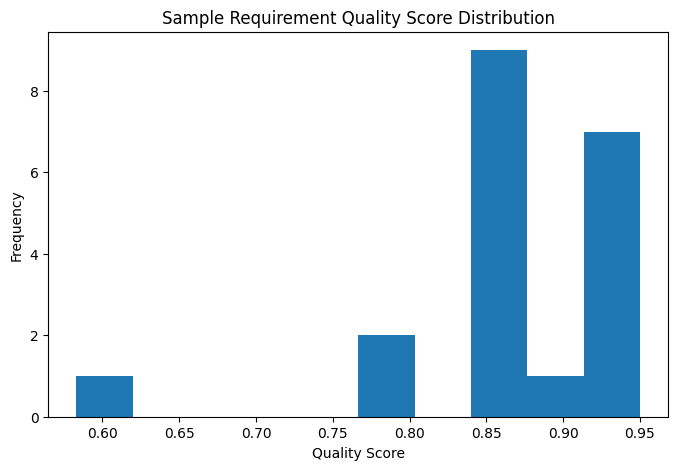

In [216]:
# =========================================
# STEP 9 - Visualize quality scores
# =========================================

plt.figure(figsize=(8,5))
plt.hist(sample_df["quality_score"], bins=10)
plt.title("Sample Requirement Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")
plt.show()

# =========================================
# MODULE 5B — INTELLIGENT REQUIREMENT REWRITING
# =========================================

In [217]:
# =========================================
# STEP 1 - Define intelligent rewriting rules
# =========================================

def rewrite_weak_modality(text):
    text = re.sub(r"\bshould\b", "shall", text, flags=re.IGNORECASE)
    text = re.sub(r"\bcould\b", "shall", text, flags=re.IGNORECASE)
    text = re.sub(r"\bmay\b", "shall", text, flags=re.IGNORECASE)
    text = re.sub(r"\bmight\b", "shall", text, flags=re.IGNORECASE)
    return text

def rewrite_vague_terms(text):
    replacements = {
        r"\bfast\b": "respond within 2 seconds under normal operating conditions",
        r"\beasy to use\b": "allow first-time users to complete the main task in less than 3 minutes without training",
        r"\beasy\b": "usable with minimal user effort and no prior training",
        r"\buser-friendly\b": "allow users to complete the primary workflow in no more than 3 steps after login",
        r"\bsecure\b": "protect sensitive data using encryption in transit and at rest, with authenticated access control",
        r"\bquickly\b": "within a measurable response-time threshold",
        r"\befficient\b": "within defined performance and resource limits",
        r"\befficiently\b": "within defined performance and resource limits",
        r"\bsoon\b": "within a clearly specified deadline",
        r"\bsome\b": "a specified number of",
        r"\bmany\b": "a measurable number of",
        r"\bseveral\b": "a specified set of"
    }

    rewritten = text
    for pattern, replacement in replacements.items():
        rewritten = re.sub(pattern, replacement, rewritten, flags=re.IGNORECASE)
    return rewritten

In [218]:
# =========================================
# STEP 2 - Add measurability enhancer
# =========================================

def add_measurable_clause(text):
    text_lower = text.lower()

    if contains_number(text):
        return text

    if "respond" in text_lower or "response" in text_lower:
        return text.rstrip(".") + " within 2 seconds."
    elif "authenticate" in text_lower or "login" in text_lower:
        return text.rstrip(".") + " within 5 seconds after valid credential submission."
    elif "notify" in text_lower:
        return text.rstrip(".") + " within 1 minute after the triggering event."
    elif "upload" in text_lower:
        return text.rstrip(".") + " for files up to 10 MB in size."
    elif "search" in text_lower:
        return text.rstrip(".") + " and return results within 3 seconds."
    elif "save" in text_lower:
        return text.rstrip(".") + " within 2 seconds after user confirmation."
    else:
        return text.rstrip(".") + " under clearly defined and testable operating conditions."

In [219]:
# =========================================
# STEP 3 - Split non-atomic requirements
# =========================================

def split_atomic_requirements(text):
    parts = re.split(r"\band\b|\bor\b", text, flags=re.IGNORECASE)
    parts = [p.strip(" .;") for p in parts if p.strip(" .;")]

    if len(parts) <= 1:
        return [text]

    rebuilt = []
    first = parts[0]

    if not re.search(r"\bshall\b|\bmust\b", first, flags=re.IGNORECASE):
        return [text]

    rebuilt.append(first if first.endswith(".") else first + ".")

    for p in parts[1:]:
        if re.search(r"\bshall\b|\bmust\b", p, flags=re.IGNORECASE):
            rebuilt.append(p if p.endswith(".") else p + ".")
        else:
            rebuilt.append("The system shall " + p[0].lower() + p[1:] + "." if len(p) > 1 else "The system shall " + p + ".")

    return rebuilt

In [220]:
# =========================================
# STEP 4 - Build intelligent rewriting pipeline
# =========================================

def intelligent_rewrite_requirement(text):
    analysis = analyze_requirement_for_rewriting(text)

    rewritten = text

    if "strengthen_modality" in analysis["recommended_actions"]:
        rewritten = rewrite_weak_modality(rewritten)

    if "replace_vague_terms" in analysis["recommended_actions"]:
        rewritten = rewrite_vague_terms(rewritten)

    if "add_measurable_criterion" in analysis["recommended_actions"]:
        rewritten = add_measurable_clause(rewritten)

    split_versions = [rewritten]
    if "split_into_atomic_requirements" in analysis["recommended_actions"]:
        split_versions = split_atomic_requirements(rewritten)

    rewritten_joined = " ".join(split_versions)

    before_score = score_requirement_quality(text)
    after_score = score_requirement_quality(rewritten_joined)

    return {
        "original_text": text,
        "rewritten_text": rewritten_joined,
        "split_rewrites": split_versions,
        "before_score": before_score["overall_score"],
        "after_score": after_score["overall_score"],
        "score_gain": round(after_score["overall_score"] - before_score["overall_score"], 3),
        "before_issues": before_score["issues"],
        "after_issues": after_score["issues"]
    }

In [221]:
# =========================================
# STEP 5 - Manual test of intelligent rewriting
# =========================================

rewrite_test_requirements = [
    "The system should be fast.",
    "The interface shall be easy to use.",
    "The system may notify users soon.",
    "The system shall authenticate users using email and password.",
    "The system shall validate input and save data and notify administrators."
]

rewrite_results = [intelligent_rewrite_requirement(req) for req in rewrite_test_requirements]

for r in rewrite_results:
    print("ORIGINAL :", r["original_text"])
    print("REWRITTEN:", r["rewritten_text"])
    print("BEFORE   :", r["before_score"])
    print("AFTER    :", r["after_score"])
    print("GAIN     :", r["score_gain"])
    print("BEFORE ISSUES:", r["before_issues"])
    print("AFTER ISSUES :", r["after_issues"])
    print("-" * 100)

ORIGINAL : The system should be fast.
REWRITTEN: The system shall be respond within 2 seconds under normal operating conditions.
BEFORE   : 0.567
AFTER    : 1.0
GAIN     : 0.433
BEFORE ISSUES: ['weak_modality', 'vague_wording', 'not_measurable']
AFTER ISSUES : []
----------------------------------------------------------------------------------------------------
ORIGINAL : The interface shall be easy to use.
REWRITTEN: The interface shall be allow first-time users to complete the main task in less than 3 minutes without training.
BEFORE   : 0.7
AFTER    : 1.0
GAIN     : 0.3
BEFORE ISSUES: ['vague_wording', 'not_measurable']
AFTER ISSUES : []
----------------------------------------------------------------------------------------------------
ORIGINAL : The system may notify users soon.
REWRITTEN: The system shall notify users within a clearly specified deadline within 1 minute after the triggering event.
BEFORE   : 0.567
AFTER    : 1.0
GAIN     : 0.433
BEFORE ISSUES: ['weak_modality', '

In [222]:
# =========================================
# STEP 6 - Build before/after comparison table
# =========================================

rewrite_df = pd.DataFrame([
    {
        "original_requirement": r["original_text"],
        "rewritten_requirement": r["rewritten_text"],
        "before_score": r["before_score"],
        "after_score": r["after_score"],
        "score_gain": r["score_gain"],
        "before_issues": ", ".join(r["before_issues"]),
        "after_issues": ", ".join(r["after_issues"])
    }
    for r in rewrite_results
])

display(rewrite_df)

,original_requirement,rewritten_requirement,before_score,after_score,score_gain,before_issues,after_issues
0,The system should be fast.,The system shall be respond within 2 seconds u...,0.567,1.0,0.433,"weak_modality, vague_wording, not_measurable",
1,The interface shall be easy to use.,The interface shall be allow first-time users ...,0.700,1.0,0.300,"vague_wording, not_measurable",
2,The system may notify users soon.,The system shall notify users within a clearly...,0.567,1.0,0.433,"weak_modality, vague_wording, not_measurable",
3,The system shall authenticate users using emai...,The system shall authenticate users using emai...,0.850,1.0,0.150,"not_measurable, possibly_non_atomic",
4,The system shall validate input and save data ...,The system shall validate input. The system sh...,0.850,1.0,0.150,"not_measurable, possibly_non_atomic",


In [223]:
# =========================================
# STEP 7 - Apply rewriting to weak sample requirements
# =========================================

rewrite_sample_df = sample_df.copy()

rewrite_sample_df["rewrite_result"] = rewrite_sample_df["text"].apply(intelligent_rewrite_requirement)
rewrite_sample_df["rewritten_text"] = rewrite_sample_df["rewrite_result"].apply(lambda x: x["rewritten_text"])
rewrite_sample_df["rewrite_before_score"] = rewrite_sample_df["rewrite_result"].apply(lambda x: x["before_score"])
rewrite_sample_df["rewrite_after_score"] = rewrite_sample_df["rewrite_result"].apply(lambda x: x["after_score"])
rewrite_sample_df["rewrite_gain"] = rewrite_sample_df["rewrite_result"].apply(lambda x: x["score_gain"])

display(
    rewrite_sample_df[
        ["text", "rewritten_text", "rewrite_before_score", "rewrite_after_score", "rewrite_gain"]
    ]
)

,text,rewritten_text,rewrite_before_score,rewrite_after_score,rewrite_gain
22482,3.2.36.4 Alternate Flows.,3.2.36.4 Alternate Flows.,0.950,0.950,0.000
4463,Data and event logging,Data and event logging under clearly defined a...,0.800,0.800,0.000
21362,A covered entity must document the following a...,A covered entity must document the following. ...,0.933,1.000,0.067
10657,System shall ensure portability by enabling ac...,System shall ensure portability by enabling ac...,0.917,0.850,-0.067
3880,MARC bibliographic and authority records can b...,MARC bibliographic and authority records can b...,0.883,0.883,0.000
23266,The system has an unmerge process.,The system has an unmerge process under clearl...,0.867,0.800,-0.067
9795,The BE shall store input data records in a mem...,The BE shall store input data records in a mem...,0.850,0.917,0.067
12473,"Upon selecting Home, system shall display vide...","Upon selecting Home, system shall display vide...",0.850,1.000,0.150
22704,The LHCP can view of the comprehensive patient...,The LHCP can view of the comprehensive patient...,0.867,0.800,-0.067
4383,Upload File,Upload File for files up to 10 MB in size.,0.867,0.950,0.083


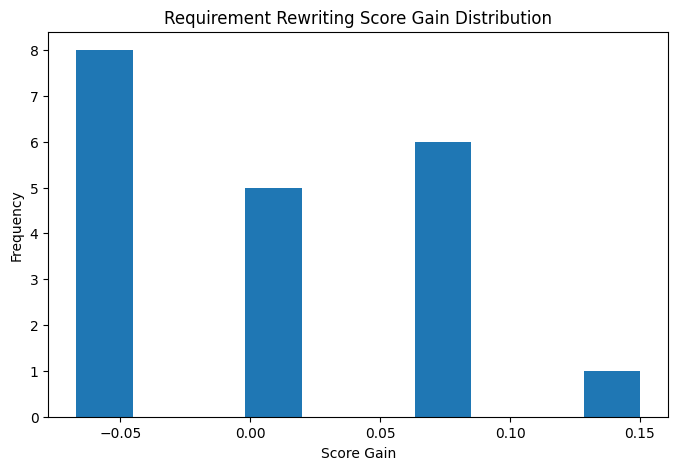

In [224]:
# =========================================
# STEP 8 - Visualize rewriting improvement
# =========================================

plt.figure(figsize=(8,5))
plt.hist(rewrite_sample_df["rewrite_gain"], bins=10)
plt.title("Requirement Rewriting Score Gain Distribution")
plt.xlabel("Score Gain")
plt.ylabel("Frequency")
plt.show()

In [225]:
# =========================================
# STEP 9 - Final reusable rewriting function
# =========================================

def analyze_and_rewrite_requirement(text):
    analysis = analyze_requirement_for_rewriting(text)
    rewrite = intelligent_rewrite_requirement(text)

    return {
        "original_text": text,
        "analysis": analysis,
        "rewritten_text": rewrite["rewritten_text"],
        "before_score": rewrite["before_score"],
        "after_score": rewrite["after_score"],
        "score_gain": rewrite["score_gain"]
    }

In [226]:
analyze_and_rewrite_requirement("The system should be fast and easy to use.")

{'original_text': 'The system should be fast and easy to use.',
 'analysis': {'text': 'The system should be fast and easy to use.',
  'overall_score': 0.5,
  'issues': ['weak_modality',
   'vague_wording',
   'not_measurable',
   'possibly_non_atomic'],
  'recommended_actions': ['strengthen_modality',
   'replace_vague_terms',
   'add_measurable_criterion',
   'split_into_atomic_requirements'],
  'dimension_scores': {'clarity': 0.4,
   'specificity': 0.5,
   'measurability': 0.5,
   'testability': 0.6,
   'atomicity': 0.6,
   'modality_strength': 0.4}},
 'rewritten_text': 'The system shall be respond within 2 seconds under normal operating conditions. The system shall allow first-time users to complete the main task in less than 3 minutes without training.',
 'before_score': 0.5,
 'after_score': 1.0,
 'score_gain': 0.5}

In [227]:
# =========================================
# FIX 1 - Protected phrase groups
# =========================================

protected_groups = [
    "email and password",
    "username and password",
    "terms and conditions",
    "security and privacy",
    "input and output",
    "search and filter",
    "save and exit",
    "hardware and software"
]

In [228]:
# =========================================
# FIX 2 - Safer atomic split
# =========================================

def split_atomic_requirements_safe(text):
    text_lower = text.lower()

    for group in protected_groups:
        if group in text_lower:
            return [text]

    # on split seulement si plusieurs verbes d'action paraissent présents
    parts = re.split(r"\band\b|\bor\b", text, flags=re.IGNORECASE)
    parts = [p.strip(" .;") for p in parts if p.strip(" .;")]

    if len(parts) <= 1:
        return [text]

    first = parts[0]

    if not re.search(r"\bshall\b|\bmust\b", first, flags=re.IGNORECASE):
        return [text]

    rebuilt = []
    rebuilt.append(first if first.endswith(".") else first + ".")

    for p in parts[1:]:
        p = p.strip()
        if not p:
            continue

        if re.search(r"\bshall\b|\bmust\b", p, flags=re.IGNORECASE):
            rebuilt.append(p if p.endswith(".") else p + ".")
        else:
            rebuilt.append("The system shall " + p + ".")

    return rebuilt

In [229]:
# =========================================
# FIX 3 - Safer measurable enhancer
# =========================================

def add_measurable_clause_safe(text):
    text_lower = text.lower().strip()

    if contains_number(text):
        return text

    # seulement si le texte se termine proprement
    base = text.rstrip(".").strip()

    if "respond" in text_lower or "response" in text_lower:
        return base + " within 2 seconds."
    elif "notify" in text_lower:
        return base + " within 1 minute after the triggering event."
    elif "upload" in text_lower:
        return base + " for files up to 10 MB in size."
    elif "search" in text_lower:
        return base + " and return results within 3 seconds."
    elif "save" in text_lower:
        return base + " within 2 seconds after user confirmation."
    elif "authenticate" in text_lower or "login" in text_lower:
        return base + " within 5 seconds after valid credential submission."
    else:
        return base

In [230]:
# =========================================
# FIX 4 - Guarded intelligent rewriting
# =========================================

def intelligent_rewrite_requirement_safe(text, min_gain=0.01, score_threshold=0.75):
    before = score_requirement_quality(text)
    analysis = analyze_requirement_for_rewriting(text)

    # si déjà bonne, on ne touche presque pas
    if before["overall_score"] >= score_threshold:
        return {
            "original_text": text,
            "rewritten_text": text,
            "split_rewrites": [text],
            "before_score": before["overall_score"],
            "after_score": before["overall_score"],
            "score_gain": 0.0,
            "before_issues": before["issues"],
            "after_issues": before["issues"],
            "rewrite_applied": False
        }

    rewritten = text

    if "strengthen_modality" in analysis["recommended_actions"]:
        rewritten = rewrite_weak_modality(rewritten)

    if "replace_vague_terms" in analysis["recommended_actions"]:
        rewritten = rewrite_vague_terms(rewritten)

    if "add_measurable_criterion" in analysis["recommended_actions"]:
        rewritten = add_measurable_clause_safe(rewritten)

    split_versions = [rewritten]
    if "split_into_atomic_requirements" in analysis["recommended_actions"]:
        split_versions = split_atomic_requirements_safe(rewritten)

    rewritten_joined = " ".join(split_versions)
    after = score_requirement_quality(rewritten_joined)

    gain = round(after["overall_score"] - before["overall_score"], 3)

    # garde-fou : si pas mieux, on garde l’original
    if gain < min_gain:
        return {
            "original_text": text,
            "rewritten_text": text,
            "split_rewrites": [text],
            "before_score": before["overall_score"],
            "after_score": before["overall_score"],
            "score_gain": 0.0,
            "before_issues": before["issues"],
            "after_issues": before["issues"],
            "rewrite_applied": False
        }

    return {
        "original_text": text,
        "rewritten_text": rewritten_joined,
        "split_rewrites": split_versions,
        "before_score": before["overall_score"],
        "after_score": after["overall_score"],
        "score_gain": gain,
        "before_issues": before["issues"],
        "after_issues": after["issues"],
        "rewrite_applied": True
    }

In [231]:
# =========================================
# FIX 5 - Re-test corrected rewriting
# =========================================

rewrite_results_safe = [intelligent_rewrite_requirement_safe(req) for req in rewrite_test_requirements]

for r in rewrite_results_safe:
    print("ORIGINAL :", r["original_text"])
    print("REWRITTEN:", r["rewritten_text"])
    print("APPLIED  :", r["rewrite_applied"])
    print("BEFORE   :", r["before_score"])
    print("AFTER    :", r["after_score"])
    print("GAIN     :", r["score_gain"])
    print("BEFORE ISSUES:", r["before_issues"])
    print("AFTER ISSUES :", r["after_issues"])
    print("-" * 100)

ORIGINAL : The system should be fast.
REWRITTEN: The system shall be respond within 2 seconds under normal operating conditions.
APPLIED  : True
BEFORE   : 0.567
AFTER    : 1.0
GAIN     : 0.433
BEFORE ISSUES: ['weak_modality', 'vague_wording', 'not_measurable']
AFTER ISSUES : []
----------------------------------------------------------------------------------------------------
ORIGINAL : The interface shall be easy to use.
REWRITTEN: The interface shall be allow first-time users to complete the main task in less than 3 minutes without training.
APPLIED  : True
BEFORE   : 0.7
AFTER    : 1.0
GAIN     : 0.3
BEFORE ISSUES: ['vague_wording', 'not_measurable']
AFTER ISSUES : []
----------------------------------------------------------------------------------------------------
ORIGINAL : The system may notify users soon.
REWRITTEN: The system shall notify users within a clearly specified deadline within 1 minute after the triggering event.
APPLIED  : True
BEFORE   : 0.567
AFTER    : 1.0
GAI

In [232]:
# =========================================
# FIX 6 - Corrected before/after table
# =========================================

rewrite_df_safe = pd.DataFrame([
    {
        "original_requirement": r["original_text"],
        "rewritten_requirement": r["rewritten_text"],
        "rewrite_applied": r["rewrite_applied"],
        "before_score": r["before_score"],
        "after_score": r["after_score"],
        "score_gain": r["score_gain"],
        "before_issues": ", ".join(r["before_issues"]),
        "after_issues": ", ".join(r["after_issues"])
    }
    for r in rewrite_results_safe
])

display(rewrite_df_safe)

,original_requirement,rewritten_requirement,rewrite_applied,before_score,after_score,score_gain,before_issues,after_issues
0,The system should be fast.,The system shall be respond within 2 seconds u...,True,0.567,1.00,0.433,"weak_modality, vague_wording, not_measurable",
1,The interface shall be easy to use.,The interface shall be allow first-time users ...,True,0.700,1.00,0.300,"vague_wording, not_measurable",
2,The system may notify users soon.,The system shall notify users within a clearly...,True,0.567,1.00,0.433,"weak_modality, vague_wording, not_measurable",
3,The system shall authenticate users using emai...,The system shall authenticate users using emai...,False,0.850,0.85,0.000,"not_measurable, possibly_non_atomic","not_measurable, possibly_non_atomic"
4,The system shall validate input and save data ...,The system shall validate input and save data ...,False,0.850,0.85,0.000,"not_measurable, possibly_non_atomic","not_measurable, possibly_non_atomic"


In [233]:
# =========================================
# FIX 7 - Apply corrected rewriting to sample
# =========================================

rewrite_sample_df_safe = sample_df.copy()

rewrite_sample_df_safe["rewrite_result"] = rewrite_sample_df_safe["text"].apply(intelligent_rewrite_requirement_safe)
rewrite_sample_df_safe["rewritten_text"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["rewritten_text"])
rewrite_sample_df_safe["rewrite_applied"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["rewrite_applied"])
rewrite_sample_df_safe["rewrite_before_score"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["before_score"])
rewrite_sample_df_safe["rewrite_after_score"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["after_score"])
rewrite_sample_df_safe["rewrite_gain"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["score_gain"])

display(
    rewrite_sample_df_safe[
        ["text", "rewritten_text", "rewrite_applied", "rewrite_before_score", "rewrite_after_score", "rewrite_gain"]
    ]
)

,text,rewritten_text,rewrite_applied,rewrite_before_score,rewrite_after_score,rewrite_gain
22482,3.2.36.4 Alternate Flows.,3.2.36.4 Alternate Flows.,False,0.950,0.950,0.0
4463,Data and event logging,Data and event logging,False,0.800,0.800,0.0
21362,A covered entity must document the following a...,A covered entity must document the following a...,False,0.933,0.933,0.0
10657,System shall ensure portability by enabling ac...,System shall ensure portability by enabling ac...,False,0.917,0.917,0.0
3880,MARC bibliographic and authority records can b...,MARC bibliographic and authority records can b...,False,0.883,0.883,0.0
23266,The system has an unmerge process.,The system has an unmerge process.,False,0.867,0.867,0.0
9795,The BE shall store input data records in a mem...,The BE shall store input data records in a mem...,False,0.850,0.850,0.0
12473,"Upon selecting Home, system shall display vide...","Upon selecting Home, system shall display vide...",False,0.850,0.850,0.0
22704,The LHCP can view of the comprehensive patient...,The LHCP can view of the comprehensive patient...,False,0.867,0.867,0.0
4383,Upload File,Upload File,False,0.867,0.867,0.0


In [234]:
# =========================================
# FIX 7 - Apply corrected rewriting to sample
# =========================================

rewrite_sample_df_safe = sample_df.copy()

rewrite_sample_df_safe["rewrite_result"] = rewrite_sample_df_safe["text"].apply(intelligent_rewrite_requirement_safe)
rewrite_sample_df_safe["rewritten_text"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["rewritten_text"])
rewrite_sample_df_safe["rewrite_applied"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["rewrite_applied"])
rewrite_sample_df_safe["rewrite_before_score"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["before_score"])
rewrite_sample_df_safe["rewrite_after_score"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["after_score"])
rewrite_sample_df_safe["rewrite_gain"] = rewrite_sample_df_safe["rewrite_result"].apply(lambda x: x["score_gain"])

display(
    rewrite_sample_df_safe[
        ["text", "rewritten_text", "rewrite_applied", "rewrite_before_score", "rewrite_after_score", "rewrite_gain"]
    ]
)

,text,rewritten_text,rewrite_applied,rewrite_before_score,rewrite_after_score,rewrite_gain
22482,3.2.36.4 Alternate Flows.,3.2.36.4 Alternate Flows.,False,0.950,0.950,0.0
4463,Data and event logging,Data and event logging,False,0.800,0.800,0.0
21362,A covered entity must document the following a...,A covered entity must document the following a...,False,0.933,0.933,0.0
10657,System shall ensure portability by enabling ac...,System shall ensure portability by enabling ac...,False,0.917,0.917,0.0
3880,MARC bibliographic and authority records can b...,MARC bibliographic and authority records can b...,False,0.883,0.883,0.0
23266,The system has an unmerge process.,The system has an unmerge process.,False,0.867,0.867,0.0
9795,The BE shall store input data records in a mem...,The BE shall store input data records in a mem...,False,0.850,0.850,0.0
12473,"Upon selecting Home, system shall display vide...","Upon selecting Home, system shall display vide...",False,0.850,0.850,0.0
22704,The LHCP can view of the comprehensive patient...,The LHCP can view of the comprehensive patient...,False,0.867,0.867,0.0
4383,Upload File,Upload File,False,0.867,0.867,0.0


## Conclusion - Safe Intelligent Requirement Rewriting

The first rewriting version showed that automatic improvement can increase requirement quality scores,
but it also revealed a key limitation: overly aggressive rewriting may damage already acceptable requirements.

To address this, a safer rewriting strategy was introduced. This version applies guarded rewriting only
when the expected score improvement is meaningful, and it avoids splitting protected phrase groups such
as "email and password" or "security and privacy".

As a result, the final rewriting module becomes more reliable and better suited for real SRS assistance.

# =========================================
# MODULE B2 — DEEP / GENERATIVE REWRITING
# =========================================

In [235]:
# =========================================
# STEP B2.1 - Install / Import generative model
# =========================================


import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

In [236]:
# =========================================
# STEP B2.2 - Load rewriting model
# =========================================

import torch
import transformers
import huggingface_hub

print("transformers:", transformers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

rewrite_checkpoint = "google/flan-t5-small"

rewrite_tokenizer = AutoTokenizer.from_pretrained(rewrite_checkpoint)
rewrite_model = AutoModelForSeq2SeqLM.from_pretrained(rewrite_checkpoint)

rewrite_device = "cuda" if torch.cuda.is_available() else "cpu"
rewrite_model = rewrite_model.to(rewrite_device)

print("Rewrite model loaded on:", rewrite_device)

transformers: 5.0.0
huggingface_hub: 1.4.1


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Rewrite model loaded on: cuda


In [237]:
# =========================================
# STEP B2.3 - Build rewriting prompt (fixed)
# =========================================

def build_rewrite_prompt(requirement_text, quality_analysis):
    issues = quality_analysis["issues"]
    issues_text = ", ".join(issues) if len(issues) > 0 else "none"

    prompt = f"""
Rewrite the following software requirement into a better requirement.

Rules:
- Output only the improved requirement.
- Do not explain.
- Do not list issues.
- Do not repeat the prompt.
- Keep the original meaning.
- Make it clearer, more measurable, and more testable.
- Use strong requirement wording such as "shall" if appropriate.
- If the requirement contains multiple actions, split it into short requirement sentences.

Requirement:
{requirement_text}

Quality issues:
{issues_text}

Improved requirement:
""".strip()

    return prompt

In [238]:
# =========================================
# STEP B2.4 - Generate rewritten requirement (fixed)
# =========================================

def clean_generated_requirement(text):
    cleaned = str(text).strip()

    bad_prefixes = [
        "improved requirement:",
        "detected issues:",
        "recommended actions:",
        "quality issues:",
        "requirement:"
    ]

    cleaned_lower = cleaned.lower()
    for prefix in bad_prefixes:
        if cleaned_lower.startswith(prefix):
            cleaned = cleaned[len(prefix):].strip()
            cleaned_lower = cleaned.lower()

    # remove prompt-like fragments if they appear inside
    for noise in ["Detected issues:", "Recommended actions:", "Quality issues:"]:
        cleaned = cleaned.replace(noise, "")

    cleaned = " ".join(cleaned.split())
    return cleaned

def generate_requirement_rewrite(text, max_new_tokens=80):
    quality_analysis = analyze_requirement_quality(text)
    prompt = build_rewrite_prompt(text, quality_analysis)

    inputs = rewrite_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(rewrite_device)

    rewrite_model.eval()
    with torch.no_grad():
        outputs = rewrite_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5,
            do_sample=False,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    generated_text = rewrite_tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    rewritten_text = clean_generated_requirement(generated_text)

    return {
        "original_text": text,
        "prompt": prompt,
        "generated_text": rewritten_text,
        "quality_analysis": quality_analysis
    }

In [239]:
# =========================================
# STEP B2.5 - Validate generated rewrite
# =========================================

def validate_generated_rewrite(text):
    generation_result = generate_requirement_rewrite(text)

    original_text = generation_result["original_text"]
    generated_text = generation_result["generated_text"]

    before_quality = analyze_requirement_quality(original_text)
    after_quality = analyze_requirement_quality(generated_text)

    score_gain = round(after_quality["overall_score"] - before_quality["overall_score"], 3)

    return {
        "original_text": original_text,
        "generated_text": generated_text,
        "before_score": before_quality["overall_score"],
        "after_score": after_quality["overall_score"],
        "score_gain": score_gain,
        "before_issues": before_quality["issues"],
        "after_issues": after_quality["issues"],
        "before_actions": before_quality["recommended_actions"],
        "after_actions": after_quality["recommended_actions"]
    }

validate_generated_rewrite("The system should be fast and easy to use.")

{'original_text': 'The system should be fast and easy to use.',
 'generated_text': 'The system should be fast and easy to use.',
 'before_score': 0.45,
 'after_score': 0.45,
 'score_gain': 0.0,
 'before_issues': ['vague_wording',
  'not_measurable',
  'weak_testability',
  'possibly_non_atomic',
  'weak_modality'],
 'after_issues': ['vague_wording',
  'not_measurable',
  'weak_testability',
  'possibly_non_atomic',
  'weak_modality'],
 'before_actions': ['replace_vague_terms',
  'add_measurable_criteria',
  'add_test_conditions',
  'split_into_atomic_requirements',
  'strengthen_modality'],
 'after_actions': ['replace_vague_terms',
  'add_measurable_criteria',
  'add_test_conditions',
  'split_into_atomic_requirements',
  'strengthen_modality']}

In [240]:
# =========================================
# STEP B2.6 - Safe acceptance of generated rewrite (fixed)
# =========================================

def rewrite_requirement_deep_safe(text, min_gain=0.05):
    result = validate_generated_rewrite(text)

    original_text = result["original_text"].strip()
    generated_text = result["generated_text"].strip()

    noisy_patterns = [
        "detected issues",
        "recommended actions",
        "quality issues",
        "improved requirement"
    ]

    has_noise = any(p in generated_text.lower() for p in noisy_patterns)

    if generated_text == "":
        final_text = original_text
        rewrite_applied = False
        decision_reason = "Generated rewrite was empty."

    elif generated_text.lower() == original_text.lower():
        final_text = original_text
        rewrite_applied = False
        decision_reason = "Generated rewrite was identical to the original."

    elif has_noise:
        final_text = original_text
        rewrite_applied = False
        decision_reason = "Generated rewrite contained prompt noise."

    elif result["score_gain"] >= min_gain:
        final_text = generated_text
        rewrite_applied = True
        decision_reason = "Generated rewrite improved the quality score sufficiently."

    else:
        final_text = original_text
        rewrite_applied = False
        decision_reason = "Generated rewrite did not improve the quality score enough."

    return {
        **result,
        "final_text": final_text,
        "rewrite_applied": rewrite_applied,
        "decision_reason": decision_reason
    }

In [241]:
# =========================================
# STEP B2.7 - Manual deep rewriting examples
# =========================================

deep_rewrite_examples = [
    "The system should be fast.",
    "The interface shall be easy to use.",
    "The application may process some requests later.",
    "The system shall validate input and save data and notify administrators.",
    "The software should respond quickly and efficiently.",
    "The system shall encrypt all passwords using AES-256 before storage."
]

deep_rewrite_results = [rewrite_requirement_deep_safe(req) for req in deep_rewrite_examples]

for r in deep_rewrite_results:
    print("=" * 100)
    print("ORIGINAL :", r["original_text"])
    print("GENERATED:", r["generated_text"])
    print("FINAL    :", r["final_text"])
    print("APPLIED  :", r["rewrite_applied"])
    print("BEFORE   :", r["before_score"])
    print("AFTER    :", r["after_score"])
    print("GAIN     :", r["score_gain"])
    print("REASON   :", r["decision_reason"])
    print("BEFORE ISSUES:", r["before_issues"])
    print("AFTER ISSUES :", r["after_issues"])

ORIGINAL : The system should be fast.
GENERATED: Use strong requirement wording such as "shall" if appropriate.
FINAL    : Use strong requirement wording such as "shall" if appropriate.
APPLIED  : True
BEFORE   : 0.567
AFTER    : 0.717
GAIN     : 0.15
REASON   : Generated rewrite improved the quality score sufficiently.
BEFORE ISSUES: ['vague_wording', 'not_measurable', 'weak_testability', 'weak_modality']
AFTER ISSUES : ['vague_wording', 'not_measurable', 'weak_testability']
ORIGINAL : The interface shall be easy to use.
GENERATED: Make it clearer, more measurable, and more testable. Use strong requirement wording such as "shall" if appropriate.
FINAL    : The interface shall be easy to use.
APPLIED  : False
BEFORE   : 0.633
AFTER    : 0.65
GAIN     : 0.017
REASON   : Generated rewrite did not improve the quality score enough.
BEFORE ISSUES: ['vague_wording', 'not_measurable', 'weak_testability']
AFTER ISSUES : ['vague_wording', 'not_measurable', 'weak_testability', 'possibly_non_atom

In [242]:
# =========================================
# STEP B2.8 - Build deep rewriting table
# =========================================

deep_rewrite_df = pd.DataFrame([
    {
        "original_requirement": r["original_text"],
        "generated_requirement": r["generated_text"],
        "final_requirement": r["final_text"],
        "rewrite_applied": r["rewrite_applied"],
        "before_score": r["before_score"],
        "after_score": r["after_score"],
        "score_gain": r["score_gain"],
        "decision_reason": r["decision_reason"],
        "before_issues": ", ".join(r["before_issues"]),
        "after_issues": ", ".join(r["after_issues"])
    }
    for r in deep_rewrite_results
])

display(deep_rewrite_df)

,original_requirement,generated_requirement,final_requirement,rewrite_applied,before_score,after_score,score_gain,decision_reason,before_issues,after_issues
0,The system should be fast.,"Use strong requirement wording such as ""shall""...","Use strong requirement wording such as ""shall""...",True,0.567,0.717,0.150,Generated rewrite improved the quality score s...,"vague_wording, not_measurable, weak_testabilit...","vague_wording, not_measurable, weak_testability"
1,The interface shall be easy to use.,"Make it clearer, more measurable, and more tes...",The interface shall be easy to use.,False,0.633,0.650,0.017,Generated rewrite did not improve the quality ...,"vague_wording, not_measurable, weak_testability","vague_wording, not_measurable, weak_testabilit..."
2,The application may process some requests later.,"Make it clearer, more measurable, and more tes...",The application may process some requests later.,False,0.617,0.617,0.000,Generated rewrite did not improve the quality ...,"vague_wording, not_measurable, weak_testabilit...","not_measurable, weak_testability, possibly_non..."
3,The system shall validate input and save data ...,"Not_measurable, weak_testability, possibly_non...",The system shall validate input and save data ...,False,0.750,0.667,-0.083,Generated rewrite did not improve the quality ...,"not_measurable, weak_testability, possibly_non...","not_measurable, weak_testability, weak_modality"
4,The software should respond quickly and effici...,The software should respond quickly and effici...,The software should respond quickly and effici...,False,0.433,0.433,0.000,Generated rewrite was identical to the original.,"vague_wording, not_measurable, weak_testabilit...","vague_wording, not_measurable, weak_testabilit..."
5,The system shall encrypt all passwords using A...,"Make it clearer, more measurable, and more tes...",The system shall encrypt all passwords using A...,False,0.883,0.650,-0.233,Generated rewrite did not improve the quality ...,weak_testability,"vague_wording, not_measurable, weak_testabilit..."


In [243]:
# =========================================
# STEP B2.9 - Apply deep rewriting to notebook sample
# =========================================

deep_rewrite_sample_df = df_requirements[["text", "label", "sub_label"]].sample(15, random_state=42).copy()
deep_rewrite_sample_df["deep_rewrite_result"] = deep_rewrite_sample_df["text"].apply(rewrite_requirement_deep_safe)

deep_rewrite_sample_df["generated_text"] = deep_rewrite_sample_df["deep_rewrite_result"].apply(lambda x: x["generated_text"])
deep_rewrite_sample_df["final_text"] = deep_rewrite_sample_df["deep_rewrite_result"].apply(lambda x: x["final_text"])
deep_rewrite_sample_df["rewrite_applied"] = deep_rewrite_sample_df["deep_rewrite_result"].apply(lambda x: x["rewrite_applied"])
deep_rewrite_sample_df["before_score"] = deep_rewrite_sample_df["deep_rewrite_result"].apply(lambda x: x["before_score"])
deep_rewrite_sample_df["after_score"] = deep_rewrite_sample_df["deep_rewrite_result"].apply(lambda x: x["after_score"])
deep_rewrite_sample_df["score_gain"] = deep_rewrite_sample_df["deep_rewrite_result"].apply(lambda x: x["score_gain"])

display(
    deep_rewrite_sample_df[
        ["text", "generated_text", "final_text", "rewrite_applied", "before_score", "after_score", "score_gain"]
    ]
)

,text,generated_text,final_text,rewrite_applied,before_score,after_score,score_gain
22482,3.2.36.4 Alternate Flows.,3.2.36.4 Alternate Flows.,3.2.36.4 Alternate Flows.,False,0.767,0.767,0.000
4463,Data and event logging,"Not_measurable, weak_testability, possibly_non...","Not_measurable, weak_testability, possibly_non...",True,0.600,0.667,0.067
21362,A covered entity must document the following a...,"Make it clearer, more measurable, and more tes...",A covered entity must document the following a...,False,0.767,0.650,-0.117
10657,System shall ensure portability by enabling ac...,"Make it clearer, more measurable, and more tes...",System shall ensure portability by enabling ac...,False,0.733,0.617,-0.116
3880,MARC bibliographic and authority records can b...,"Make it clearer, more measurable, and more tes...",MARC bibliographic and authority records can b...,False,0.617,0.650,0.033
23266,The system has an unmerge process.,The system has an unmerge process.,The system has an unmerge process.,False,0.717,0.717,0.000
9795,The BE shall store input data records in a mem...,"Not_measurable, weak_testability, possibly_non...",The BE shall store input data records in a mem...,False,0.717,0.667,-0.050
12473,"Upon selecting Home, system shall display vide...","Make it clearer, more measurable, and more tes...","Upon selecting Home, system shall display vide...",False,0.717,0.650,-0.067
22704,The LHCP can view of the comprehensive patient...,"Make it clearer, more measurable, and more tes...",The LHCP can view of the comprehensive patient...,False,0.667,0.650,-0.017
4383,Upload File,"Make it clearer, more measurable, and more tes...",Upload File,False,0.717,0.617,-0.100


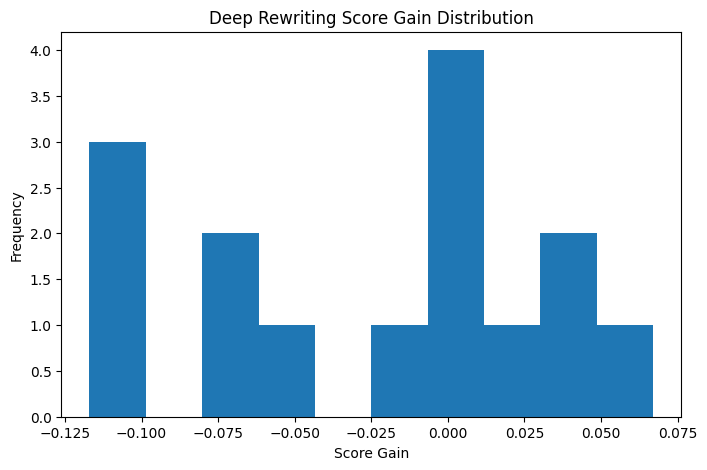

In [244]:
# =========================================
# STEP B2.10 - Visualize deep rewriting gains
# =========================================

plt.figure(figsize=(8,5))
plt.hist(deep_rewrite_sample_df["score_gain"], bins=10)
plt.title("Deep Rewriting Score Gain Distribution")
plt.xlabel("Score Gain")
plt.ylabel("Frequency")
plt.show()

In [245]:
# =========================================
# STEP B2.11 - Reusable deep rewriting function
# =========================================

def analyze_and_rewrite_requirement_deep(text):
    result = rewrite_requirement_deep_safe(text)
    return {
        "original_text": result["original_text"],
        "generated_text": result["generated_text"],
        "final_text": result["final_text"],
        "rewrite_applied": result["rewrite_applied"],
        "before_score": result["before_score"],
        "after_score": result["after_score"],
        "score_gain": result["score_gain"],
        "decision_reason": result["decision_reason"]
    }

analyze_and_rewrite_requirement_deep("The system should be fast and easy to use.")

{'original_text': 'The system should be fast and easy to use.',
 'generated_text': 'The system should be fast and easy to use.',
 'final_text': 'The system should be fast and easy to use.',
 'rewrite_applied': False,
 'before_score': 0.45,
 'after_score': 0.45,
 'score_gain': 0.0,
 'decision_reason': 'Generated rewrite was identical to the original.'}

## Conclusion - Deep / Generative Rewriting

A first deep generative rewriting prototype was integrated using FLAN-T5 and connected to the hybrid quality validation module.

The generation pipeline is technically functional:
- it produces candidate rewrites,
- re-evaluates them with the quality scoring module,
- and accepts only rewrites that improve the quality score.

However, the observed results show that the current generative model often stays too close to the original requirement or introduces low-value textual artifacts.
Therefore, this module is retained as a promising prototype rather than a fully mature rewriting engine.

Future work may include:
- stronger instruction-tuned models,
- domain-specific fine-tuning,
- ambiguity-aware prompting,
- and stricter semantic preservation checks.

# =========================================
# MODULE B3 — STRUCTURED REQUIREMENT GENERATION
# =========================================

In [246]:
# =========================================
# STEP B3.1 - Load structured generation model
# =========================================

gen_checkpoint = "google/flan-t5-base"

gen_tokenizer = AutoTokenizer.from_pretrained(gen_checkpoint)
gen_model = AutoModelForSeq2SeqLM.from_pretrained(gen_checkpoint)

gen_device = "cuda" if torch.cuda.is_available() else "cpu"
gen_model = gen_model.to(gen_device)

print("Structured generation model loaded on:", gen_device)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Structured generation model loaded on: cuda


In [247]:
# =========================================
# STEP B3.2 - Define target sections
# =========================================

target_sections = [
    "functional_requirements",
    "non_functional_requirements",
    "constraints",
    "risks",
    "acceptance_criteria"
]

print(target_sections)

['functional_requirements', 'non_functional_requirements', 'constraints', 'risks', 'acceptance_criteria']


In [248]:
# =========================================
# STEP B3.3 - Build structured generation prompt (fixed)
# =========================================

def build_generation_prompt(product_context, section_name, n_items=5):
    section_labels = {
        "functional_requirements": "functional requirements",
        "non_functional_requirements": "non-functional requirements",
        "constraints": "constraints",
        "risks": "risks",
        "acceptance_criteria": "acceptance criteria"
    }

    section_examples = {
        "functional_requirements": "The system shall allow users to upload PDF requirements documents.",
        "non_functional_requirements": "The system shall respond within 2 seconds under normal operating conditions.",
        "constraints": "The solution must comply with GDPR regulations.",
        "risks": "Poor OCR quality may reduce extraction accuracy.",
        "acceptance_criteria": "The upload feature is accepted if users can upload a PDF without validation errors."
    }

    prompt = f"""
You are a software requirements engineer.

Task:
Generate exactly {n_items} {section_labels[section_name]} for the product context below.

Instructions:
- Return only the generated items
- One item per line
- Do not repeat the product context
- Do not explain
- Do not write titles
- Do not write 'Output'
- Do not write numbering
- Keep each line concise and realistic

Example format:
{section_examples[section_name]}

Product context:
{product_context}

Generate {n_items} {section_labels[section_name]}:
""".strip()

    return prompt

In [249]:
# =========================================
# STEP B3.4 - Generate one section (fixed)
# =========================================

def clean_generated_lines(text):
    lines = [line.strip() for line in str(text).split("\n")]
    cleaned = []

    banned_fragments = [
        "product context",
        "generate",
        "output",
        "functional requirements",
        "non-functional requirements",
        "constraints",
        "acceptance criteria",
        "risks:",
        "section:",
        "one item per line"
    ]

    for line in lines:
        line = line.strip(" -•1234567890.\t")
        if len(line) < 8:
            continue

        low = line.lower()

        if any(fragment in low for fragment in banned_fragments):
            continue

        cleaned.append(" ".join(line.split()))

    # remove duplicates while preserving order
    unique_lines = []
    seen = set()
    for line in cleaned:
        if line.lower() not in seen:
            unique_lines.append(line)
            seen.add(line.lower())

    return unique_lines

def generate_section_requirements(product_context, section_name, n_items=5, max_new_tokens=160):
    prompt = build_generation_prompt(product_context, section_name, n_items=n_items)

    inputs = gen_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(gen_device)

    gen_model.eval()
    with torch.no_grad():
        outputs = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5,
            do_sample=False,
            early_stopping=True,
            no_repeat_ngram_size=3
        )

    raw_text = gen_tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    items = clean_generated_lines(raw_text)

    # fallback if model returns only one long line
    if len(items) == 1 and ";" in items[0]:
        items = [x.strip() for x in items[0].split(";") if len(x.strip()) > 0]

    return {
        "section": section_name,
        "prompt": prompt,
        "raw_output": raw_text,
        "items": items[:n_items]
    }

In [250]:
# =========================================
# STEP B3.5 - Generate full structured specification (fixed)
# =========================================

def generate_structured_specification(product_context, n_items_per_section=3):
    results = {}

    for section in target_sections:
        section_result = generate_section_requirements(
            product_context,
            section,
            n_items=n_items_per_section
        )

        items = section_result["items"]

        # fallback if nothing useful was generated
        if len(items) == 0:
            fallback_defaults = {
                "functional_requirements": [
                    "The system shall provide the main functional capabilities described in the product context."
                ],
                "non_functional_requirements": [
                    "The system shall satisfy the expected performance, security, and usability requirements."
                ],
                "constraints": [
                    "The solution must comply with the applicable technical and regulatory constraints."
                ],
                "risks": [
                    "Incomplete requirements may reduce the quality of the generated specification."
                ],
                "acceptance_criteria": [
                    "The feature is accepted if it works correctly and meets the specified validation conditions."
                ]
            }
            items = fallback_defaults[section]

        results[section] = items

    return results

sample_product_context = """
An AI assistant for startups that can read software requirement documents,
classify FR and NFR requirements, detect ambiguity, evaluate requirement quality,
suggest rewrites, and generate missing SRS sections.
"""

generated_spec = generate_structured_specification(sample_product_context, n_items_per_section=3)
generated_spec

{'functional_requirements': ['I need an AI assistant to read software requirement documents'],
 'non_functional_requirements': ['I need to be able to read software requirement documents, classify FR and NFR, detect ambiguity'],
 'constraints': ['The solution must comply with the applicable technical and regulatory constraints.'],
 'risks': ['AI assistant for startups that can read software requirement documents, classify FR and NFR requirements, detect ambiguity'],
 'acceptance_criteria': ['None of the above choices']}

In [251]:
# =========================================
# STEP B3.6 - Convert generated specification to dataframe
# =========================================

generated_rows = []

for section, items in generated_spec.items():
    for item in items:
        generated_rows.append({
            "section": section,
            "generated_requirement": item
        })

generated_spec_df = pd.DataFrame(generated_rows)
display(generated_spec_df)

,section,generated_requirement
0,functional_requirements,I need an AI assistant to read software requir...
1,non_functional_requirements,I need to be able to read software requirement...
2,constraints,The solution must comply with the applicable t...
3,risks,AI assistant for startups that can read softwa...
4,acceptance_criteria,None of the above choices


In [252]:
# =========================================
# STEP B3.7 - Analyze generated requirements with FR/NFR predictor
# =========================================

def analyze_generated_requirement_row(text, section):
    frnfr_result = predict_fr_nfr_distilbert(text)
    ambiguity_result = analyze_requirement_hybrid(text)
    quality_result = analyze_requirement_quality(text)

    return {
        "text": text,
        "section": section,
        "predicted_type": frnfr_result["predicted_label"],
        "fr_probability": frnfr_result["probabilities"]["FR"],
        "nfr_probability": frnfr_result["probabilities"]["NFR"],
        "final_ambiguity": ambiguity_result["final_ambiguity"],
        "quality_score": quality_result["overall_score"],
        "quality_issues": ", ".join(quality_result["issues"]),
        "recommended_actions": ", ".join(quality_result["recommended_actions"])
    }

generated_analysis = [
    analyze_generated_requirement_row(row["generated_requirement"], row["section"])
    for _, row in generated_spec_df.iterrows()
]

generated_analysis_df = pd.DataFrame(generated_analysis)
display(generated_analysis_df)

,text,section,predicted_type,fr_probability,nfr_probability,final_ambiguity,quality_score,quality_issues,recommended_actions
0,I need an AI assistant to read software requir...,functional_requirements,NFR,0.373971,0.626029,clear,0.683,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."
1,I need to be able to read software requirement...,non_functional_requirements,FR,0.504036,0.495964,clear,0.650,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
2,The solution must comply with the applicable t...,constraints,NFR,0.310711,0.689289,clear,0.667,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
3,AI assistant for startups that can read softwa...,risks,NFR,0.289699,0.710301,ambiguous,0.600,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
4,None of the above choices,acceptance_criteria,FR,0.811242,0.188758,ambiguous,0.667,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."


In [253]:
# =========================================
# STEP B3.8 - Build section-level summary
# =========================================

section_summary_df = generated_analysis_df.groupby("section").agg(
    count=("text", "count"),
    avg_quality_score=("quality_score", "mean")
).reset_index()

display(section_summary_df)

,section,count,avg_quality_score
0,acceptance_criteria,1,0.667
1,constraints,1,0.667
2,functional_requirements,1,0.683
3,non_functional_requirements,1,0.650
4,risks,1,0.600


In [254]:
# =========================================
# STEP B3.9 - Manual generation test
# =========================================

context_2 = """
A healthcare web platform where doctors can manage patient records,
schedule appointments, receive alerts, and ensure secure access to medical data.
"""

generated_spec_2 = generate_structured_specification(context_2, n_items_per_section=3)

rows_2 = []
for section, items in generated_spec_2.items():
    for item in items:
        rows_2.append({
            "section": section,
            "generated_requirement": item
        })

generated_spec_2_df = pd.DataFrame(rows_2)
display(generated_spec_2_df)

,section,generated_requirement
0,functional_requirements,A healthcare web platform where doctors can ma...
1,non_functional_requirements,"I need to be able to manage patient records, s..."
2,constraints,This is a healthcare web platform where doctor...
3,risks,A healthcare web platform where doctors can ma...
4,acceptance_criteria,None of the above choices


In [255]:
# =========================================
# STEP B3.10 - Reusable structured generation function
# =========================================

def generate_and_analyze_specification(product_context, n_items_per_section=4):
    spec = generate_structured_specification(product_context, n_items_per_section=n_items_per_section)

    rows = []
    for section, items in spec.items():
        for item in items:
            analysis = analyze_generated_requirement_row(item, section)
            rows.append(analysis)

    return pd.DataFrame(rows)

generate_and_analyze_specification(
    "A platform for online learning where students watch courses, submit assignments, and receive personalized recommendations.",
    n_items_per_section=3
)

,text,section,predicted_type,fr_probability,nfr_probability,final_ambiguity,quality_score,quality_issues,recommended_actions
0,I need a platform for online learning where st...,functional_requirements,NFR,0.468737,0.531263,clear,0.667,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
1,I need a platform for online learning where st...,non_functional_requirements,NFR,0.468737,0.531263,clear,0.667,"not_measurable, weak_testability, possibly_non...","add_measurable_criteria, add_test_conditions, ..."
2,There must be at least 1 item per line,constraints,FR,0.703135,0.296865,clear,0.950,,
3,This product does not meet the quality standar...,risks,NFR,0.441129,0.558871,ambiguous,0.683,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."
4,None of the above choices,acceptance_criteria,FR,0.811242,0.188758,ambiguous,0.667,"not_measurable, weak_testability, weak_modality","add_measurable_criteria, add_test_conditions, ..."


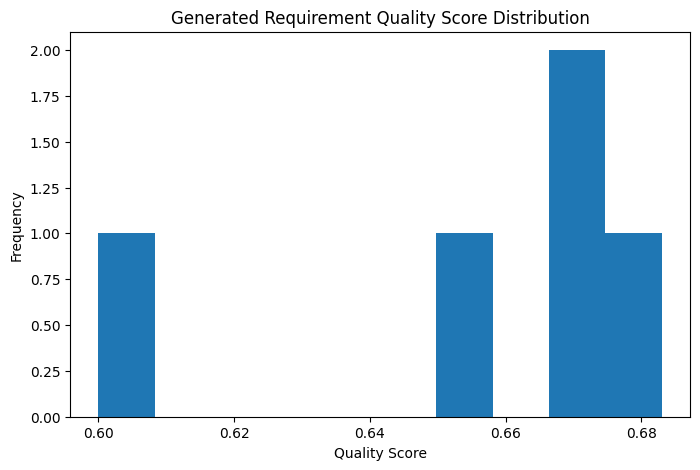

In [256]:
# =========================================
# STEP B3.11 - Visualize generated requirement quality
# =========================================

plt.figure(figsize=(8,5))
plt.hist(generated_analysis_df["quality_score"], bins=10)
plt.title("Generated Requirement Quality Score Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Frequency")
plt.show()

# =========================================
# MODULE C1 — DATASET-BASED SRS TEMPLATE COMPLIANCE
# =========================================

In [257]:
# =========================================
# STEP C1.1 - Build canonical SRS template dataset
# =========================================

canonical_srs_rows = [
    {"order_id": 1, "section": "introduction"},
    {"order_id": 2, "section": "general_description"},
    {"order_id": 3, "section": "functional_requirements"},
    {"order_id": 4, "section": "interface_requirements"},
    {"order_id": 5, "section": "performance_requirements"},
    {"order_id": 6, "section": "design_constraints"},
    {"order_id": 7, "section": "non_functional_requirements"},
    {"order_id": 8, "section": "risks"},
    {"order_id": 9, "section": "acceptance_criteria"},
    {"order_id": 10, "section": "appendices"}
]

df_canonical_srs = pd.DataFrame(canonical_srs_rows)

print("Canonical SRS dataset shape:", df_canonical_srs.shape)
display(df_canonical_srs)

Canonical SRS dataset shape: (10, 2)


,order_id,section
0,1,introduction
1,2,general_description
2,3,functional_requirements
3,4,interface_requirements
4,5,performance_requirements
5,6,design_constraints
6,7,non_functional_requirements
7,8,risks
8,9,acceptance_criteria
9,10,appendices


In [258]:
# =========================================
# STEP C1.2 - Build section pattern dataset
# =========================================

section_pattern_rows = [
    {"section": "introduction", "pattern": "introduction", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "introduction", "pattern": "purpose", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "introduction", "pattern": "scope", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "introduction", "pattern": "overview", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "general_description", "pattern": "general description", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "general_description", "pattern": "product perspective", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "product functions", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "user classes", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "general_description", "pattern": "operating environment", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "functional_requirements", "pattern": "functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "system features", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "functional_requirements", "pattern": "functionalities", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "interface_requirements", "pattern": "interface requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "external interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "user interface", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "software interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "interface_requirements", "pattern": "hardware interfaces", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "performance_requirements", "pattern": "performance requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "response time", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "latency", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "performance_requirements", "pattern": "throughput", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "design_constraints", "pattern": "design constraints", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "constraints", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "technical limitations", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "design_constraints", "pattern": "standards compliance", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "non_functional_requirements", "pattern": "non-functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "non functional requirements", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "quality attributes", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "security", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "usability", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},
    {"section": "non_functional_requirements", "pattern": "reliability", "pattern_type": "heading_keyword", "weight": 1, "source": "manual_template"},

    {"section": "risks", "pattern": "risks", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "risks", "pattern": "risk analysis", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "risks", "pattern": "project risks", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "risks", "pattern": "assumptions and dependencies", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "acceptance_criteria", "pattern": "acceptance criteria", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "validation criteria", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "success criteria", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "acceptance_criteria", "pattern": "definition of done", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},

    {"section": "appendices", "pattern": "appendix", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "appendices", "pattern": "appendices", "pattern_type": "heading", "weight": 3, "source": "manual_template"},
    {"section": "appendices", "pattern": "glossary", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"},
    {"section": "appendices", "pattern": "references", "pattern_type": "heading_keyword", "weight": 2, "source": "manual_template"}
]

df_section_patterns = pd.DataFrame(section_pattern_rows)

print("Section pattern dataset shape:", df_section_patterns.shape)
display(df_section_patterns.head(20))

Section pattern dataset shape: (43, 5)


,section,pattern,pattern_type,weight,source
0,introduction,introduction,heading,3,manual_template
1,introduction,purpose,heading_keyword,2,manual_template
2,introduction,scope,heading_keyword,2,manual_template
3,introduction,overview,heading_keyword,2,manual_template
4,general_description,general description,heading,3,manual_template
5,general_description,product perspective,heading_keyword,2,manual_template
6,general_description,product functions,heading_keyword,2,manual_template
7,general_description,user classes,heading_keyword,2,manual_template
8,general_description,operating environment,heading_keyword,2,manual_template
9,functional_requirements,functional requirements,heading,3,manual_template


In [259]:
# =========================================
# STEP C1.3 - Normalize heading text
# =========================================

import re

def normalize_heading_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"^\d+(\.\d+)*\s*", "", text)
    text = re.sub(r"[^a-z0-9\s\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print(normalize_heading_text("3.2 Functional Requirements"))
print(normalize_heading_text("1. Introduction and Scope"))

functional requirements
introduction and scope


In [260]:
# =========================================
# STEP C1.4 - Section detection from heading using dataset
# =========================================

def detect_section_from_heading_dataset(heading, pattern_df):
    heading_norm = normalize_heading_text(heading)

    matched = pattern_df[
        pattern_df["pattern"].apply(lambda p: normalize_heading_text(p) in heading_norm)
    ].copy()

    if matched.empty:
        return {
            "raw_heading": heading,
            "normalized_heading": heading_norm,
            "predicted_section": "unknown",
            "matched_patterns": [],
            "total_weight": 0
        }

    section_scores = matched.groupby("section")["weight"].sum().sort_values(ascending=False)
    best_section = section_scores.index[0]

    return {
        "raw_heading": heading,
        "normalized_heading": heading_norm,
        "predicted_section": best_section,
        "matched_patterns": matched["pattern"].tolist(),
        "total_weight": int(section_scores.iloc[0])
    }

print(detect_section_from_heading_dataset("3. Functional Requirements", df_section_patterns))
print(detect_section_from_heading_dataset("1. Introduction and Scope", df_section_patterns))
print(detect_section_from_heading_dataset("External Interfaces", df_section_patterns))

{'raw_heading': '3. Functional Requirements', 'normalized_heading': 'functional requirements', 'predicted_section': 'functional_requirements', 'matched_patterns': ['functional requirements'], 'total_weight': 3}
{'raw_heading': '1. Introduction and Scope', 'normalized_heading': 'introduction and scope', 'predicted_section': 'introduction', 'matched_patterns': ['introduction', 'scope'], 'total_weight': 5}
{'raw_heading': 'External Interfaces', 'normalized_heading': 'external interfaces', 'predicted_section': 'interface_requirements', 'matched_patterns': ['external interfaces'], 'total_weight': 2}


In [261]:
# =========================================
# STEP C1.5 - Build sample heading dataframe
# =========================================

sample_detected_headings = [
    "1. Introduction",
    "2. General Description",
    "3. Functional Requirements",
    "4. Interface Requirements",
    "5. Non-Functional Requirements",
    "6. Risks",
    "7. Acceptance Criteria"
]

heading_results = [
    detect_section_from_heading_dataset(h, df_section_patterns)
    for h in sample_detected_headings
]

sample_heading_df = pd.DataFrame(heading_results)
display(sample_heading_df)

,raw_heading,normalized_heading,predicted_section,matched_patterns,total_weight
0,1. Introduction,introduction,introduction,[introduction],3
1,2. General Description,general description,general_description,[general description],3
2,3. Functional Requirements,functional requirements,functional_requirements,[functional requirements],3
3,4. Interface Requirements,interface requirements,interface_requirements,[interface requirements],3
4,5. Non-Functional Requirements,non-functional requirements,functional_requirements,"[functional requirements, non-functional requi...",3
5,6. Risks,risks,risks,[risks],3
6,7. Acceptance Criteria,acceptance criteria,acceptance_criteria,[acceptance criteria],3


In [262]:
# =========================================
# STEP C1.6 - Compare headings to canonical SRS dataset
# =========================================

def compare_detected_sections_to_template(detected_sections, canonical_df):
    canonical_sections = canonical_df["section"].tolist()
    detected_clean = [s for s in detected_sections if s != "unknown"]

    present_sections = [s for s in canonical_sections if s in detected_clean]
    missing_sections = [s for s in canonical_sections if s not in detected_clean]
    unexpected_sections = [s for s in detected_clean if s not in canonical_sections]

    return {
        "present_sections": present_sections,
        "missing_sections": missing_sections,
        "unexpected_sections": unexpected_sections
    }

template_compare_result = compare_detected_sections_to_template(
    sample_heading_df["predicted_section"].tolist(),
    df_canonical_srs
)

template_compare_result

{'present_sections': ['introduction',
  'general_description',
  'functional_requirements',
  'interface_requirements',
  'risks',
  'acceptance_criteria'],
 'missing_sections': ['performance_requirements',
  'design_constraints',
  'non_functional_requirements',
  'appendices'],
 'unexpected_sections': []}

In [263]:
# =========================================
# STEP C1.7 - Compute order score
# =========================================

def compute_dataset_order_score(detected_sections, canonical_df):
    canonical_order = {
        row["section"]: row["order_id"]
        for _, row in canonical_df.iterrows()
    }

    detected_clean = [s for s in detected_sections if s in canonical_order]

    if len(detected_clean) <= 1:
        return 1.0

    correct_pairs = 0
    total_pairs = 0

    for i in range(len(detected_clean)):
        for j in range(i + 1, len(detected_clean)):
            total_pairs += 1
            if canonical_order[detected_clean[i]] <= canonical_order[detected_clean[j]]:
                correct_pairs += 1

    if total_pairs == 0:
        return 1.0

    return round(correct_pairs / total_pairs, 3)

order_score = compute_dataset_order_score(
    sample_heading_df["predicted_section"].tolist(),
    df_canonical_srs
)

print("Order score:", order_score)

Order score: 0.952


In [264]:
# =========================================
# STEP C1.8 - Compute template compliance score
# =========================================

def compute_dataset_template_compliance(detected_sections, canonical_df):
    compare_result = compare_detected_sections_to_template(detected_sections, canonical_df)

    present_ratio = len(compare_result["present_sections"]) / len(canonical_df)
    order_score = compute_dataset_order_score(detected_sections, canonical_df)

    template_compliance_score = round((0.7 * present_ratio) + (0.3 * order_score), 3)

    recommendations = []
    if len(compare_result["missing_sections"]) > 0:
        recommendations.append("add_missing_sections")
    if order_score < 1.0:
        recommendations.append("reorganize_sections")
    if len(compare_result["unexpected_sections"]) > 0:
        recommendations.append("review_unexpected_sections")

    return {
        "present_sections": compare_result["present_sections"],
        "missing_sections": compare_result["missing_sections"],
        "unexpected_sections": compare_result["unexpected_sections"],
        "order_score": order_score,
        "template_compliance_score": template_compliance_score,
        "recommendations": recommendations
    }

compliance_result = compute_dataset_template_compliance(
    sample_heading_df["predicted_section"].tolist(),
    df_canonical_srs
)

compliance_result

{'present_sections': ['introduction',
  'general_description',
  'functional_requirements',
  'interface_requirements',
  'risks',
  'acceptance_criteria'],
 'missing_sections': ['performance_requirements',
  'design_constraints',
  'non_functional_requirements',
  'appendices'],
 'unexpected_sections': [],
 'order_score': 0.952,
 'template_compliance_score': 0.706,
 'recommendations': ['add_missing_sections', 'reorganize_sections']}

In [265]:
# =========================================
# STEP C1.9 - Build compliance dataframe
# =========================================

compliance_df = pd.DataFrame([
    {
        "present_sections": ", ".join(compliance_result["present_sections"]),
        "missing_sections": ", ".join(compliance_result["missing_sections"]),
        "unexpected_sections": ", ".join(compliance_result["unexpected_sections"]),
        "order_score": compliance_result["order_score"],
        "template_compliance_score": compliance_result["template_compliance_score"],
        "recommendations": ", ".join(compliance_result["recommendations"])
    }
])

display(compliance_df)

,present_sections,missing_sections,unexpected_sections,order_score,template_compliance_score,recommendations
0,"introduction, general_description, functional_...","performance_requirements, design_constraints, ...",,0.952,0.706,"add_missing_sections, reorganize_sections"


In [266]:
# =========================================
# STEP C1.10 - Reusable compliance function
# =========================================

def analyze_document_template_compliance_dataset(headings_list):
    heading_results = [
        detect_section_from_heading_dataset(h, df_section_patterns)
        for h in headings_list
    ]

    heading_df = pd.DataFrame(heading_results)

    compliance = compute_dataset_template_compliance(
        heading_df["predicted_section"].tolist(),
        df_canonical_srs
    )

    return {
        "heading_table": heading_df,
        "compliance_result": compliance
    }

doc_result = analyze_document_template_compliance_dataset([
    "1. Introduction",
    "2. General Description",
    "3. Functional Requirements",
    "4. Risks",
    "5. Acceptance Criteria"
])

display(doc_result["heading_table"])
doc_result["compliance_result"]

,raw_heading,normalized_heading,predicted_section,matched_patterns,total_weight
0,1. Introduction,introduction,introduction,[introduction],3
1,2. General Description,general description,general_description,[general description],3
2,3. Functional Requirements,functional requirements,functional_requirements,[functional requirements],3
3,4. Risks,risks,risks,[risks],3
4,5. Acceptance Criteria,acceptance criteria,acceptance_criteria,[acceptance criteria],3


{'present_sections': ['introduction',
  'general_description',
  'functional_requirements',
  'risks',
  'acceptance_criteria'],
 'missing_sections': ['interface_requirements',
  'performance_requirements',
  'design_constraints',
  'non_functional_requirements',
  'appendices'],
 'unexpected_sections': [],
 'order_score': 1.0,
 'template_compliance_score': 0.65,
 'recommendations': ['add_missing_sections']}